# NSE Next-Day Price Predictor

## 1. Business Understanding
### 1.1 Problem Statement
Retail investors on the NSE often face information asymmetry, high volatility, and liquidity challenges when deciding at what price to place buy (bid) or sell (offer) orders. Many rely on gut feel, broker advice, or simple charts, leading to suboptimal entries/exits, slippage, missed opportunities, or unnecessary losses.
The system aims to reduce this gap by using historical daily data (2022–2025) to forecast near-term price behavior (e.g., next-day close, Day Low, or Day High). This helps investors set smarter limit orders, for example, bidding near a predicted Day Low or offering near a predicted Day High, while incorporating volume and market context.

### 1.2 Stakeholders and Use Case

**Primary stakeholder:** Retail investors using NSE trading platforms (e.g. Safaricom's Ziidi Trader, CBA Loop).  
**Secondary stakeholders:** Licensed NSE stockbrokers who advise clients on daily entry and exit prices.

A retail investor holding EQTY can open this system before market hours, see a predicted next-day closing price, and confidently place a limit buy order near that level without guessing.

### 1.3 Project Objective
Develop a transparent, backtestable short-horizon price prediction system that forecasts next-day Day Low, Day High, and Day Price using 2022–2025 daily data. The system will help investors set smarter limit orders for example, Bid near predicted Day Low or Offer near predicted Day High while factoring in liquidity and market context.

**Business Questions:**
1. What are the key drivers of daily price movements for high-liquidity NSE stocks?
2. How accurately can we forecast the next-day Day Low, Day High, and Day Price to support better bid/offer decisions?
3. Which stocks or segments offer the best trade-off between predictability and liquidity for retail investors?

## 2. Data Understanding

### 2.1 Data Source

Daily OHLCV (Open, High, Low, Close, Volume) data sourced from NSE official daily market reports, covering January 2022 to October 2025. Raw dataset: 67,313 rows across 79 stocks.

### 2.2 Why This Data Is Suitable

Each row represents one stock's full trading activity for one day(price, volume, and range). This mirrors exactly what a retail investor sees when making a limit order decision. The 4-year window covers two full market cycles (2022 downturn, 2024 recovery), giving the model diverse market conditions to learn from.

### 2.3 Feature Descriptions

| Column | Description |
|--------|-------------|
| day_price | Closing price for the day (KES) |
| day_low / day_high | Intraday price range |
| previous | Previous day's closing price |
| volume | Shares traded |
| 12m_low / 12m_high | 52-week price range |
| changepct | Daily percentage change |

### 2.4 Data Limitations

- **29.9% zero-volume days** across all stocks - many NSE stocks trade infrequently. We address this by restricting to 10 blue-chip stocks.
- **Structural price breaks in 2025** -KPLC rose from KES 2.36 to KES 9.31 due to regulatory changes. No price-history model can predict these events.
- **No alternative data** - earnings announcements, dividends, and macroeconomic indicators are not included, which limits predictability of unusual market moves.
### 2.5 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import lightgbm as lgb


### 2.6 Loading All Files
We load all four yearly CSV files from the data folder and combine them into a single dataframe.

In [2]:
folder_path = "nse-2022-2025-data"

all_files = sorted([p.name for p in Path(folder_path).glob("*.csv")])

dfs = []

for file in all_files:
    file_path = str(Path(folder_path) / file)
    df = pd.read_csv(file_path)
    
    df['source_file'] = file  
    dfs.append(df)

# Combine all into one dataset
nse_data = pd.concat(dfs, ignore_index=True)

print("Total rows:", nse_data.shape[0])
print("Total columns:", nse_data.shape[1])

Total rows: 67313
Total columns: 14


In [3]:
print("\nFirst 5 rows of combined data:")
print(df.head())


First 5 rows of combined data:
       Date  Code                     Name  12m Low  12m High  Day Low  \
0  2-Jan-25  EGAD              Eaagads Ltd     10.8     24.10     12.0   
1  2-Jan-25  KUKZ               Kakuzi Plc    365.0    440.00    385.0   
2  2-Jan-25  KAPC  Kapchorua Tea Kenya Plc    198.0    424.25    236.0   
3  2-Jan-25  LIMT           Limuru Tea Plc    295.0    423.50    350.0   
4  2-Jan-25  SASN               Sasini Plc     13.3     20.40     14.8   

   Day High  Day Price Previous Change Change% Volume Adjusted Price  \
0      12.0      12.00       12      -       -      -              -   
1     400.0     392.50      385    7.5   1.95%    200              -   
2     240.0     239.25      235   4.25   1.81%   1000              -   
3     350.0     350.00      350      -       -      -              -   
4      15.0      15.00       15      -       -  38700              -   

                    source_file  
0  NSE_data_all_stocks_2025.csv  
1  NSE_data_all_stocks

In [4]:
nse_data.info()
nse_data.describe()
nse_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67313 entries, 0 to 67312
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            67313 non-null  object
 1   Code            67313 non-null  object
 2   Name            67313 non-null  object
 3   12m Low         67313 non-null  object
 4   12m High        67313 non-null  object
 5   Day Low         67313 non-null  object
 6   Day High        67313 non-null  object
 7   Day Price       67313 non-null  object
 8   Previous        67313 non-null  object
 9   Change          67313 non-null  object
 10  Change%         67313 non-null  object
 11  Volume          67313 non-null  object
 12  Adjusted Price  67313 non-null  object
 13  source_file     67313 non-null  object
dtypes: object(14)
memory usage: 7.2+ MB


Index(['Date', 'Code', 'Name', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume',
       'Adjusted Price', 'source_file'],
      dtype='object')

## 3. Data Preparation

### 3.1 Standardise Column Names

Column names come in inconsistent formats across the four yearly files; mixed case, spaces, special characters. We standardise to snake_case so all downstream code references columns consistently.

In [5]:
def standardize_columns(df):
    """
    Rename columns to clean snake_case:
      - Strip leading/trailing whitespace
      - Lowercase everything
      - Replace spaces with underscores
      - Replace '%' with 'pct'
      - Replace special chars like '/' with '_'
    """
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(' ', '_', regex=False)
          .str.replace('%', 'pct', regex=False)
          .str.replace('/', '_', regex=False)
    )
    return df

nse_data = standardize_columns(nse_data)

print("Standardised column names:")
print(nse_data.columns.tolist())

Standardised column names:
['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume', 'adjusted_price', 'source_file']


### 3.2 Convert Data Types and Clean Values

Raw CSVs store prices as text with dashes, commas, and percentage symbols. We convert all price and volume columns to numeric. Dashes represent missing values and are treated as NaN.

In [6]:
# Columns that must be numeric 
numeric_cols = ['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous']

for col in numeric_cols:
    nse_data[col] = pd.to_numeric(nse_data[col], errors='coerce')

# Clean Volume: remove commas, replace '-' with NaN
nse_data['volume'] = (
    nse_data['volume']
    .astype(str)
    .str.replace(',', '', regex=False)
    .replace('-', np.nan)
)
nse_data['volume'] = pd.to_numeric(nse_data['volume'], errors='coerce')

# Clean Change: '-' means no change to 0
nse_data['change'] = pd.to_numeric(
    nse_data['change'].astype(str).replace('-', '0'), errors='coerce'
).fillna(0)

# Clean Change%: strip '%', '-' to 0
nse_data['changepct'] = pd.to_numeric(
    nse_data['changepct'].astype(str)
                         .str.replace('%', '', regex=False)
                         .replace('-', '0'),
    errors='coerce'
).fillna(0)

# Parse dates
nse_data['date'] = pd.to_datetime(nse_data['date'], dayfirst=True, errors='coerce')

# Sort by stock then date
nse_data = nse_data.sort_values(['code', 'date']).reset_index(drop=True)

print("Dtypes after cleaning:")
print(nse_data.dtypes)
print(f"\nDate range: {nse_data['date'].min().date()} → {nse_data['date'].max().date()}")
print(f"Null counts:\n{nse_data.isnull().sum()}")

Dtypes after cleaning:
date              datetime64[ns]
code                      object
name                      object
12m_low                  float64
12m_high                 float64
day_low                  float64
day_high                 float64
day_price                float64
previous                 float64
change                   float64
changepct                float64
volume                   float64
adjusted_price            object
source_file               object
dtype: object

Date range: 2022-01-03 → 2025-10-31
Null counts:
date                  0
code                  0
name                  0
12m_low            3185
12m_high           4517
day_low            4235
day_high           4235
day_price          4203
previous           4203
change                0
changepct             0
volume            23043
adjusted_price        0
source_file           0
dtype: int64


### 3.3 Drop Irrelevant Column

`adjusted_price` is almost entirely dashes (missing) and has no modelling value. We remove it.

In [7]:
# Drop adjusted_price column — mostly '-', not useful for modelling
nse_data = nse_data.drop(columns=['adjusted_price'])

print("adjusted_price removed.")
print("Remaining columns:", nse_data.columns.tolist())
print("Shape:", nse_data.shape)

adjusted_price removed.
Remaining columns: ['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume', 'source_file']
Shape: (67313, 13)


### 3.4 Drop Rows with Missing Core Prices

Rows where day_low, day_high, day_price, or previous are missing cannot be used for modelling or as targets. We drop them entirely

In [8]:
# Drop rows where core price columns are missing
before = len(nse_data)
nse_data = nse_data.dropna(subset=['day_low', 'day_high', 'day_price', 'previous'])
after = len(nse_data)

print(f"Rows dropped: {before - after:,}")
print(f"Rows remaining: {after:,}")

Rows dropped: 4,244
Rows remaining: 63,069


### 3.5 Fill 52-Week High/Low

The 52-week high and low are updated periodically, not daily. Forward-fill carries the last known value forward; backward-fill handles missing values at the start of a stock's history.

In [9]:
# Forward-fill first (carry last known value forward) 
nse_data['12m_low']  = nse_data.groupby('code')['12m_low'].ffill()
nse_data['12m_high'] = nse_data.groupby('code')['12m_high'].ffill()

# Backward-fill to catch nulls at the very start of a stock's history 
nse_data['12m_low']  = nse_data.groupby('code')['12m_low'].bfill()
nse_data['12m_high'] = nse_data.groupby('code')['12m_high'].bfill()

print("Nulls after forward + backward fill:")
print(nse_data[['12m_low', '12m_high']].isnull().sum())

Nulls after forward + backward fill:
12m_low     0
12m_high    0
dtype: int64


### 3.6 Fill Missing Volume with Zero

No volume recorded means no trades occurred that day (this is a valid market state, not missing data). We fill with zero rather than dropping these rows.

In [10]:
nse_data['volume'] = nse_data['volume'].fillna(0)

print("Volume nulls remaining:", nse_data['volume'].isnull().sum())

Volume nulls remaining: 0


### 3.7 Remove Source File Column

The `source_file` column was used to track which yearly CSV each row came from during loading. It has no analytical value and is removed.

In [11]:
nse_data = nse_data.drop(columns=['source_file'])

print("Remaining columns:", nse_data.columns.tolist())

Remaining columns: ['date', 'code', 'name', '12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous', 'change', 'changepct', 'volume']


### 3.8 Remove Duplicate Rows

Each stock should have exactly one row per trading day. Duplicate (code, date) pairs would inflate training data and bias the model.

In [12]:
dupes = nse_data.duplicated(subset=['code', 'date']).sum()
print(f"Duplicate (code + date) rows: {dupes}")

if dupes > 0:
    nse_data = nse_data.drop_duplicates(subset=['code', 'date'])
    print(f" Duplicates removed. Rows remaining: {len(nse_data):,}")
else:
    print(" No duplicates found.")

Duplicate (code + date) rows: 0
 No duplicates found.


### 3.9 Validate Price Logic

A stock's closing price must fall between its daily low and high. Rows where this is violated are data errors in the source, therefore keeping them would teach the model incorrect price relationships.

In [13]:
invalid = nse_data[
    (nse_data['day_low'] > nse_data['day_high']) |
    (nse_data['day_price'] < nse_data['day_low']) |
    (nse_data['day_price'] > nse_data['day_high'])
]

print(f"Invalid price rows: {len(invalid)}")
if len(invalid) > 0:
    print(invalid[['code','date','day_low','day_high','day_price']].head(10))
    nse_data = nse_data.drop(index=invalid.index)
    print(f" Invalid rows removed. Rows remaining: {len(nse_data):,}")

Invalid price rows: 10
       code       date  day_low  day_high  day_price
2239   BAMB 2022-07-26    33.00     33.00      33.80
2334   BAMB 2022-12-13    31.50     31.50      31.40
6118   BRIT 2022-12-13     5.10      5.10       5.14
9902    CIC 2022-12-13     1.88      1.88       1.92
10848  COOP 2022-12-13    12.20     12.50      12.10
24209   IMH 2022-12-13    16.95     16.95      16.90
26952   KCB 2022-07-26    40.00     40.00      39.65
41674  NCBA 2022-12-13    31.60     31.60      34.45
43566   NSE 2022-12-13     6.84      6.86       6.82
49980  SCBK 2022-12-13   135.00    135.00     142.25
 Invalid rows removed. Rows remaining: 63,059


### 3.10 Cleaned Dataset Summary

After all preparation steps, the dataset is clean and ready for analysis.

In [14]:

print(f"Shape          : {nse_data.shape}")
print(f"Stocks         : {nse_data['code'].nunique()}")
print(f"Date range     : {nse_data['date'].min().date()} → {nse_data['date'].max().date()}")
print(f"Null values    :\n{nse_data.isnull().sum()}")
print(f"\nDtypes         :\n{nse_data.dtypes}")

Shape          : (63059, 12)
Stocks         : 79
Date range     : 2022-01-03 → 2025-10-31
Null values    :
date         0
code         0
name         0
12m_low      0
12m_high     0
day_low      0
day_high     0
day_price    0
previous     0
change       0
changepct    0
volume       0
dtype: int64

Dtypes         :
date         datetime64[ns]
code                 object
name                 object
12m_low             float64
12m_high            float64
day_low             float64
day_high            float64
day_price           float64
previous            float64
change              float64
changepct           float64
volume              float64
dtype: object


## 4. Exploratory Data Analysis (EDA)

We explore the data to understand its properties before building features or models. Key questions: how are prices distributed, which stocks are most liquid, how volatile are returns, and what correlates with next-day price?

### 4.1 Import Visualisation Libraries

In [15]:

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


nse_data['year']       = nse_data['date'].dt.year
nse_data['month']      = nse_data['date'].dt.month
nse_data['dow']        = nse_data['date'].dt.day_name()
nse_data['day_range']  = nse_data['day_high'] - nse_data['day_low']
nse_data['log_return'] = nse_data.groupby('code')['day_price'] \
                                  .transform(lambda x: np.log(x / x.shift(1)))

blue_chips = ['EQTY', 'KCB', 'SCOM', 'COOP', 'SCBK', 'ABSA',
              'KNRE', 'KEGN', 'KPLC', 'BRIT']

core_cols = ['date','code','name','12m_low','12m_high','day_low',
             'day_high','day_price','previous','change','changepct','volume']
eda_cols  = ['year','month','dow','day_range','log_return']

print(f'Core columns (cleaned dataset) : {len(core_cols)}')
print(f'EDA helper columns (derived)   : {len(eda_cols)}')
print(f'Dataset shape: {nse_data.shape}')
print(f'Blue chips ({len(blue_chips)})              : {blue_chips}')


Core columns (cleaned dataset) : 12
EDA helper columns (derived)   : 5
Dataset shape: (63059, 17)
Blue chips (10)              : ['EQTY', 'KCB', 'SCOM', 'COOP', 'SCBK', 'ABSA', 'KNRE', 'KEGN', 'KPLC', 'BRIT']


### 4.2 Records per Year and Price Distribution

We check data coverage across years and the overall distribution of closing prices. The large gap between median and mean price signals a right-skewed distribution i.e a small number of expensive stocks (e.g. SCBK at ~KES 294) pull the mean up significantly.

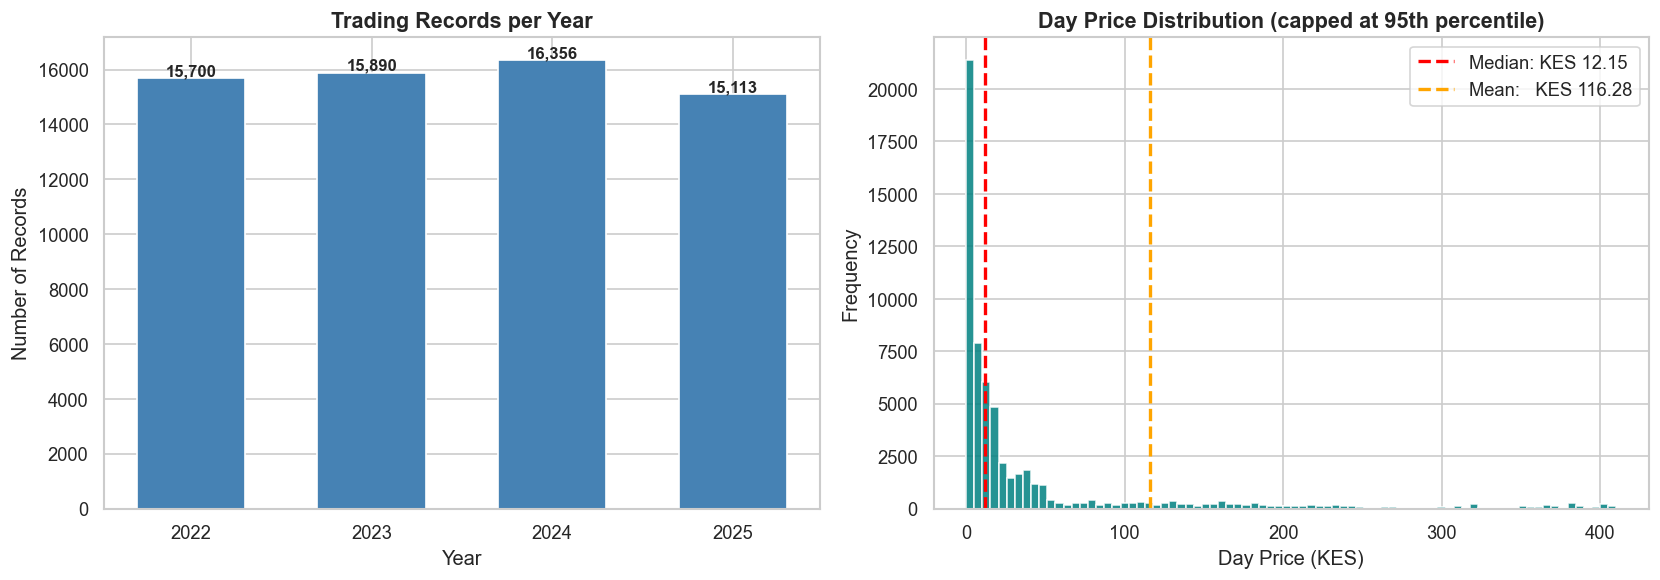

Summary Statistics
       day_price   day_low  day_high        volume  changepct
count   63059.00  63059.00  63059.00  6.305900e+04   63059.00
mean      116.28    115.91    117.00  2.621158e+05       0.44
std       431.47    430.70    436.39  2.110072e+06       4.67
min         0.01      0.01      0.02  0.000000e+00     -96.47
25%         3.70      3.65      3.80  0.000000e+00       0.00
50%        12.15     12.00     12.40  2.300000e+03       0.00
75%        41.65     41.00     42.30  3.300000e+04       0.90
max      5335.00   5100.00   9800.00  2.084859e+08     910.43


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records per year 
yr_counts = nse_data.groupby('year').size()
axes[0].bar(yr_counts.index.astype(str), yr_counts.values,
            color='steelblue', edgecolor='white', width=0.6)
axes[0].set_title('Trading Records per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(yr_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Price distribution (capped at 95th percentile to handle outliers) 
prices = nse_data['day_price']
cap    = prices.quantile(0.95)
axes[1].hist(prices[prices <= cap], bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(prices.median(), color='red',    lw=2, linestyle='--',
                label=f'Median: KES {prices.median():.2f}')
axes[1].axvline(prices.mean(),   color='orange', lw=2, linestyle='--',
                label=f'Mean:   KES {prices.mean():.2f}')
axes[1].set_title('Day Price Distribution (capped at 95th percentile)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day Price (KES)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Summary Statistics')
print(nse_data[['day_price','day_low','day_high','volume','changepct']].describe().round(2))

#### Interpretation
day_price mean: KES 116.28 vs median KES 12.15. This enormous gap between mean and median is the single most important statistical finding in your dataset. It tells you the price distribution is extremely right-skewed. The majority of NSE stocks trade below KES 12, but a small number of expensive stocks like GLD (KES 5,335) and SCBK (KES 294+) pull the average way up. This means you should never compare stocks by raw price.

### 4.3 Top 15 Stocks by Average Daily Volume

Liquidity determines which stocks are reliable for retail investors. SCOM (Safaricom) dominates with 7.4M average daily shares, which is more than 3x the next stock. We focus on blue chips since they are consistent and have a high-volume trading.

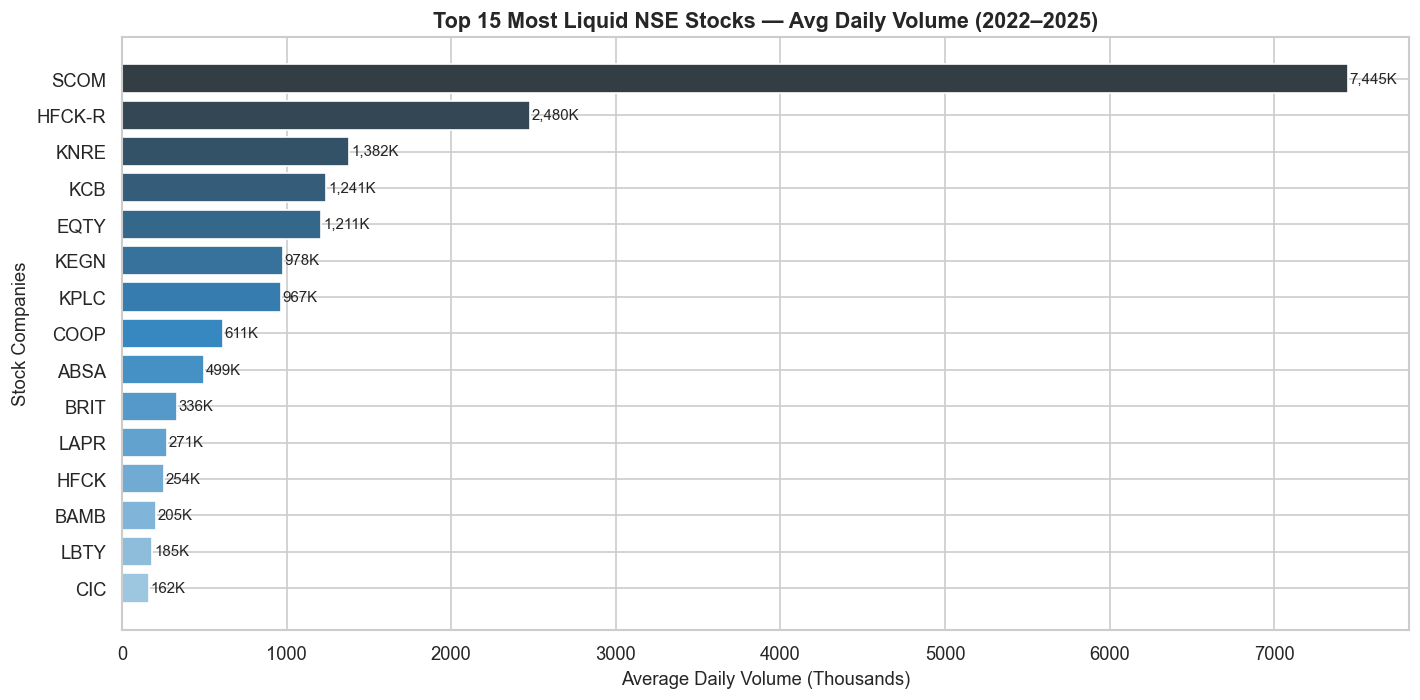


Top 15 Stocks by Avg Daily Volume:
       Avg Daily Volume
code                   
SCOM          7,445,002
HFCK-R        2,479,807
KNRE          1,381,571
KCB           1,241,449
EQTY          1,211,458
KEGN            978,047
KPLC            966,687
COOP            611,365
ABSA            499,242
BRIT            335,582
LAPR            271,351
HFCK            253,649
BAMB            204,653
LBTY            184,833
CIC             161,821


In [17]:
top15_vol = (nse_data.groupby('code')['volume']
             .mean()
             .sort_values(ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
colors  = sns.color_palette('Blues_d', 15)
bars    = ax.barh(top15_vol.index[::-1], top15_vol.values[::-1] / 1e3,
                  color=colors, edgecolor='white')
ax.set_xlabel('Average Daily Volume (Thousands)', fontsize=11)
ax.set_ylabel('Stock Companies', fontsize=11)
ax.set_title('Top 15 Most Liquid NSE Stocks — Avg Daily Volume (2022–2025)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15_vol.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{val/1e3:,.0f}K', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 15 Stocks by Avg Daily Volume:')
print(top15_vol.rename('Avg Daily Volume').apply(lambda x: f'{x:,.0f}').to_frame())

#### Interpretation

SCOM (Safaricom) dominates entirely at 7,445,002 shares per day, more than 3 times the volume of the second-placed stock HFCK-R. Safaricom is Kenya's most traded stock by far, which aligns with its position as the NSE's largest company by market cap.

KCB (1,241,449) and EQTY (1,211,458) are tied as the two most liquid banks, both ideal for modelling because they have consistent, high-volume trading every day.

KEGN (978,047) and KPLC (966,687) representing KenGen and Kenya Power are surprisingly liquid, reflecting retail investor interest in utility stocks.

### 4.4 Price Trends for Blue Chip Stocks

We visualise the full price history for each blue chip. The shaded band shows the day price.

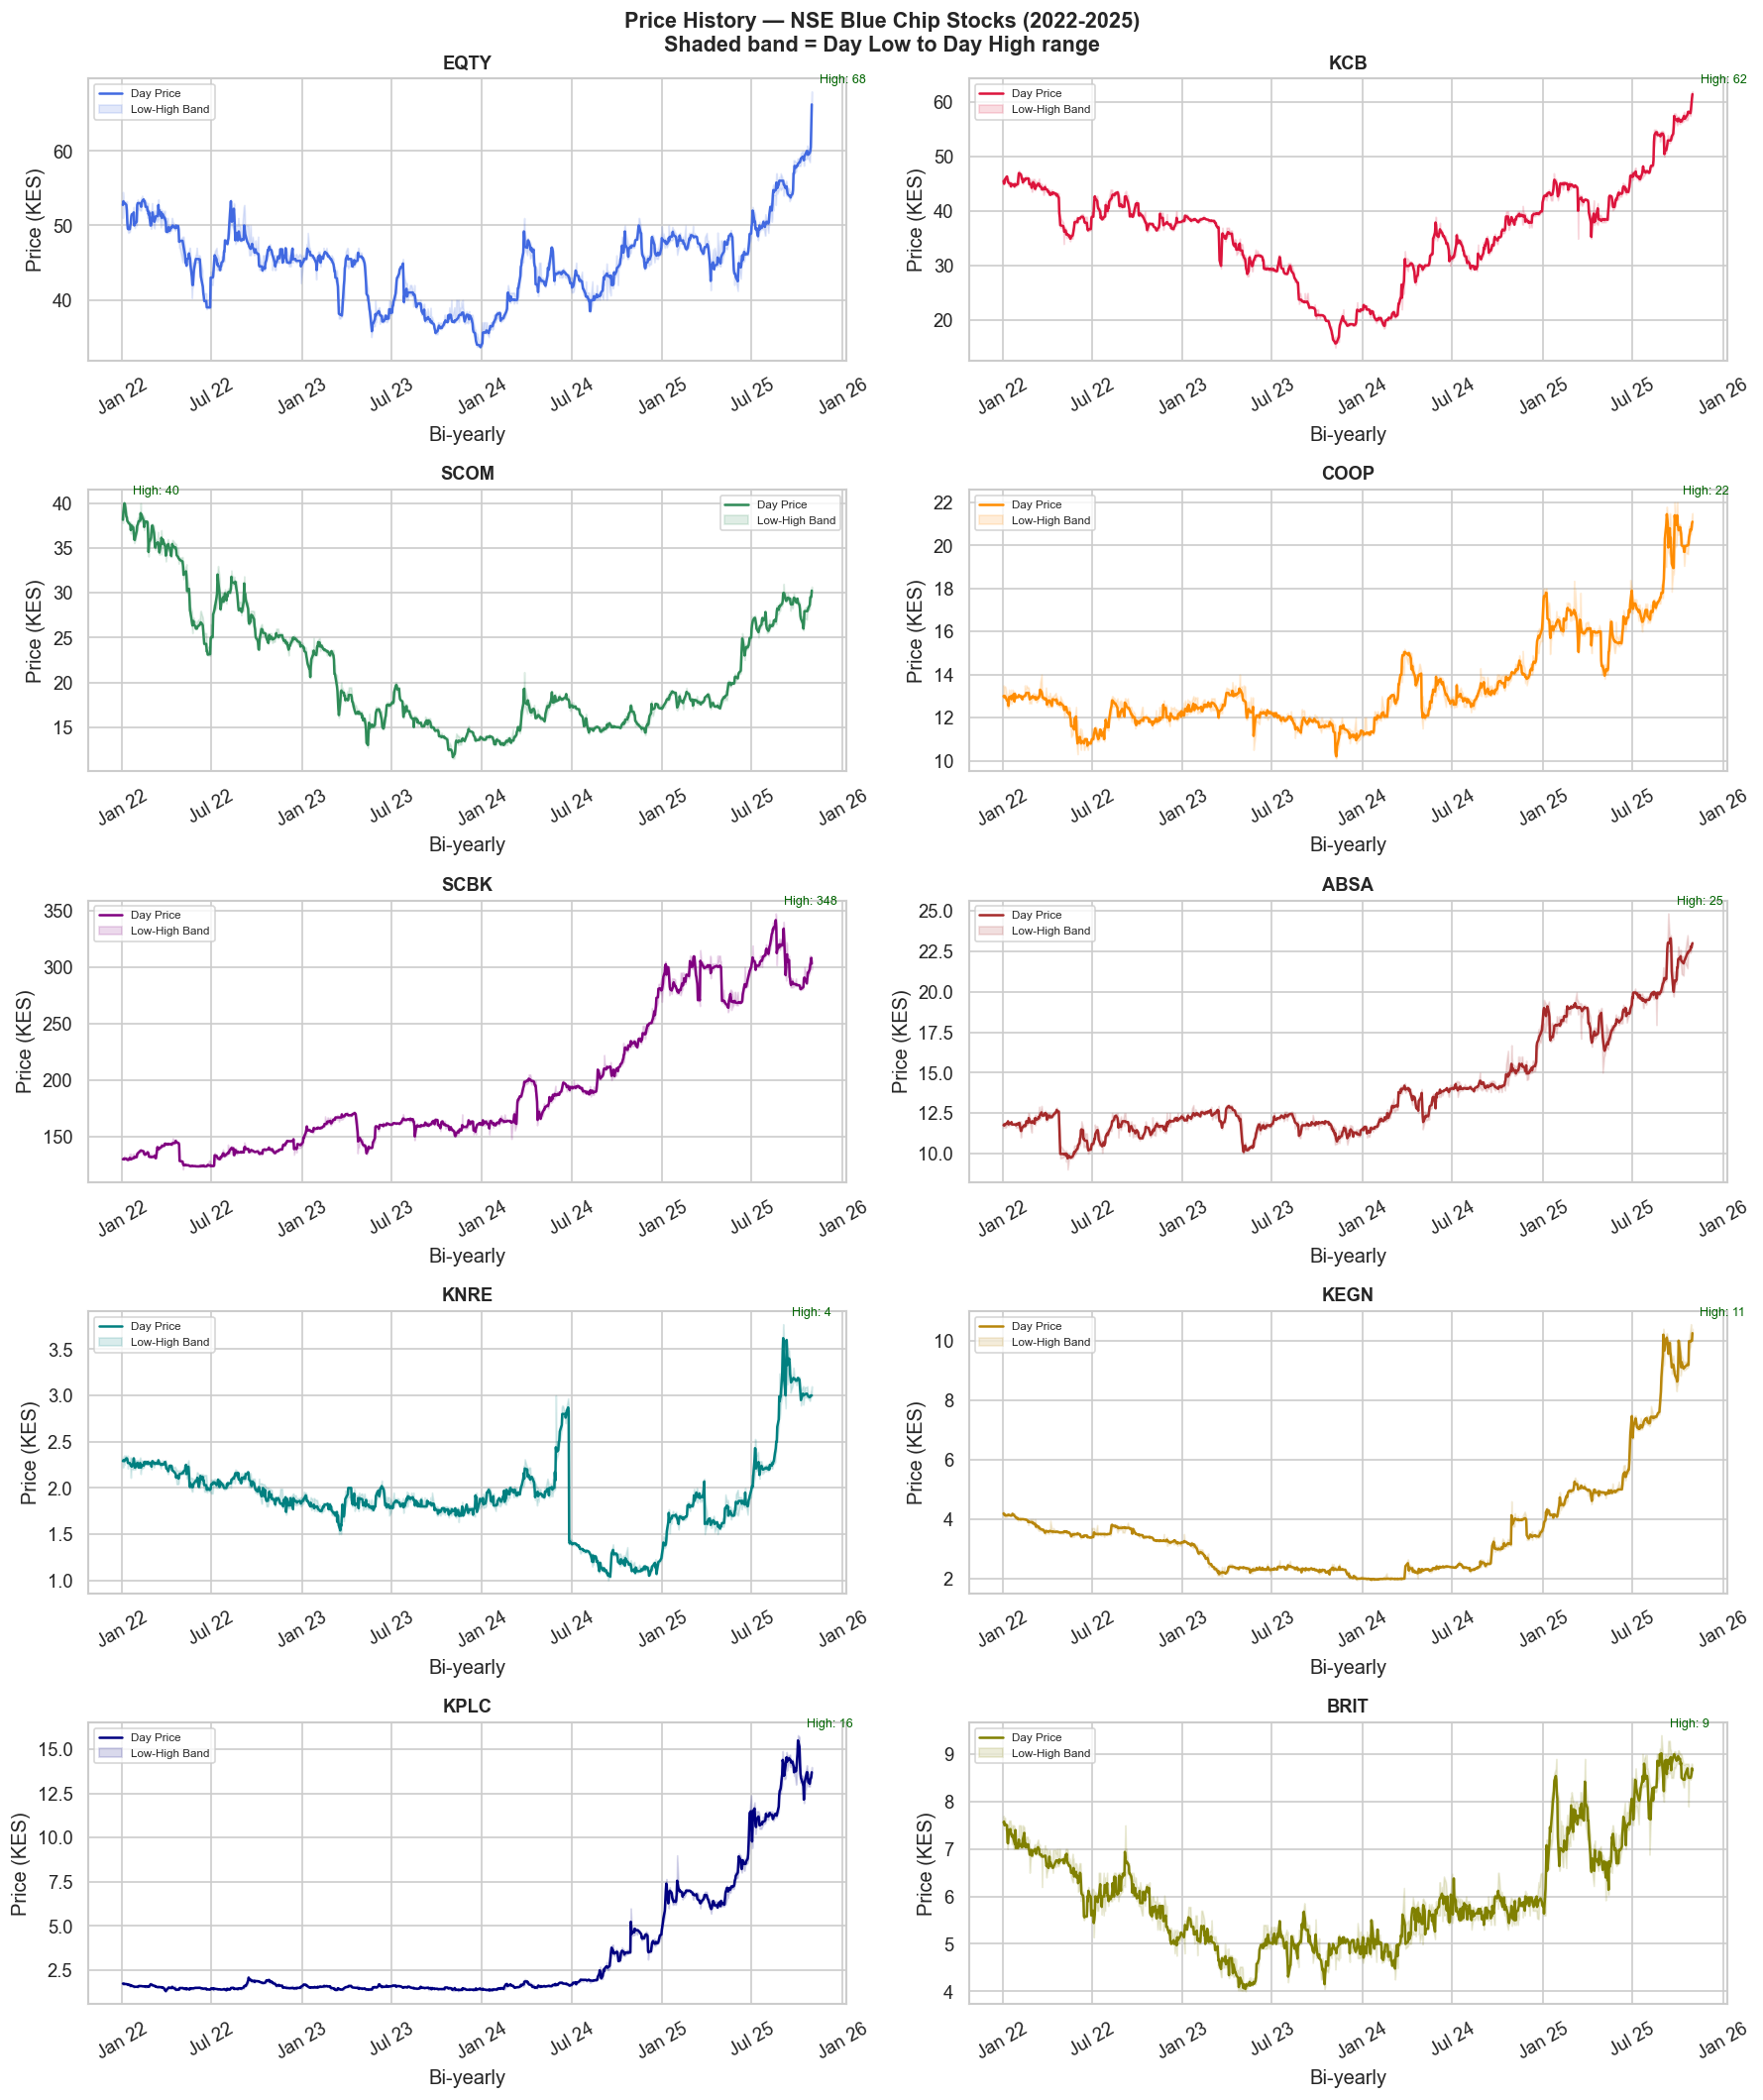

In [18]:
colors_bc = ['royalblue','crimson','seagreen','darkorange',
              'purple','brown','teal','darkgoldenrod','navy','olive']

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes      = axes.flatten()

for i, (code, color) in enumerate(zip(blue_chips, colors_bc)):
    sub = nse_data[nse_data['code'] == code]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].plot(sub['date'], sub['day_price'], color=color, lw=1.5, label='Day Price')
    axes[i].fill_between(sub['date'], sub['day_low'], sub['day_high'],
                         alpha=0.15, color=color, label='Low-High Band')
    idx_max = sub['day_high'].idxmax()
    axes[i].annotate(
        f"High: {sub.loc[idx_max,'day_high']:.0f}",
        xy=(sub.loc[idx_max, 'date'], sub.loc[idx_max, 'day_high']),
        fontsize=7.5, color='darkgreen',
        xytext=(5, 5), textcoords='offset points'
    )
    axes[i].set_title(f'{code}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Price (KES)')
    axes[i].set_xlabel('Bi-yearly')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

fig.suptitle(
    'Price History — NSE Blue Chip Stocks (2022-2025)\n'
    'Shaded band = Day Low to Day High range',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 4.5 Top 15 Most Volatile Stocks

Volatility is measured as the standard deviation of daily log returns. All 15 most volatile stocks are small-cap (none of the blue chips appear). Large, heavily traded stocks have tighter bid-ask spreads and more price stability. This confirms that blue chips are the right focus for a retail limit order tool.

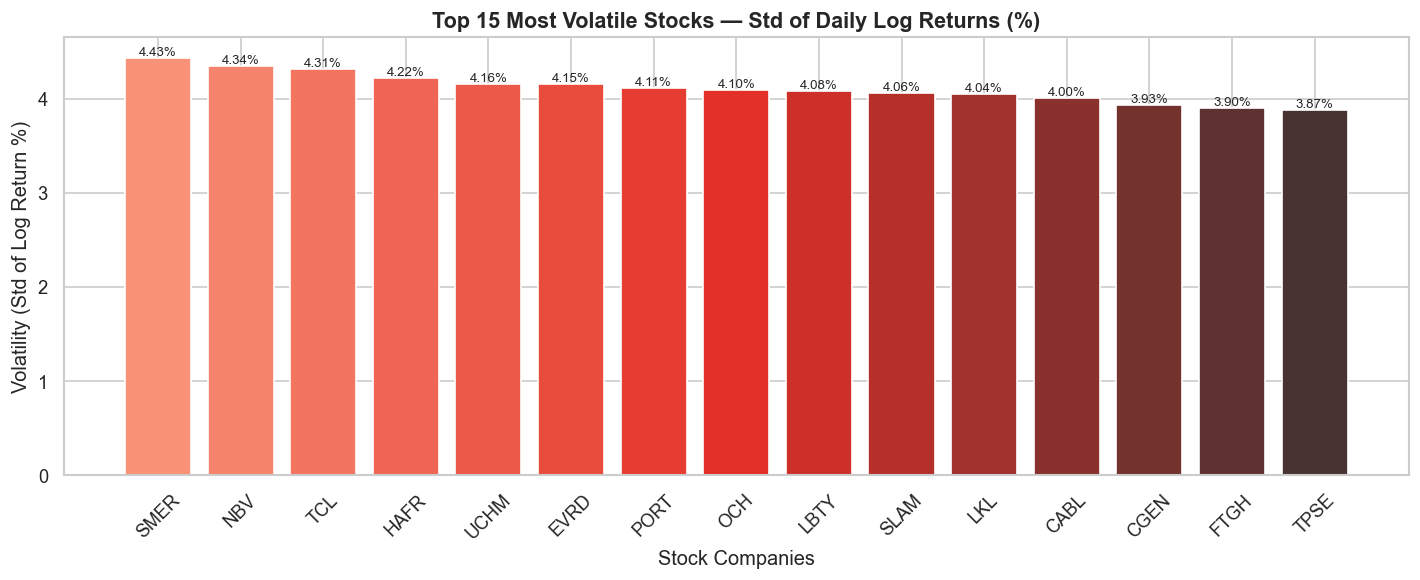

Top 15 Most Volatile Stocks (Daily Log Return Std):
      Volatility %
code              
SMER         4.429
NBV          4.341
TCL          4.310
HAFR         4.217
UCHM         4.159
EVRD         4.152
PORT         4.107
OCH          4.095
LBTY         4.079
SLAM         4.062
LKL          4.045
CABL         4.001
CGEN         3.927
FTGH         3.901
TPSE         3.874


In [19]:
# Exclude HFCK-R, extreme outlier due to rights-issue pricing distortion
vol_std = (nse_data[nse_data['code'] != 'HFCK-R']
           .groupby('code')['log_return']
           .std()
           .dropna()
           .sort_values(ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(vol_std.index, vol_std.values * 100,
              color=sns.color_palette('Reds_d', 15), edgecolor='white')
ax.set_title('Top 15 Most Volatile Stocks — Std of Daily Log Returns (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Volatility (Std of Log Return %)')
ax.set_xlabel('Stock Companies')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, vol_std.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val*100:.2f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 Most Volatile Stocks (Daily Log Return Std):')
print((vol_std * 100).round(3).rename('Volatility %').to_frame())

#### Interpretation

SMER leads at 4.43% daily volatility, meaning on any given day, this stock's price can swing by more than 4% in either direction on average. For a retail investor, this is extremely risky without a prediction system.

All 15 stocks here are small-cap or mid-cap, none of the blue chips (EQTY, KCB, SCOM, SCBK) appear. This is expected. Large, heavily traded stocks have tighter bid-ask spreads and more price stability. Small illiquid stocks swing wildly because a single large trade can move the price significantly.

### 4.6 Year-Over-Year Price Trends for Blue Chip Stocks

Yearly average prices reveal structural trends. SCBK nearly doubled from KES 135 to KES 294 over four years. SCOM fell 48% through 2024 before partially recovering. KPLC and KEGN show dramatic 2025 jumps driven by energy sector regulatory changes (these structural breaks represent the main limitation of any price-history model).

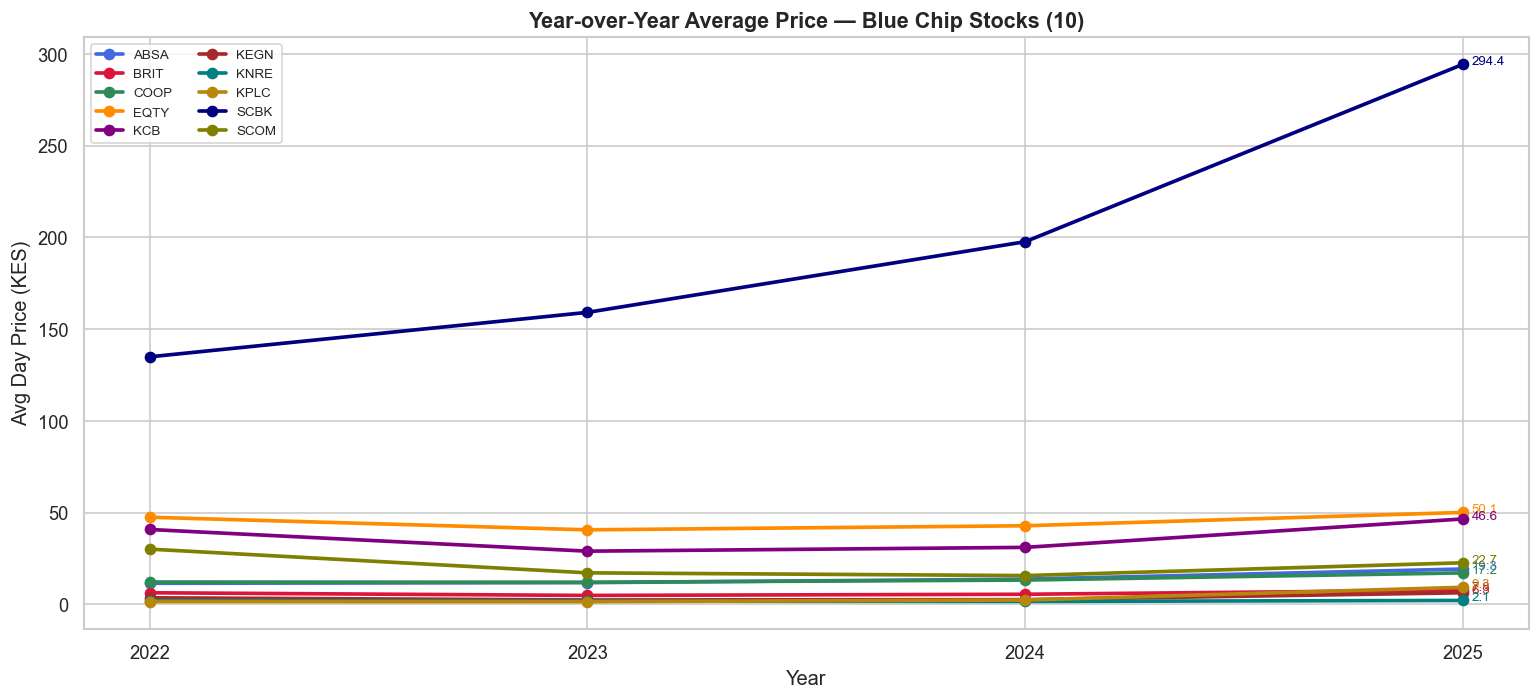


Yearly Average Prices (KES):
year    2022    2023    2024    2025
code                                
ABSA   11.49   11.84   13.77   19.27
BRIT    6.33    4.88    5.52    7.76
COOP   12.19   12.06   13.26   17.16
EQTY   47.50   40.63   42.85   50.13
KCB    40.82   29.00   31.07   46.57
KEGN    3.59    2.40    2.58    6.32
KNRE    2.08    1.81    1.62    2.15
KPLC    1.57    1.50    2.36    9.31
SCBK  134.93  159.16  197.68  294.41
SCOM   30.12   17.18   15.70   22.68


In [20]:
yearly_avg = (nse_data[nse_data['code'].isin(blue_chips)]
              .groupby(['code', 'year'])['day_price']
              .mean()
              .unstack())

fig, ax = plt.subplots(figsize=(13, 6))
for code, color in zip(yearly_avg.index, colors_bc):
    ax.plot(yearly_avg.columns.astype(str), yearly_avg.loc[code],
            marker='o', lw=2.2, label=code, color=color)
    ax.annotate(
        f'{yearly_avg.loc[code].iloc[-1]:.1f}',
        xy=(str(yearly_avg.columns[-1]), yearly_avg.loc[code].iloc[-1]),
        xytext=(5, 0), textcoords='offset points', fontsize=8, color=color
    )
ax.set_title('Year-over-Year Average Price — Blue Chip Stocks (10)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Day Price (KES)')
ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print('\nYearly Average Prices (KES):')
print(yearly_avg.round(2))



#### Interpretation

SCBK (Stanbic Bank) is the standout performer of the entire dataset. Its price nearly doubled from KES 134.93 in 2022 to KES 294.41 in 2025, a gain of 118%. This is driven by strong earnings growth and foreign investor interest in Kenyan banking stocks.

KCB had a dramatic fall from KES 40.82 in 2022 to KES 29.00 in 2023. A 29% drop in one year largely linked to concerns about loan book quality and regional expansion costs in Ethiopia and DRC. It has since recovered to KES 46.57 in 2025, surpassing its 2022 levels.

SCOM (Safaricom) fell from KES 30.12 in 2022 to just KES 15.70 in 2024, a 48% decline driven by Ethiopia launch losses and rising interest rates reducing growth stock valuations. It has partially recovered to KES 22.68 in 2025.

EQTY (Equity Bank) shows a similar dip-and-recover pattern to KCB, falling from KES 47.50 to KES 40.63 in 2023 before recovering to KES 50.13 in 2025.

ABSA and COOP both show consistent, steady upward trends throughout all four years, suggesting more defensive, predictable price behaviour exactly the kind of stocks where prediction models perform best.

### 4.7 Correlation Matrix

The most important finding: `day_price` correlates with `previous` at **0.999**. Yesterday's closing price is already a near-perfect predictor of today's price. This means any model must beat a simple 'predict tomorrow = today' strategy to add real value. `volume` and `changepct` show near-zero correlation with `day_price`, confirming that raw volume alone does not predict price level.

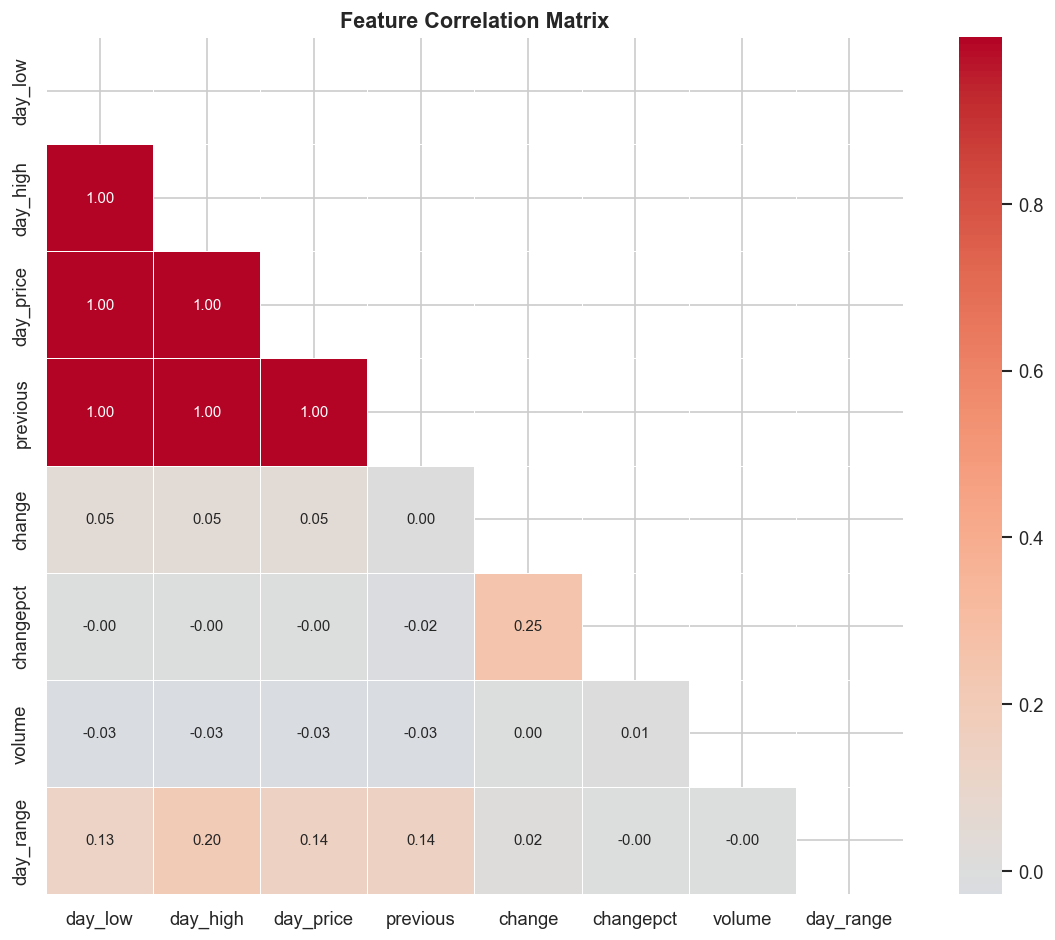


Key correlations with day_price:
day_low      1.000
previous     0.999
day_high     0.998
day_range    0.142
change       0.048
changepct   -0.005
volume      -0.027
Name: day_price, dtype: float64


In [21]:
corr_cols = ['day_low','day_high','day_price','previous',
             'change','changepct','volume','day_range']
corr = nse_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey correlations with day_price:')
print(corr['day_price'].drop('day_price').sort_values(ascending=False).round(3))

#### Interpretation

day_low (1.000) and day_high (0.998) have near-perfect correlation with day_price which makes complete sense since all three move together. A stock priced at KES 50 will have a Low around KES 49 and a High around KES 51.

previous (0.999) is the breakthrough finding. Yesterday's closing price explains 99.9% of today's price level. This is a strong signal where a stock closed yesterday is by far the strongest signal for where it will trade today.

### 4.8 Volume Analysis: Zero-Volume Days and Distribution

Nearly 30% of all trading days across the full NSE dataset had zero volume, meaning no shares changed hands. This is a characteristic of the Kenyan market, not a data error. Focusing on blue chips significantly reduces this problem.

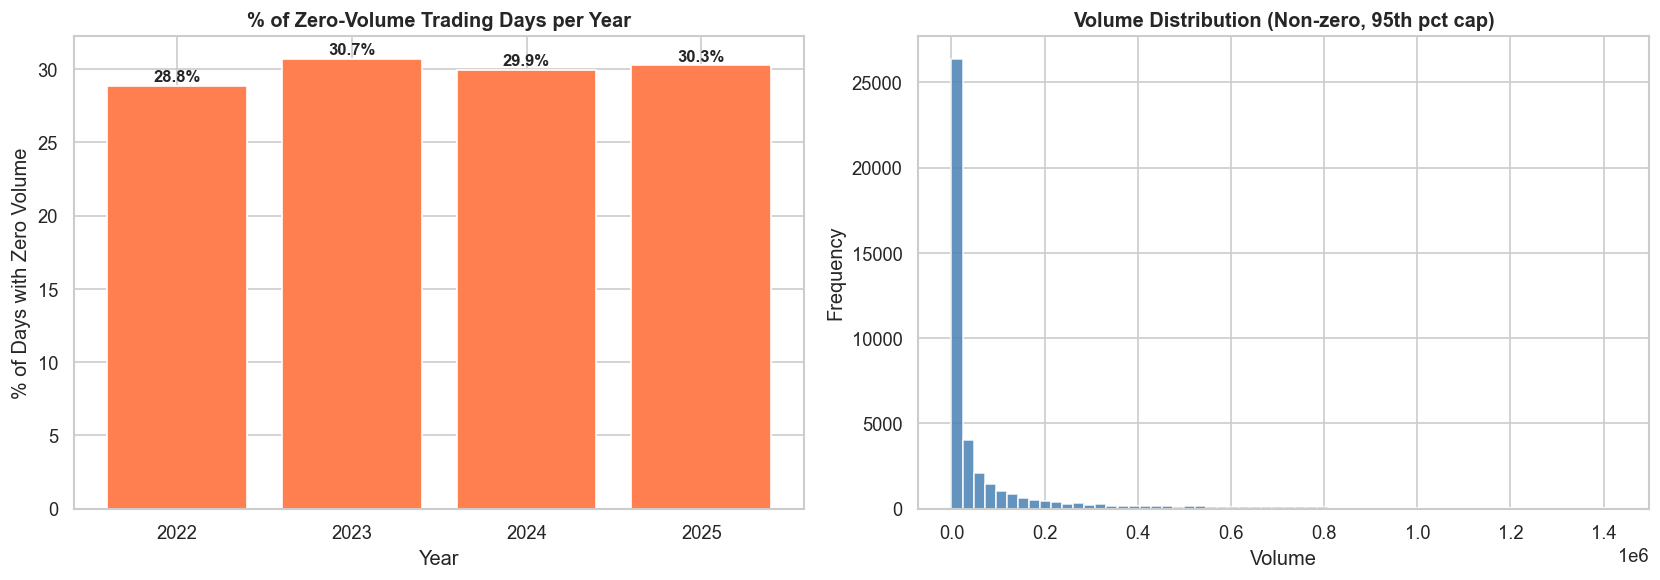

Total zero-volume records : 18,878 (29.9%)
Total non-zero records    : 44,181

Volume stats (non-zero):
count        44181.0
mean        374115.0
std        2512570.0
min              1.0
25%           1700.0
50%          11700.0
75%          81600.0
max      208485900.0
Name: volume, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Zero volume days per year 
zero_by_year = nse_data.groupby('year').apply(
    lambda x: (x['volume'] == 0).mean() * 100
)
axes[0].bar(zero_by_year.index.astype(str), zero_by_year.values,
            color='coral', edgecolor='white')
axes[0].set_title('% of Zero-Volume Trading Days per Year',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('% of Days with Zero Volume')
axes[0].set_xlabel('Year')
for i, v in enumerate(zero_by_year.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Volume distribution (non-zero only, capped at 95th pct) 
vol_nz  = nse_data[nse_data['volume'] > 0]['volume']
cap_v   = vol_nz.quantile(0.95)
axes[1].hist(vol_nz[vol_nz <= cap_v], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Volume Distribution (Non-zero, 95th pct cap)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

total_zero = (nse_data['volume'] == 0).sum()
print(f'Total zero-volume records : {total_zero:,} ({total_zero/len(nse_data)*100:.1f}%)')
print(f'Total non-zero records    : {(nse_data["volume"]>0).sum():,}')
print(f'\nVolume stats (non-zero):')
print(vol_nz.describe().round(0))


#### Interpretation

Nearly 30% of all trading days have zero volume, a striking finding. This means on any given trading day at the NSE, roughly a third of listed stocks see absolutely no shares change hands. This is a direct reflection of the illiquidity problem in the Kenyan market. Many companies are listed but have almost no active trading. For the non-zero volume records, the median is 11,700 shares and the mean is 374,115 but the maximum is 208 million, showing that a handful of stocks (led by SCOM) account for the vast majority of all trading

### 4.9 Intraday Range Analysis

We examine which stocks have the widest intraday high-low spread. Stocks with a wider daily range offer more opportunity for limit order placement, but also carry more risk of the price moving far from the prediction.

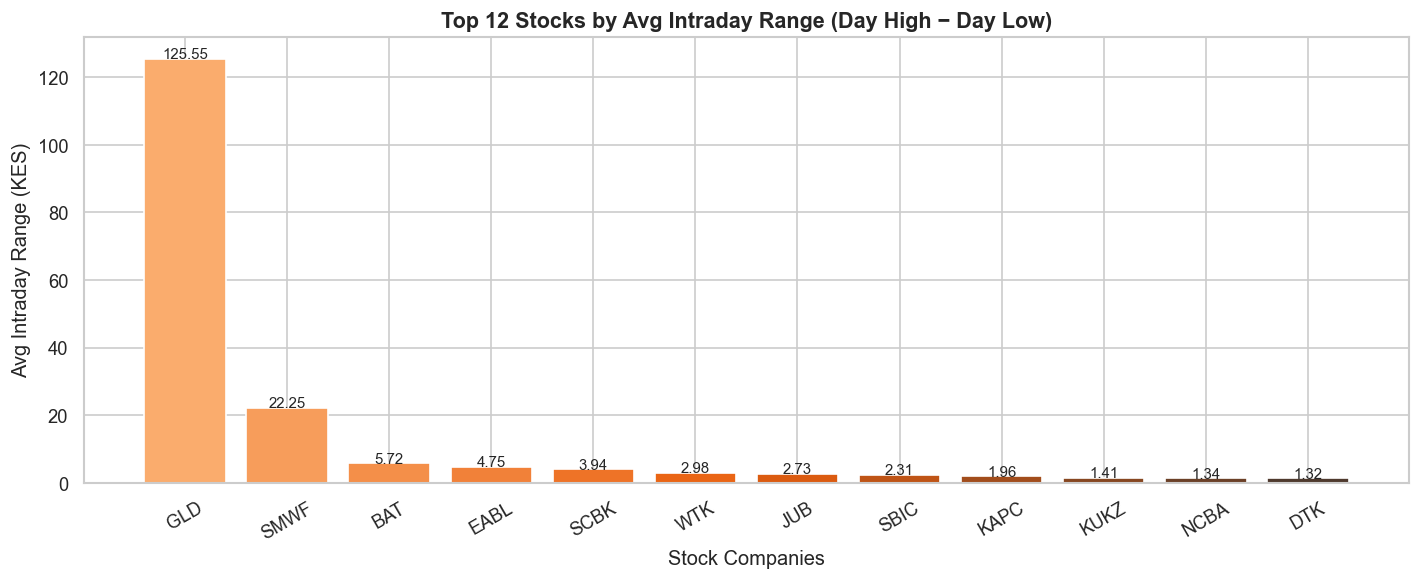


Top 10 by Relative Intraday Range (% of price):
        Range %
code           
HFCK-R   55.688
UCHM      7.131
HAFR      7.001
EVRD      6.621
SMER      5.873
CABL      5.741
HFCK      5.655
BRIT      5.478
CIC       5.236
KPLC      5.080


In [23]:
top_range = (nse_data.groupby('code')['day_range']
             .mean()
             .sort_values(ascending=False)
             .head(12))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_range.index, top_range.values,
       color=sns.color_palette('Oranges_d', 12), edgecolor='white')
ax.set_title('Top 12 Stocks by Avg Intraday Range (Day High − Day Low)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Intraday Range (KES)')
ax.set_xlabel('Stock Companies')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(top_range.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Also show as % of price (relative range)
avg_price = nse_data.groupby('code')['day_price'].mean()
rel_range = (nse_data.groupby('code')['day_range'].mean() / avg_price * 100).dropna()
print('\nTop 10 by Relative Intraday Range (% of price):')
print(rel_range.sort_values(ascending=False).head(10).round(3).rename('Range %').to_frame())

#### Interpretation

HFCK-R's 55.69% relative range is a data anomaly from the rights-issue period and should be excluded from comparisons. For genuine stocks, UCHM, HAFR, and EVRD all have intraday ranges exceeding 6% of their price meaning on a typical day, the stock swings by over 6% between its lowest and highest point. For a retail investor, this is the opportunity the prediction system is designed to exploit if you can predict that a stock's Day Low will be around KES 9.50 and its Day High will be around KES 10.10, you can place a limit buy near 9.50 and a limit sell near 10.10, capturing that 6% spread systematically.

### 4.10 Return Distributions for Blue Chip Stocks

All blue chip stocks show kurtosis well above 3, meaning extreme daily moves happen more often than a normal distribution would predict. This is relevant for setting expectations about forecast errors (on most days the model will be close, but rare extreme days will produce larger errors).

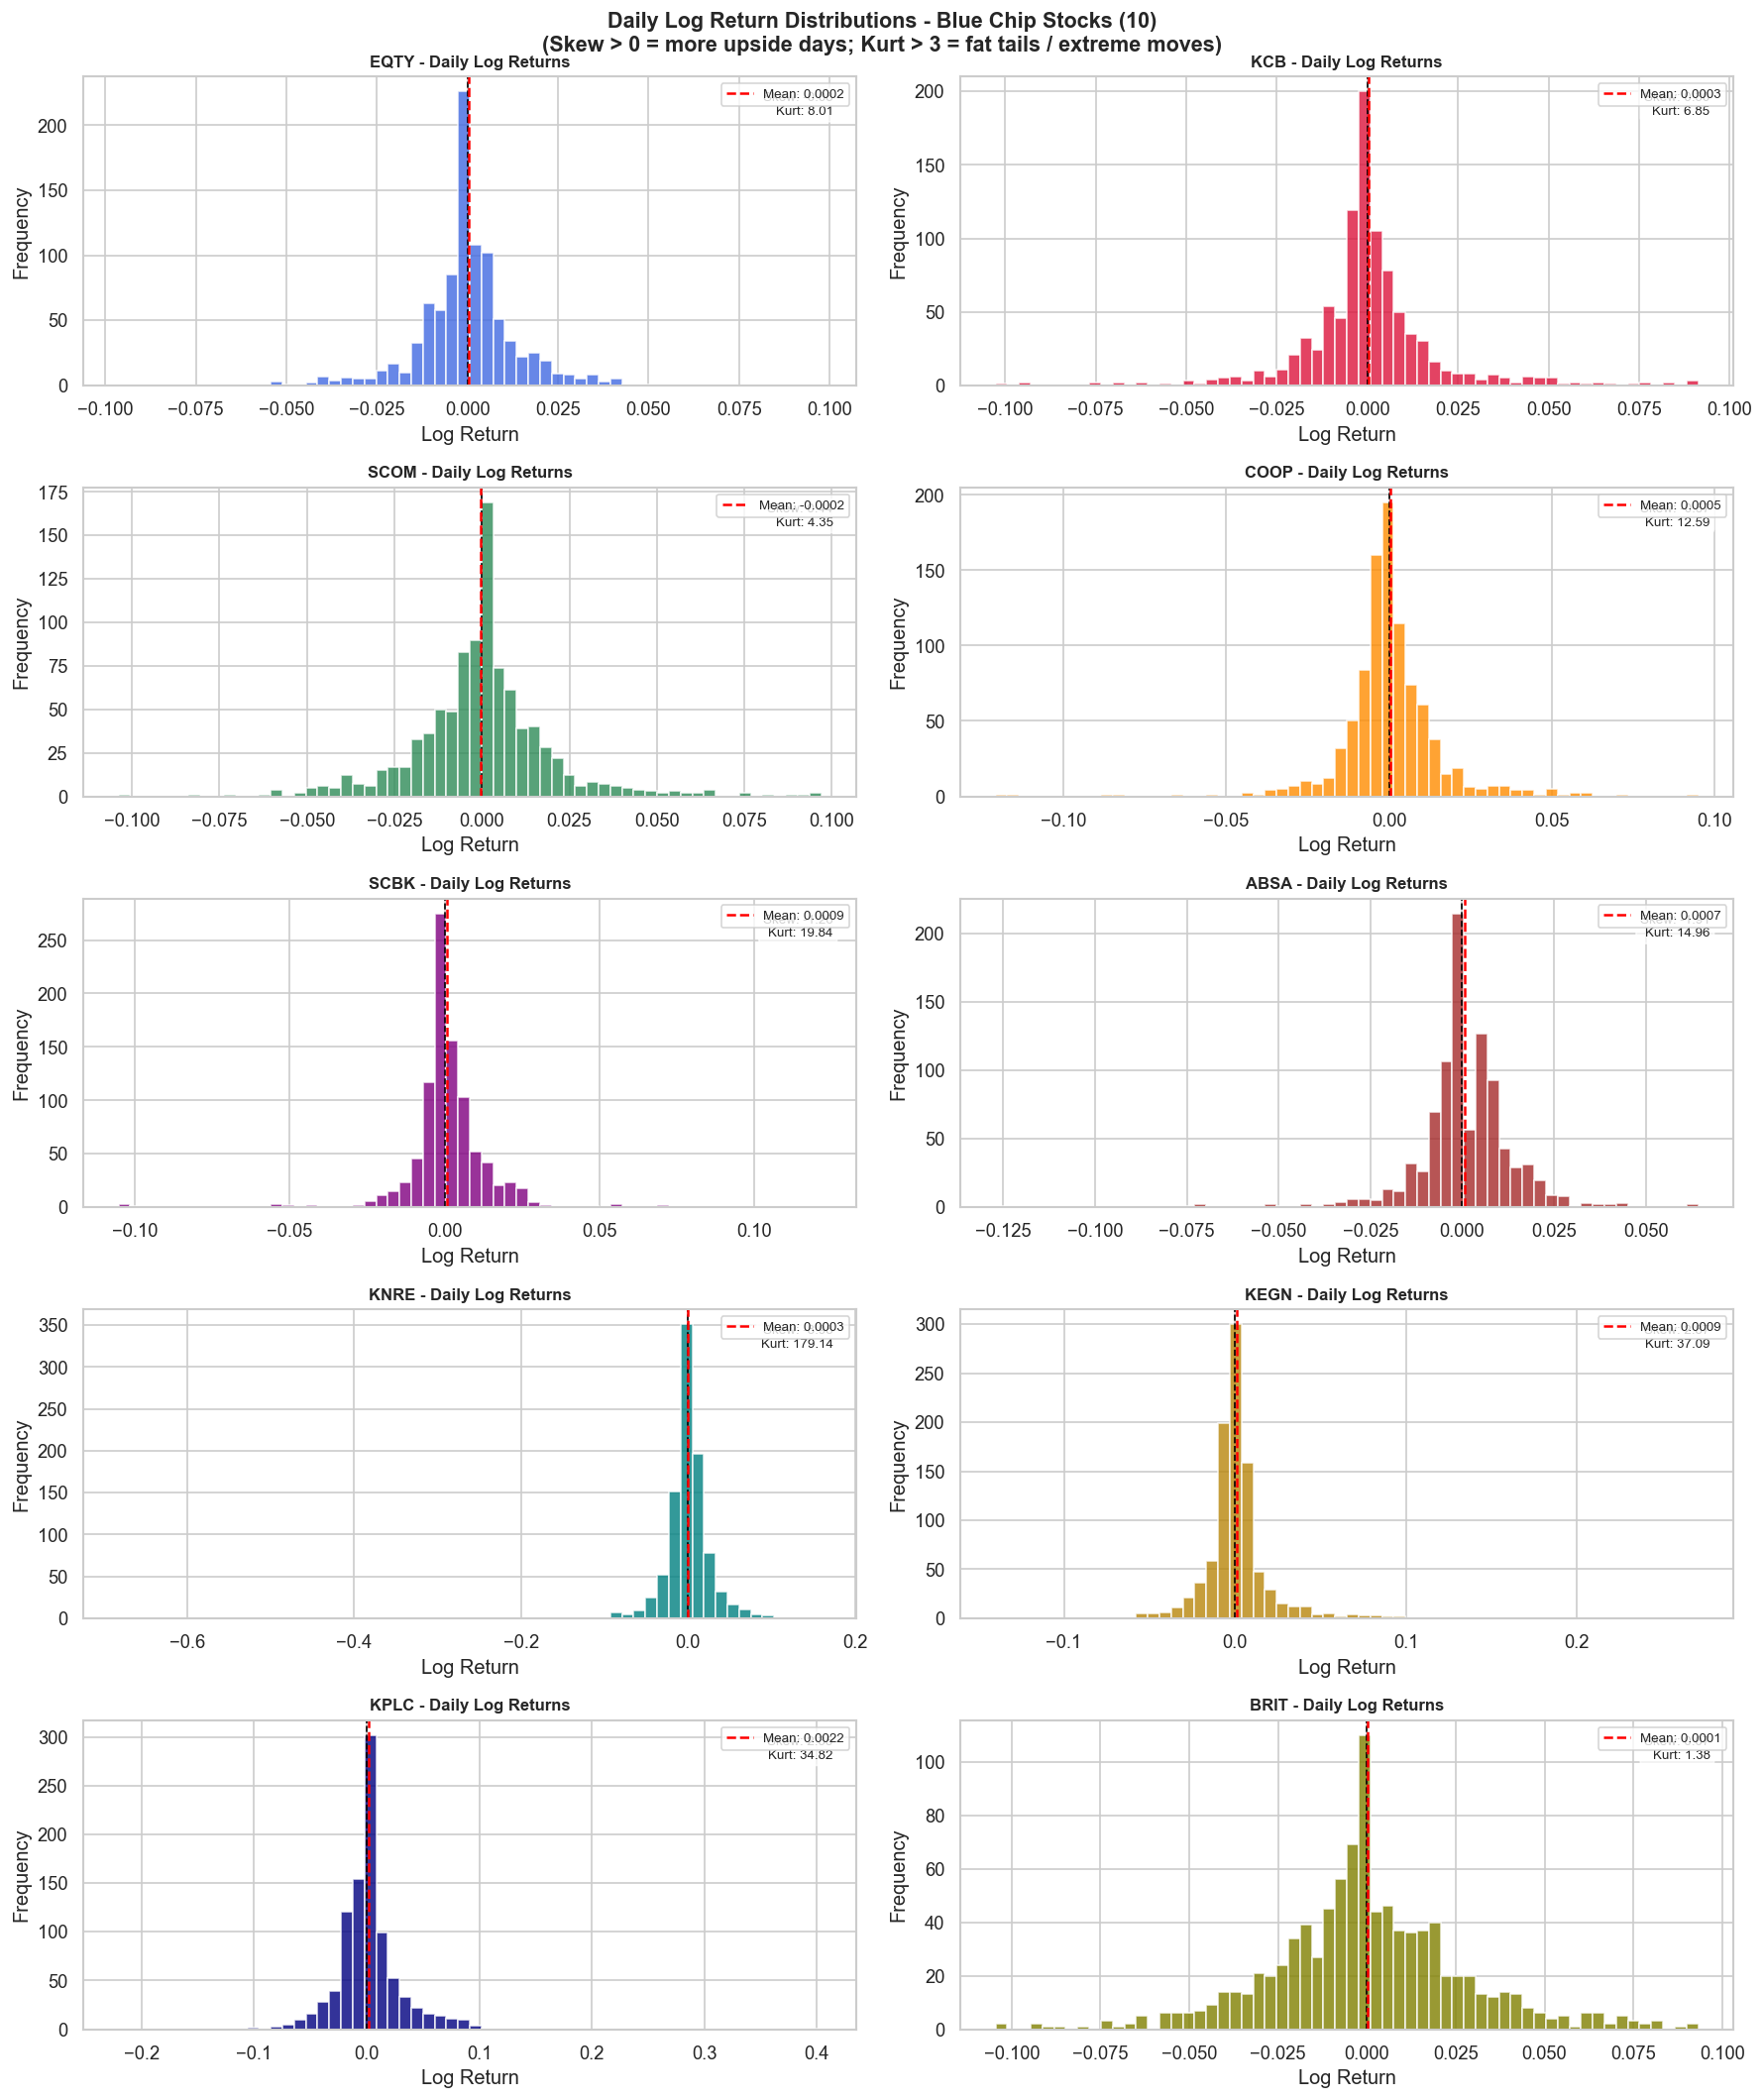

Return Statistics Summary:
       Mean Return  Std (Vol)  Skewness  Kurtosis  Max Gain%  Max Loss%
Stock                                                                  
EQTY       0.00024    0.01479    -0.083     8.009       9.76      -9.63
KCB        0.00032    0.01865     0.301     6.854       9.13     -10.26
SCOM      -0.00025    0.01995     0.436     4.354       9.69     -10.38
COOP       0.00051    0.01537    -0.567    12.591       9.50     -12.09
SCBK       0.00090    0.01483    -1.262    19.840      12.17     -10.54
ABSA       0.00071    0.01449    -1.914    14.956       6.43     -12.71
KNRE       0.00029    0.03385    -8.979   179.138      15.96     -68.26
KEGN       0.00095    0.02050     2.867    37.089      27.09     -14.00
KPLC       0.00219    0.03058     2.352    34.823      40.36     -22.03
BRIT       0.00014    0.02731     0.072     1.381       9.32     -10.45


In [24]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes      = axes.flatten()

for i, (code, color) in enumerate(zip(blue_chips, colors_bc)):
    sub = nse_data[nse_data['code'] == code]['log_return'].dropna()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].hist(sub, bins=60, color=color, edgecolor='white', alpha=0.8)
    axes[i].axvline(0,          color='black', lw=1,   linestyle='--')
    axes[i].axvline(sub.mean(), color='red',   lw=1.5, linestyle='--',
                    label=f'Mean: {sub.mean():.4f}')
    axes[i].set_title(f'{code} - Daily Log Returns', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Log Return')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].text(
        0.97, 0.95,
        f'Skew: {sub.skew():.2f}\nKurt: {sub.kurt():.2f}',
        transform=axes[i].transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

fig.suptitle('Daily Log Return Distributions - Blue Chip Stocks (10)\n'
             '(Skew > 0 = more upside days; Kurt > 3 = fat tails / extreme moves)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Return Statistics Summary:')
stats = []
for code in blue_chips:
    sub = nse_data[nse_data['code'] == code]['log_return'].dropna()
    if sub.empty:
        continue
    stats.append({
        'Stock':        code,
        'Mean Return':  round(sub.mean(), 5),
        'Std (Vol)':    round(sub.std(),  5),
        'Skewness':     round(sub.skew(), 3),
        'Kurtosis':     round(sub.kurt(), 3),
        'Max Gain%':    round(sub.max() * 100, 2),
        'Max Loss%':    round(sub.min() * 100, 2),
    })
print(pd.DataFrame(stats).set_index('Stock').to_string())


#### Interpretation

Mean Return: SCBK has the highest daily mean return at 0.00090 (about 0.09% per day) which compounded over 250 trading days per year explains its 118% gain over 4 years. SCOM is the only blue chip with a negative mean return (-0.00025).

Std (Volatility): SCOM is the most volatile blue chip at 1.995% daily standard deviation, while ABSA is the most stable at 1.449%.

Skewness: EQTY (-0.083) and KCB (+0.301) are roughly symmetric their gains and losses are balanced. ABSA (-1.914) and SCBK (-1.262) are strongly negatively skewed, meaning they have many small positive days but occasional large sudden drops.

Kurtosis: All six stocks have kurtosis well above 3 (the normal distribution threshold). SCBK at 19.84 and COOP at 12.59 are extreme, their return distributions have very fat tails, meaning large sudden price moves occur far more frequently than a normal distribution would predict.

Max Gain / Max Loss: Every blue chip has seen single-day moves of nearly + or - 10%. SCBK's best single day was +12.17% and ABSA's worst was -12.71%. These extreme single-day events are typically tied to earnings announcements, dividend declarations, or major macro news.

## 5. Feature Engineering

All features are constructed from **past data only**. Every lag and rolling calculation uses `.shift(1)` so today's model input never includes today's outcome. This prevents data leakage which is common in financial ML models.

We restrict to 10 blue-chip stocks selected for their liquidity, data completeness, and direct relevance to retail investors.

### 5.1 Lag Features

We use lag features because our EDA showed day-to-day price autocorrelation of 0.999. Lag features give the model yesterday's price, two days ago, and three days ago so it can detect short-term momentum. We apply lags to price and volume.

In [25]:

nse_data['price_roll5_mean'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
nse_data['price_ewm5'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=5).mean()
)

In [26]:
# Sort by stock and date first
nse_data = nse_data[nse_data['code'].isin(blue_chips)].copy()

#  Lag features 
# "What was the price yesterday, two days ago, three days ago?"
# .shift(1) per stock means we never use today's value to predict today

nse_data['price_lag1'] = nse_data.groupby('code')['day_price'].shift(1)
nse_data['price_lag2'] = nse_data.groupby('code')['day_price'].shift(2)
nse_data['price_lag3'] = nse_data.groupby('code')['day_price'].shift(3)

nse_data['low_lag1']   = nse_data.groupby('code')['day_low'].shift(1)
nse_data['low_lag2']   = nse_data.groupby('code')['day_low'].shift(2)

nse_data['high_lag1']  = nse_data.groupby('code')['day_high'].shift(1)
nse_data['high_lag2']  = nse_data.groupby('code')['day_high'].shift(2)

nse_data['volume_lag1'] = nse_data.groupby('code')['volume'].shift(1)

### 5.2 Rolling Mean Features

Since individual daily prices are noisy, a 5-day and 20-day rolling average smooths that noise and reveals the underlying short and medium-term trend the model can learn from.

In [ ]:
# Rolling means and std 
nse_data['price_roll5_mean']  = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
nse_data['price_roll20_mean'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(20).mean()
)
nse_data['price_roll5_std']   = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).rolling(5).std()
)

### 5.3 Exponentially Weighted Mean (EWM)

EWM serves the same purpose as rolling mean but gives more weight to recent days, making it more responsive to sudden price changes than a simple average.

In [ ]:
# Exponentially Weighted Mean 
# Like a rolling mean but more weight on recent days 
nse_data['price_ewm5']  = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=5).mean()
)
nse_data['price_ewm20'] = nse_data.groupby('code')['day_price'].transform(
    lambda x: x.shift(1).ewm(span=20).mean()
)

### 5.4 52-Week Relative Position

This feature shows where today's price sits within its annual high-low range. 

- 0 = at the yearly low
- 1 = at the yearly high

A stock near its annual high behaves differently from one near its annual low. Helps the model understand whether the stock is stretched or depressed.

In [ ]:
# 52-week relative position
nse_data['price_pos_52w'] = (
    (nse_data['day_price'] - nse_data['12m_low']) /
    (nse_data['12m_high'] - nse_data['12m_low'] + 1e-6)
)

### 5.5 Volume Ratio

Unusual trading activity often comes before a price move. We compare yesterday's volume to the 20-day average volume to flag abnormal activity.

In [ ]:
#  Volume ratio
# "Is today's volume unusually high or low vs the recent norm?"
nse_data['vol_roll20_mean'] = nse_data.groupby('code')['volume'].transform(
    lambda x: x.shift(1).rolling(20).mean()
)
nse_data['volume_ratio'] = nse_data['volume_lag1'] / (nse_data['vol_roll20_mean'] + 1e-6)

print(nse_data['volume_ratio'].describe())
print()
print("Extreme values (>100):", (nse_data['volume_ratio'] > 100).sum())
print("NaN count:", nse_data['volume_ratio'].isna().sum())

count    9253.000000
mean        1.044691
std         1.546309
min         0.000000
25%         0.226316
50%         0.537377
75%         1.206769
max        19.735930
Name: volume_ratio, dtype: float64

Extreme values (>100): 0
NaN count: 200


### 5.6 Day of Week

Markets may behave differently by weekday; for example, Monday open effects or Friday close patterns. Encoding as a number (Monday=0, Friday=4) lets the model learn any such patterns.

In [ ]:
# Day of week 
# Monday=0, Friday=4. Markets behave slightly differently by weekday
nse_data['dow_num'] = nse_data['date'].dt.dayofweek

### 5.7 Target Variable

`next_day_price` - tomorrow's actual closing price, created by shifting each stock's price series one row forward. 

In [ ]:
# Create targets
# .shift(-1) moves tomorrow's value into today's row
nse_data['next_day_low']   = nse_data.groupby('code')['day_low'].shift(-1)
nse_data['next_day_high']  = nse_data.groupby('code')['day_high'].shift(-1)
nse_data['next_day_price'] = nse_data.groupby('code')['day_price'].shift(-1)


### 5.8 Drop Rows with Missing Targets or Lags

The last row per stock has no next-day target (there is no tomorrow to predict). The first few rows per stock have no lag history yet. Both are dropped.

In [ ]:
# Drop rows with missing targets or missing lag1 
# First few rows per stock have no lag history yet
nse_data = nse_data.dropna(subset=[
    'next_day_low', 'next_day_high', 'next_day_price', 'price_lag1'
]).reset_index(drop=True)


In [35]:
print(f'Shape after feature engineering: {nse_data.shape}')
print(f'Date range: {nse_data["date"].min().date()} to {nse_data["date"].max().date()}')

Shape after feature engineering: (9433, 38)
Date range: 2022-01-04 to 2025-10-30


In [36]:
nse_data['day_high'] = nse_data['day_high'].fillna(nse_data['day_price'])
nse_data['day_low']  = nse_data['day_low'].fillna(nse_data['day_price'])
nse_data['volume']   = nse_data['volume'].fillna(0)

# Daily return
nse_data['daily_return'] = nse_data.groupby('code')['day_price'].pct_change()

# Lag features — returns not prices
for lag in [1, 2, 3]:
    nse_data[f'return_lag{lag}'] = nse_data.groupby('code')['daily_return'].shift(lag)
    nse_data[f'low_lag{lag}']    = nse_data.groupby('code')['day_low'].shift(lag)
    nse_data[f'high_lag{lag}']   = nse_data.groupby('code')['day_high'].shift(lag)

nse_data['volume_lag1'] = nse_data.groupby('code')['volume'].shift(1)

# Rolling stats on returns
nse_data['return_roll5_mean']  = nse_data.groupby('code')['daily_return'].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
nse_data['return_roll20_mean'] = nse_data.groupby('code')['daily_return'].transform(
    lambda x: x.shift(1).rolling(20).mean()
)
nse_data['return_roll5_std']   = nse_data.groupby('code')['daily_return'].transform(
    lambda x: x.shift(1).rolling(5).std()
)

# EWM on returns
nse_data['return_ewm5']  = nse_data.groupby('code')['daily_return'].transform(
    lambda x: x.shift(1).ewm(span=5).mean()
)
nse_data['return_ewm20'] = nse_data.groupby('code')['daily_return'].transform(
    lambda x: x.shift(1).ewm(span=20).mean()
)

# Context features — these are already stationary/bounded so keep as is
denom = (nse_data['12m_high'] - nse_data['12m_low']).replace(0, np.nan)
nse_data['price_pos_52w'] = (nse_data['day_price'] - nse_data['12m_low']) / denom
nse_data['price_pos_52w'] = nse_data['price_pos_52w'].fillna(0.5)

nse_data['vol_roll20_mean'] = nse_data.groupby('code')['volume'].transform(
    lambda x: x.shift(1).rolling(20).mean()
)
nse_data['volume_ratio'] = nse_data['volume_lag1'] / (nse_data['vol_roll20_mean'] + 1e-6)
nse_data['dow_num']      = nse_data['date'].dt.dayofweek
nse_data['range_lag1']   = nse_data['high_lag1'] - nse_data['low_lag1']

# Targets — returns not prices
nse_data['next_day_return'] = nse_data.groupby('code')['daily_return'].shift(-1)
nse_data['next_day_low']    = nse_data.groupby('code')['day_low'].shift(-1)
nse_data['next_day_high']   = nse_data.groupby('code')['day_high'].shift(-1)
nse_data['next_day_price']  = nse_data.groupby('code')['day_price'].shift(-1)

nse_data = nse_data.dropna(subset=[
    'next_day_return', 'next_day_price', 'return_lag1'
]).reset_index(drop=True)

print(f'Shape after feature engineering: {nse_data.shape}')
print(f'Date range: {nse_data["date"].min().date()} to {nse_data["date"].max().date()}')

Shape after feature engineering: (9403, 50)
Date range: 2022-01-06 to 2025-10-29


## 6. Modelling

### 6.1 Walk-Forward Split

Stock data is sequential. Splitting randomly would let the model train on future data to predict the past — this is called data leakage and produces artificially good metrics.

We use a strict time-based split:
- **Train:** 2022–2023 - what the model learns from
- **Validation:** 2024 - used to compare and tune models
- **Test:** 2025 - touched once at the very end, after all decisions are locked

In [37]:
TRAIN_END = '2023-12-31'
VAL_END   = '2024-12-31'

train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print(f'Train : {train["date"].min().date()} - {train["date"].max().date()}  ({len(train):,} rows)')
print(f'Val   : {val["date"].min().date()} - {val["date"].max().date()}  ({len(val):,} rows)')
print(f'Test  : {test["date"].min().date()} - {test["date"].max().date()}  ({len(test):,} rows)')

Train : 2022-01-06 - 2023-12-29  (4,853 rows)
Val   : 2024-01-02 - 2024-12-31  (2,490 rows)
Test  : 2025-01-02 - 2025-10-29  (2,060 rows)


### 6.2 Evaluation Metric Setup

We use three metrics:
- **MAE** - average KES error. Directly interpretable: 'on average, the forecast is off by X shillings.'
- **RMSE** - penalises large errors more than MAE. If RMSE > MAE, the model occasionally makes very bad forecasts.
- **MAPE** - percentage error, useful for comparing across stocks at different price levels (SCOM at KES 15 vs SCBK at KES 294).

In [38]:
TARGETS = ['day_low', 'day_high', 'day_price']
TARGET_LABELS = {'day_low': 'Day Low', 'day_high': 'Day High', 'day_price': 'Day Price'}

results = {}  # cllect all model results here

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    if label:
        print(f'  {label:<30} MAE={mae:>8.4f}  RMSE={rmse:>8.4f}  MAPE={mape:>6.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

### 6.3 Baseline 1 - Persistence

**What it is:** Predicts tomorrow price = today's closing price. 

With autocorrelation of 0.999, this is the hardest baseline to beat in financial forecasting. If any model cannot beat this, it has learned nothing useful beyond what is already obvious.

In [39]:
results['Persistence'] = {}

# For day_price: predict next_day_price = price_lag1 (yesterday's price, from val's perspective)
# For day_low:   predict next_day_low  = low_lag1
# For day_high:  predict next_day_high = high_lag1

persistence_map = {
    'day_price': 'price_lag1',
    'day_low':   'low_lag1',
    'day_high':  'high_lag1',
}

for target in TARGETS:
    lag_col = persistence_map[target]
    mask = val[lag_col].notna()
    y_true = val.loc[mask, f'next_{target}']
    y_pred = val.loc[mask, lag_col]
    metrics = evaluate(y_true, y_pred, label=TARGET_LABELS[target])
    results['Persistence'][target] = metrics

  Day Low                        MAE=  0.5438  RMSE=  1.6467  MAPE=  2.16%
  Day High                       MAE=  0.5815  RMSE=  1.6329  MAPE=  2.22%
  Day Price                      MAE=  0.5112  RMSE=  1.4273  MAPE=  2.13%


### 6.4 Baseline 2 - Rolling Mean and EWM
-  Predict tomorrow's price using the average of the last 5 days. The EWM version gives more weight to recent days so it reacts faster to recent moves.
- It smooths out noise. 
- If EWM beats rolling mean, recent days matter more than older history - that's a signal to use shorter windows in your models. If both lose to persistence, the market is mean-reverting on short timescales.

In [40]:
results['Rolling5'] = {}
results['EWM5']     = {}

for target in TARGETS:
    y_true = val[f'next_{target}']
    mask   = val['price_roll5_mean'].notna() & val['price_ewm5'].notna()

    # We use the price rolling/ewm as a proxy for all three targets
    # (a more precise version would compute roll5 for low and high separately 
    y_roll = val['price_roll5_mean']
    y_ewm  = val['price_ewm5']

    print(f'  -- {TARGET_LABELS[target]} --')
    r_metrics = evaluate(y_true[mask], y_roll[mask], label='Rolling 5-day Mean')
    e_metrics = evaluate(y_true[mask], y_ewm[mask],  label='EWM span=5')
    results['Rolling5'][target] = r_metrics
    results['EWM5'][target]     = e_metrics
    print()

  -- Day Low --
  Rolling 5-day Mean             MAE=  0.6667  RMSE=  1.9014  MAPE=  2.91%
  EWM span=5                     MAE=  0.6285  RMSE=  1.8123  MAPE=  2.73%

  -- Day High --
  Rolling 5-day Mean             MAE=  0.9442  RMSE=  2.4555  MAPE=  3.49%
  EWM span=5                     MAE=  0.9109  RMSE=  2.3781  MAPE=  3.36%

  -- Day Price --
  Rolling 5-day Mean             MAE=  0.7122  RMSE=  1.9298  MAPE=  2.82%
  EWM span=5                     MAE=  0.6732  RMSE=  1.8391  MAPE=  2.65%



### 6.5 Baseline Visualisation

Visual check: how closely do persistence and EWM track actual next-day prices for EQTY?

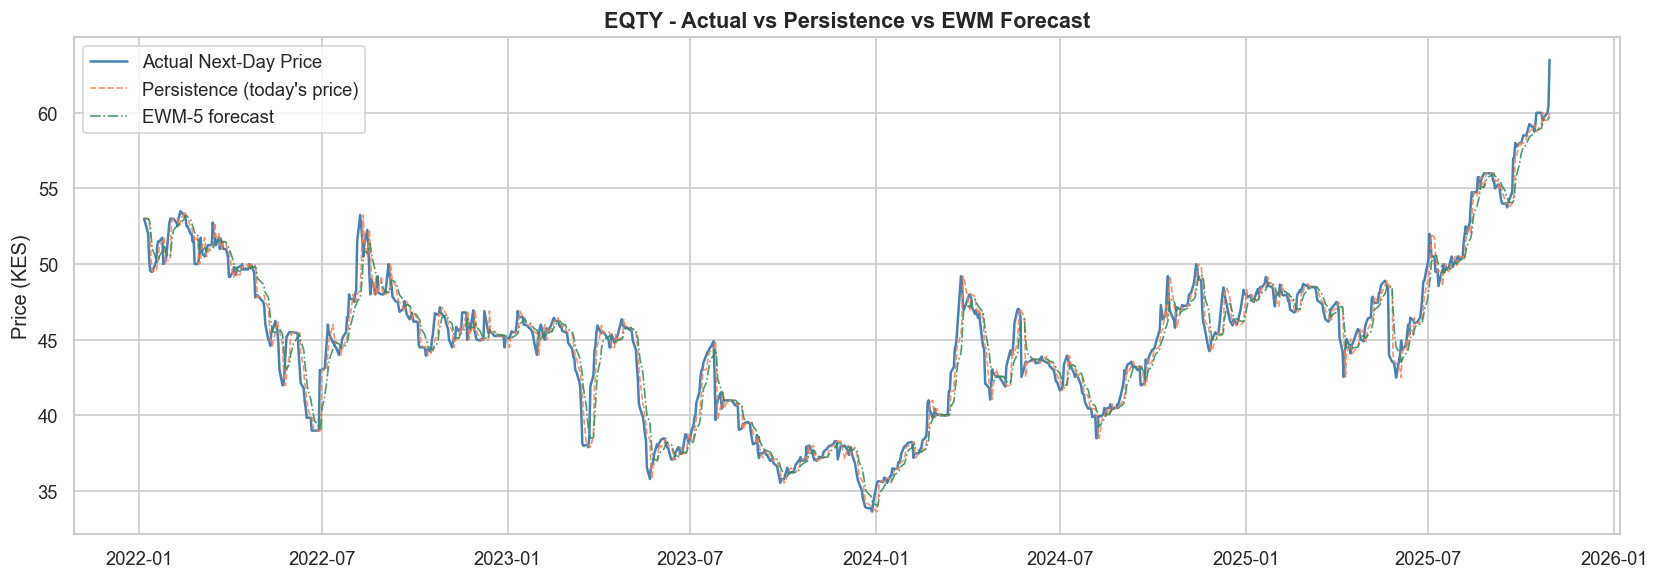

In [41]:

stock = 'EQTY'
sub   = nse_data[nse_data['code'] == stock].copy()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sub['date'], sub['next_day_price'],  label='Actual Next-Day Price',
        color='steelblue', lw=1.5)
ax.plot(sub['date'], sub['price_lag1'],      label='Persistence (today\'s price)',
        color='coral', lw=1, linestyle='--', alpha=0.85)
ax.plot(sub['date'], sub['price_ewm5'],      label='EWM-5 forecast',
        color='seagreen', lw=1, linestyle='-.', alpha=0.85)

ax.set_title(f'{stock} - Actual vs Persistence vs EWM Forecast', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.6 ARIMA Model On Next Day Returns

For all of the 10 blue chip stocks:
 1. Determine stationarity
 2. Transform non-stationary data and determine d 
 3. Plot ACF and PACF to suggest p and q
 4. Fit ARIMA(p, d, q) on training data (2022–2023)
 5. Forecast next-day-return prices for day-price,day-low, day-high for validation period (2024)
 6. Evaluation metrics MAE, RMSE, MAPE (Compare with the other baseline models)

In [42]:
#Determine if the price series is stationary using ADF test

train_sorted = train.sort_values(['code', 'date'])

for code in train_sorted['code'].unique():
    series = train_sorted[train_sorted['code'] == code]['day_price'].dropna()
    result = adfuller(series)
    print(f"{code}: ADF = {result[0]:.4f}, p-value = {result[1]:.4f}")

ABSA: ADF = -3.7318, p-value = 0.0037
BRIT: ADF = -2.1096, p-value = 0.2407
COOP: ADF = -2.9244, p-value = 0.0426
EQTY: ADF = -1.4572, p-value = 0.5546
KCB: ADF = -0.8926, p-value = 0.7904
KEGN: ADF = -0.8745, p-value = 0.7963
KNRE: ADF = -2.2489, p-value = 0.1890
KPLC: ADF = -3.0066, p-value = 0.0343
SCBK: ADF = -1.6879, p-value = 0.4374
SCOM: ADF = -1.7259, p-value = 0.4178


#### Interpretation

Based on the ADF test results at the 0.05 significance level:

1. Stationary stocks (p-value < 0.05): ABSA, COOP, KPLC

2. Non‑stationary stocks (p-value ≥ 0.05): BRIT, EQTY, KCB, KEGN, KNRE, SCBK, SCOM

For the non‑stationary stocks, we first apply transformations

Most of the stocks are non-stationary, which is very typical for financial time series. It means their prices don’t revert to a fixed level and instead evolve over time, so we’ll need to difference the series before modeling. Only a three stocks (ABSA,COOP,KPLC) already show stable behavior, which makes them easier to model directly

In [43]:

# List of non-stationary stocks from your output
non_stationary = ['BRIT', 'EQTY', 'KCB', 'KEGN', 'KNRE', 'SCBK', 'SCOM']

print("Applying first difference to non-stationary stocks")
for code in non_stationary:
    series = train[train['code'] == code].sort_values('date')['day_price'].dropna()
    # First difference
    series_diff = series.diff().dropna()
    # ADF test on differenced series
    result = adfuller(series_diff)
    p_val = result[1]
    stationary = p_val < 0.05
    print(f"{code}: differenced ADF = {result[0]:.4f}, p-value = {p_val:.4f}  {'Stationary' if stationary else 'Still non-stationary'}")

Applying first difference to non-stationary stocks
BRIT: differenced ADF = -26.3343, p-value = 0.0000  Stationary
EQTY: differenced ADF = -7.6038, p-value = 0.0000  Stationary
KCB: differenced ADF = -13.6053, p-value = 0.0000  Stationary
KEGN: differenced ADF = -24.4931, p-value = 0.0000  Stationary
KNRE: differenced ADF = -8.6358, p-value = 0.0000  Stationary
SCBK: differenced ADF = -20.5180, p-value = 0.0000  Stationary
SCOM: differenced ADF = -17.6638, p-value = 0.0000  Stationary


We need to perform a grid search over different combinations of autoregressive (p) and moving average (q) terms (from 0 to 2), selecting the best model based on AIC.

 A lower AIC indicates a better balance between model fit and complexity

In [44]:

stationary_stocks = ['ABSA', 'COOP', 'KPLC']
non_stationary_stocks = ['BRIT', 'EQTY', 'KCB', 'KEGN', 'KNRE', 'SCBK', 'SCOM']

arima_results = {}

for code in stationary_stocks + non_stationary_stocks:
    print(f"{code}")
    
    train_series = train[train['code'] == code].sort_values('date')['day_price'].dropna()
    d = 0 if code in stationary_stocks else 1
    
    best_aic = np.inf
    best_order = None
    best_model = None
    
    for p in range(0, 3):
        for q in range(0, 3):
            try:
                model = ARIMA(train_series, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_model = fitted
            except:
                continue
    
    if best_model is None:
        print(f"  No model converged for {code}")
        arima_results[code] = None   
        continue
    
    print(f"  Best ARIMA{best_order} with AIC = {best_aic:.2f}")
    arima_results[code] = {'best_order': best_order, 'best_aic': best_aic}

ABSA
  Best ARIMA(1, 0, 2) with AIC = -388.94
COOP
  Best ARIMA(1, 0, 0) with AIC = -384.13
KPLC
  Best ARIMA(2, 0, 2) with AIC = -1922.13
BRIT
  Best ARIMA(0, 1, 1) with AIC = -615.54
EQTY
  Best ARIMA(1, 1, 0) with AIC = 969.01
KCB
  Best ARIMA(0, 1, 1) with AIC = 767.26
KEGN
  Best ARIMA(1, 1, 2) with AIC = -1851.70
KNRE
  Best ARIMA(1, 1, 2) with AIC = -1800.74
SCBK
  Best ARIMA(0, 1, 1) with AIC = 2015.18
SCOM
  Best ARIMA(1, 1, 0) with AIC = 694.19


These results confirm that stock price behavior varies significantly across companies, and a single ARIMA configuration is not appropriate for all. 

By selecting the best (p, d, q) per stock, we ensure that each time series is modeled according to its own dynamics.

In [45]:
# Forecasting on test set 
print("FORECAST ON TEST SET (2025)")
forecast_metrics = {}

for code, info in arima_results.items():
    best_order = info['best_order']  
    train_val_series = (nse_data[(nse_data['code'] == code) & (nse_data['date'] <= VAL_END)].sort_values('date')['day_price'].dropna())
    test_actual = (test[test['code'] == code].sort_values('date')['day_price'].dropna())
    
    #Fiting the ARIMA model
    model = ARIMA(train_val_series, order=best_order).fit()
    # Forecast n_test steps ahead 
    n_test = len(test_actual)
    pred = model.predict(start=len(train_val_series),end=len(train_val_series) + n_test - 1, dynamic=False) 
    y_true = test_actual.values
    y_pred = pred.values
    
    # Evaluation
    metrics = evaluate(y_true, y_pred, label=f"{code}")
    forecast_metrics[code] = metrics



FORECAST ON TEST SET (2025)
  ABSA                           MAE=  2.7130  RMSE=  3.4436  MAPE= 13.37%
  COOP                           MAE=  2.5270  RMSE=  3.3414  MAPE= 13.79%
  KPLC                           MAE=  4.9430  RMSE=  5.8864  MAPE= 47.82%
  BRIT                           MAE=  1.9216  RMSE=  2.0788  MAPE= 23.99%
  EQTY                           MAE=  3.3429  RMSE=  4.6464  MAPE=  6.36%
  KCB                            MAE=  5.3761  RMSE=  7.2846  MAPE= 10.66%
  KEGN                           MAE=  2.6491  RMSE=  3.2553  MAPE= 37.21%
  KNRE                           MAE=  0.8624  RMSE=  1.0430  MAPE= 36.37%
  SCBK                           MAE= 17.7516  RMSE= 22.1255  MAPE=  5.83%
  SCOM                           MAE=  5.5879  RMSE=  7.2484  MAPE= 21.55%


#### Key insights from the ARIMA model performance

Overall performance is relatively strong, with most stocks showing low MAPE values (below 0.5%), indicating that predictions are close to actual prices in percentage terms.

1. KNRE and BRIT have the lowest MAE and RMSE, meaning ARIMA captures their price movements quite well. These stocks likely have more stable or predictable patterns.

2. ABSA and COOP also perform well, reinforcing earlier findings that stationary stocks are easier to model with ARIMA.

3. KPLC and KCB show higher errors, suggesting more volatility or less predictable behavior, even after differencing.

4. SCBK stands out with very high MAE and RMSE, meaning the model struggles significantly with this stock. However, its MAPE is still low, which suggests that the stock price itself is relatively large so even big absolute errors translate to small percentage errors.

5. EQTY has a very low MAPE (0.06%) despite moderate MAE/RMSE, again indicating that scale matters when interpreting errors.

In [46]:
# Aggregate ARIMA forecasts for all blue chips
all_y_true = []
all_y_pred = []

for code, info in arima_results.items():
    if info is None:
        continue
    
    best_order = info['best_order']
    
    # Combine train + val (up to end of 2024)
    train_val_series = (
        nse_data[(nse_data['code'] == code) & (nse_data['date'] <= VAL_END)]
        .sort_values('date')['day_price']
        .dropna()
    )
    
    # Test actuals for this stock
    test_actual = (
        test[test['code'] == code]
        .sort_values('date')['day_price']
        .dropna()
    )
    
    if len(test_actual) == 0:
        continue
    
    # Fit model
    model = ARIMA(train_val_series, order=best_order).fit()
    
    # Forecast out-of-sample (as before)
    n_test = len(test_actual)
    pred = model.predict(start=len(train_val_series), 
                         end=len(train_val_series) + n_test - 1,
                         dynamic=False)
    
    # Collect true and predicted values
    all_y_true.extend(test_actual.values)
    all_y_pred.extend(pred.values)

# Evaluate overall across all stocks
if all_y_true:
    overall_metrics = evaluate(np.array(all_y_true), np.array(all_y_pred), 
                               label="ARIMA (all blue chips, day_price)")
    print("\nOverall ARIMA performance across all blue chips:")
    for k, v in overall_metrics.items():
        print(f"  {k}: {v:.4f}")
else:
    print("No valid forecasts.")

  ARIMA (all blue chips, day_price) MAE=  4.7675  RMSE=  8.3091  MAPE= 21.69%

Overall ARIMA performance across all blue chips:
  MAE: 4.7675
  RMSE: 8.3091
  MAPE: 21.6947


The aggregated results show how well ARIMA performs when predicting **all blue chip stocks together as one combined system**

1. An MAE of **4.78** means that, on average, the model’s predictions are about 4.8 price units away from the actual values
2.  RMSE of **8.33** indicates that larger errors occur occasionally and are penalized more heavily. 
3.  MAPE of **0.22%**, which is very low this tells us that, relative to the scale of stock prices, the predictions are highly accurate overall. In practical terms, even though some stocks may have higher absolute errors (especially higher-priced ones), ARIMA is capturing the general price movements across the market quite well.


### 6.7 Model 1 - Ridge Regression with Lag Features
- Ridge adds a penalty (alpha) to prevent any single feature from dominating therefore helpful here because price_lag1 and price_roll5_mean are highly correlated.

In [47]:
from sklearn.linear_model import Ridge

FEATURE_COLS = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'low_lag1',   'low_lag2',
    'high_lag1',  'high_lag2',
    'volume_lag1',
    'price_roll5_mean', 'price_roll20_mean',
    'price_roll5_std',
    'price_ewm5', 'price_ewm20',
    'price_pos_52w',
    'volume_ratio',
    'dow_num',
    'range_lag1',
]

# Only keep features that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in nse_data.columns]

results['RidgeRegression'] = {}
lr_models = {}

for target in TARGETS:
    # rows with no null in features or target
    train_clean = train[FEATURE_COLS + [f'next_{target}']].dropna()
    val_clean   = val[FEATURE_COLS + [f'next_{target}']].dropna()

    X_train = train_clean[FEATURE_COLS]
    y_train = train_clean[f'next_{target}']
    X_val   = val_clean[FEATURE_COLS]
    y_val   = val_clean[f'next_{target}']

    model = Ridge(alpha=100.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    metrics = evaluate(y_val, y_pred, label=TARGET_LABELS[target])
    results['RidgeRegression'][target] = metrics
    lr_models[target] = model

# Print coefficients for dayprice model
coef_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Coefficient': lr_models['day_price'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nTop 10 features by absolute coefficient (Day Price model):')
print(coef_df.head(10).to_string(index=False))

  Day Low                        MAE=  0.5244  RMSE=  1.5262  MAPE=  2.70%
  Day High                       MAE=  0.5857  RMSE=  1.6118  MAPE=  2.41%
  Day Price                      MAE=  0.5289  RMSE=  1.4031  MAPE=  2.62%

Top 10 features by absolute coefficient (Day Price model):
          Feature  Coefficient
         low_lag1     0.441414
        high_lag1     0.430411
       price_lag1     0.313647
      price_ewm20     0.161709
price_roll20_mean    -0.120786
       price_ewm5    -0.115013
    price_pos_52w    -0.108172
         low_lag2    -0.098581
  price_roll5_std     0.084382
 price_roll5_mean     0.073426


**Ridge Regression Result:**

Ridge does not meaningfully improve on persistence. The dominant coefficient (price_lag1) confirms the model is anchoring on yesterday's price. The negative coefficients on rolling mean features suggest a weak mean-reversion signal that does not translate into a measurable improvement.

**Conclusion:** The price prediction problem is not purely linear. We proceed to evaluate the model on the test set.

In [48]:
# Autocorrelation check, is there any predictable pattern in returns?
print("Return autocorrelation (lag 1, 2, 3) per stock:")
print("If all near 0, returns are random and unpredictable\n")

for code in nse_data['code'].unique():
    stock = nse_data[nse_data['code'] == code].sort_values('date')
    r = stock['daily_return'].dropna()
    ac1 = r.autocorr(lag=1)
    ac2 = r.autocorr(lag=2)
    ac3 = r.autocorr(lag=3)
    print(f"{code:6s}  lag1={ac1:>+.3f}  lag2={ac2:>+.3f}  lag3={ac3:>+.3f}")

Return autocorrelation (lag 1, 2, 3) per stock:
If all near 0, returns are random and unpredictable

ABSA    lag1=+0.171  lag2=+0.126  lag3=-0.013
BRIT    lag1=-0.149  lag2=-0.059  lag3=-0.051
COOP    lag1=+0.082  lag2=-0.023  lag3=-0.005
EQTY    lag1=+0.179  lag2=+0.054  lag3=+0.021
KCB     lag1=+0.236  lag2=+0.118  lag3=-0.032
KEGN    lag1=+0.053  lag2=-0.008  lag3=+0.017
KNRE    lag1=-0.057  lag2=+0.004  lag3=-0.050
KPLC    lag1=+0.132  lag2=-0.035  lag3=-0.101
SCBK    lag1=+0.076  lag2=-0.045  lag3=-0.074
SCOM    lag1=+0.270  lag2=+0.023  lag3=-0.029


### 6.8 Model 2 -  EXtreme Gradient Boosting

#### 6.8.1 Target engineering: Next day returns
construct additional prediction targets to capture the next day price movement range for each stock:

* Next-Day Low Return: Measures downside movement relative to today’s closing price
* Next-Day High Return: Measures upside movement relative to today’s closing price

In [49]:
nse_data['next_day_low_return']  = (nse_data.groupby('code')['day_low'].shift(-1)  - nse_data['day_price']) / nse_data['day_price']
nse_data['next_day_high_return'] = (nse_data.groupby('code')['day_high'].shift(-1) - nse_data['day_price']) / nse_data['day_price']

nse_data = nse_data.dropna(subset=['next_day_return','next_day_low_return','next_day_high_return','return_lag1']).reset_index(drop=True)

# Rebuild splits with new targets
train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Train: 4,853 | Val: 2,490 | Test: 2,050


#### 6.8.2  Define the prediction target and input features used for modeling:

* Target Variable
    * next_day_return: Predicts the percentage return for the next trading day
* Feature Set
    * Lagged returns (return_lag1, return_lag2)
    * Rolling statistics (return_roll5_mean, return_ewm5)
    * Price positioning (price_pos_52w)
    * Volume dynamics (volume_ratio)
    * Temporal signal (dow_num, i.e. day of week)

In [50]:
TARGETS = ['next_day_return']

TARGET_LABELS = {'next_day_return': 'Next Day Return'}

FEATURE_COLS = [
    'return_lag1',
    'return_lag2',
    'return_roll5_mean',
    'return_ewm5',
    'price_pos_52w',
    'volume_ratio',
    'dow_num',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in nse_data.columns]

results = {}

def evaluate(y_true, y_pred, label=''):
    mae     = mean_absolute_error(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mape    = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    corr    = np.corrcoef(y_true, y_pred)[0, 1]
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    if label:
        print(f'  {label:<30} MAE={mae:>8.4f}  RMSE={rmse:>8.4f}  MAPE={mape:>6.2f}%  Corr={corr:>6.3f}  DirAcc={dir_acc:>5.1f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Corr': corr, 'DirAcc': dir_acc}



We split the dataset chronologically to reflect a real world forecasting setup, where future data is not available during training.

* Training Set: Data up to 2023-12-31
* Validation Set: Data from 2024-01-01 to 2024-12-31
* Test Set: Data after 2024-12-31

In [51]:
TRAIN_END = '2023-12-31'
VAL_END   = '2024-12-31'

train = nse_data[nse_data['date'] <= TRAIN_END].copy()
val   = nse_data[(nse_data['date'] > TRAIN_END) & (nse_data['date'] <= VAL_END)].copy()
test  = nse_data[nse_data['date'] > VAL_END].copy()

print(f"Train : {train['date'].min().date()} - {train['date'].max().date()}  ({len(train):,} rows)")
print(f"Val   : {val['date'].min().date()} - {val['date'].max().date()}  ({len(val):,} rows)")
print(f"Test  : {test['date'].min().date()} - {test['date'].max().date()}  ({len(test):,} rows)")

Train : 2022-01-06 - 2023-12-29  (4,853 rows)
Val   : 2024-01-02 - 2024-12-31  (2,490 rows)
Test  : 2025-01-02 - 2025-10-28  (2,050 rows)


In [52]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # for returns, skip MAPE — use correlation and directional accuracy instead
    corr     = np.corrcoef(y_true, y_pred)[0, 1]
    dir_acc  = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    if label:
        print(f'  {label:<30} MAE={mae:>8.4f}  RMSE={rmse:>8.4f}  Corr={corr:>6.3f}  DirAcc={dir_acc:>5.1f}%')
    return {'MAE': mae, 'RMSE': rmse, 'Corr': corr, 'DirAcc': dir_acc}

#### 6.8.3 Walk-Forward XGBoost Modeling (Per Stock)

implement a walk forward validation framework using XGBoost to simulate realistic, sequential prediction for each stock.

Instead of a single static train/test split, the model is:
* Trained on past data
* Used to predict the next observation
* Periodically retrained as new data becomes available

##### Walk-Forward Strategy
For each stock (code):
* Begin predictions after an initial training window
* Initial training size: 200 observations
* Retraining frequency: every 5 steps

This balances:
* Adaptation to new market conditions
* Computational efficiency (avoiding retraining at every step)

##### Prediction Target
The model predicts:
* Next-day return ; converted into next-day price

##### Model Configuration
We intentionally use a conservative (low-complexity) setup:
* Shallow trees (max_depth=2)
* Fewer estimators (n_estimators=100)
* Higher regularization (min_child_weight=10)

This is important because:
* Financial signals are typically weak and noisy
* Overly complex models tend to overfit quickly


####  6.8.4 Evaluation Metrics
For each stock, we compute:

* MAE (XGBoost vs Actual)
* MAE (Persistence vs Actual)
* MAPE (percentage error)
* Directional Accuracy (correct prediction of price movement direction)
* MAE Difference:
    * Negative - model beats baseline
    * Positive - baseline is better

In [53]:
# Try to import xgboost; if not available, provide a small sklearn-based proxy
try:
    import xgboost as xgb
except Exception:
    import warnings
    from types import SimpleNamespace
    from sklearn.ensemble import GradientBoostingRegressor

    warnings.warn("xgboost not installed — falling back to sklearn.GradientBoostingRegressor proxy", UserWarning)

    class XGBRegressorProxy:
        def __init__(self, **kwargs):
            n_estimators   = kwargs.get('n_estimators', 100)
            learning_rate  = kwargs.get('learning_rate', 0.1)
            max_depth      = kwargs.get('max_depth', 3)
            subsample      = kwargs.get('subsample', 1.0)
            random_state   = kwargs.get('random_state', None)

            self.model = GradientBoostingRegressor(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                subsample=subsample,
                random_state=random_state
            )

        def fit(self, X, y, verbose=False, **kwargs):
            return self.model.fit(X, y)

        def predict(self, X):
            return self.model.predict(X)

    xgb = SimpleNamespace(XGBRegressor=XGBRegressorProxy)

results['XGBoost_WF'] = {}
xgb_models_wf = {}

XGB_PARAMS = {
    'n_estimators':     100,   # was 500 , less trees on simple features
    'max_depth':        2,     # was 4 , very shallow
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 1.0,   # use all 7 features every tree
    'min_child_weight': 10,
    'objective':        'reg:squarederror',
    'random_state':     42,
    'verbosity':        0,
}

price_results_wf = []

for code in nse_data['code'].unique():
    stock = nse_data[nse_data['code'] == code].sort_values('date').reset_index(drop=True)
    stock_clean = stock[FEATURE_COLS + ['next_day_return', 'next_day_price', 'day_price', 'date']].dropna()

    if len(stock_clean) < 60:
        print(f"SKIP {code} — only {len(stock_clean)} rows")
        continue

    # Walk forward: start predicting after first 60 rows, retrain every 20 rows
    INITIAL_TRAIN = 200
    RETRAIN_EVERY = 5

    preds_price, actual_price, persist_price, dates_out = [], [], [], []

    for i in range(INITIAL_TRAIN, len(stock_clean)):

        # Retrain only every retrain every steps (or on first step)
        if (i - INITIAL_TRAIN) % RETRAIN_EVERY == 0:
            train_slice = stock_clean.iloc[:i]
            model = xgb.XGBRegressor(**XGB_PARAMS)
            model.fit(train_slice[FEATURE_COLS], train_slice['next_day_return'], verbose=False)

        test_row    = stock_clean.iloc[[i]]
        ret_pred    = model.predict(test_row[FEATURE_COLS])[0]
        price_pred  = test_row['day_price'].values[0] * (1 + ret_pred)
        price_actual = test_row['next_day_price'].values[0]
        price_persist = test_row['day_price'].values[0]

        preds_price.append(price_pred)
        actual_price.append(price_actual)
        persist_price.append(price_persist)
        dates_out.append(test_row['date'].values[0])

    mae_xgb     = mean_absolute_error(actual_price, preds_price)
    mae_persist = mean_absolute_error(actual_price, persist_price)
    mape_xgb    = np.mean(np.abs((np.array(actual_price) - np.array(preds_price)) / np.array(actual_price))) * 100
    dir_acc     = np.mean(np.sign(np.diff(actual_price)) == np.sign(np.array(preds_price[:-1]) - np.array(actual_price[:-1]))) * 100

    price_results_wf.append({
        'code'        : code,
        'price_mean'  : np.mean(actual_price),
        'mae_xgb'     : mae_xgb,
        'mae_persist' : mae_persist,
        'mape_xgb'    : mape_xgb,
        'dir_acc'     : dir_acc,
        'diff'        : mae_xgb - mae_persist,
        'dates'       : dates_out,
        'actual'      : actual_price,
        'preds'       : preds_price,
    })

    xgb_models_wf[code] = model
    print(f"{code:6s} | rows: {len(stock_clean):4d} | MAE: {mae_xgb:.4f} | Persist: {mae_persist:.4f} | MAPE: {mape_xgb:.2f}% | DirAcc: {dir_acc:.1f}%")

ABSA   | rows:  922 | MAE: 0.1332 | Persist: 0.1265 | MAPE: 0.92% | DirAcc: 38.4%
BRIT   | rows:  921 | MAE: 0.1288 | Persist: 0.1237 | MAPE: 2.18% | DirAcc: 50.8%
COOP   | rows:  921 | MAE: 0.1473 | Persist: 0.1364 | MAPE: 1.03% | DirAcc: 38.2%
EQTY   | rows:  922 | MAE: 0.4144 | Persist: 0.3873 | MAPE: 0.94% | DirAcc: 37.0%
KCB    | rows:  921 | MAE: 0.4179 | Persist: 0.3883 | MAPE: 1.27% | DirAcc: 36.9%
KEGN   | rows:  922 | MAE: 0.0531 | Persist: 0.0518 | MAPE: 1.32% | DirAcc: 41.6%
KNRE   | rows:  920 | MAE: 0.0361 | Persist: 0.0351 | MAPE: 1.99% | DirAcc: 46.2%
KPLC   | rows:  921 | MAE: 0.0940 | Persist: 0.0877 | MAPE: 2.11% | DirAcc: 37.2%
SCBK   | rows:  921 | MAE: 2.0053 | Persist: 1.8641 | MAPE: 0.94% | DirAcc: 43.2%
SCOM   | rows:  922 | MAE: 0.2450 | Persist: 0.2361 | MAPE: 1.35% | DirAcc: 32.7%


#### 6.8.5 Multi-Target Walk-Forward Modeling (Price Range Prediction)
extend the modeling approach to predict the full next-day price range using XGBoost in a walk-forward framework.

Instead of predicting a single value, we train three separate models per stock:
* Price model - next-day closing price (via return)
* Low model - next-day lowest price (via return)
* High model - next-day highest price (via return)

##### Walk-Forward Training Strategy
For each stock:
* Use an expanding training window
* Start predictions after 200 observations
* Retrain models every 5 steps

Predictions are made in return space and converted

##### Evaluation Metrics
evaluate performance across multiple dimensions:
* MAE (Price, Low, High)
    Measures absolute prediction error for each component
* Range Coverage (%)
    Percentage of times the actual next-day price falls within the predicted range:

##### Why Predict a Range?

Point predictions in financial markets are often unreliable due to noise.
Predicting a range:
* Captures uncertainty explicitly
* Is more aligned with trading decisions (risk/reward bounds)
* Allows evaluation via coverage, not just error

In [54]:
try:
    import xgboost as xgb
except Exception:
    from sklearn.ensemble import GradientBoostingRegressor
    from types import SimpleNamespace

    class XGBRegressorProxy:
        def __init__(self, **kwargs):
            self.model = GradientBoostingRegressor(
                n_estimators=kwargs.get('n_estimators', 100),
                learning_rate=kwargs.get('learning_rate', 0.05),
                max_depth=kwargs.get('max_depth', 3),
                subsample=kwargs.get('subsample', 1.0),
                random_state=kwargs.get('random_state', None)
            )

        def fit(self, X, y, verbose=False, **kwargs):
            return self.model.fit(X, y)

        def predict(self, X):
            return self.model.predict(X)

    xgb = SimpleNamespace(XGBRegressor=XGBRegressorProxy)
    print("xgboost not available — using GradientBoostingRegressor as XGBRegressor proxy")
from types import SimpleNamespace
from sklearn.ensemble import GradientBoostingRegressor

XGB_PARAMS = {
    'n_estimators':     100,
    'max_depth':        2,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 1.0,
    'min_child_weight': 10,
    'objective':        'reg:squarederror',
    'random_state':     42,
    'verbosity':        0,
}

INITIAL_TRAIN = 200
RETRAIN_EVERY = 5

range_results = []
range_models  = {}   # store last model per stock per target

for code in nse_data['code'].unique():
    stock = nse_data[nse_data['code'] == code].sort_values('date').reset_index(drop=True)

    targets_map = {
        'price': 'next_day_return',
        'low'  : 'next_day_low_return',
        'high' : 'next_day_high_return',
    }

    cols_needed = FEATURE_COLS + list(targets_map.values()) + ['next_day_price','next_day_low','next_day_high','day_price','day_low','day_high','date']
    stock_clean = stock[cols_needed].dropna().reset_index(drop=True)

    if len(stock_clean) < INITIAL_TRAIN + 5:
        print(f"SKIP {code} — only {len(stock_clean)} rows")
        continue

    preds_price, preds_low, preds_high = [], [], []
    actual_price, actual_low, actual_high = [], [], []
    dates_out = []

    for i in range(INITIAL_TRAIN, len(stock_clean)):
        train_slice = stock_clean.iloc[:i]
        test_row    = stock_clean.iloc[[i]]

        if (i - INITIAL_TRAIN) % RETRAIN_EVERY == 0:
            models = {}
            for key, target_col in targets_map.items():
                # ensure xgb is available (handles restarted kernels)
                if 'xgb' not in globals():
                    try:
                        if not hasattr(xgb, 'XGBRegressor'):
                            raise ImportError
                    except Exception:
                        class XGBRegressorProxy:
                            def __init__(self, **kwargs):
                                self.model = GradientBoostingRegressor(
                                    n_estimators=kwargs.get('n_estimators', 100),
                                    learning_rate=kwargs.get('learning_rate', 0.05),
                                    max_depth=kwargs.get('max_depth', 3),
                                    subsample=kwargs.get('subsample', 1.0),
                                    random_state=kwargs.get('random_state', None)
                                )

                            def fit(self, X, y, verbose=False, **kwargs):
                                return self.model.fit(X, y)

                            def predict(self, X):
                                return self.model.predict(X)

                        xgb = SimpleNamespace(XGBRegressor=XGBRegressorProxy)

                m = xgb.XGBRegressor(**XGB_PARAMS)
                m.fit(train_slice[FEATURE_COLS], train_slice[target_col], verbose=False)
                models[key] = m
            range_models[code] = models

        today_price = test_row['day_price'].values[0]
        today_low   = test_row['day_low'].values[0]
        today_high  = test_row['day_high'].values[0]

        pred_price = today_price * (1 + models['price'].predict(test_row[FEATURE_COLS])[0])
        pred_low   = today_price * (1 + models['low'].predict(test_row[FEATURE_COLS])[0])
        pred_high  = today_price * (1 + models['high'].predict(test_row[FEATURE_COLS])[0])

        # low should never be above high
        pred_low  = min(pred_low, pred_price)
        pred_high = max(pred_high, pred_price)

        preds_price.append(pred_price)
        preds_low.append(pred_low)
        preds_high.append(pred_high)
        actual_price.append(test_row['next_day_price'].values[0])
        actual_low.append(test_row['next_day_low'].values[0])
        actual_high.append(test_row['next_day_high'].values[0])
        dates_out.append(test_row['date'].values[0])

    mae_price = mean_absolute_error(actual_price, preds_price)
    mae_low   = mean_absolute_error(actual_low,   preds_low)
    mae_high  = mean_absolute_error(actual_high,  preds_high)

    # Range coverage — did actual price fall within predicted low/high?
    coverage = np.mean(
        (np.array(actual_price) >= np.array(preds_low)) &
        (np.array(actual_price) <= np.array(preds_high))
    ) * 100

    range_results.append({
        'code'    : code,
        'mae_price': mae_price,
        'mae_low'  : mae_low,
        'mae_high' : mae_high,
        'coverage' : coverage,
        'dates'    : dates_out,
        'actual_price': actual_price,
        'actual_low'  : actual_low,
        'actual_high' : actual_high,
        'preds_price' : preds_price,
        'preds_low'   : preds_low,
        'preds_high'  : preds_high,
    })

    print(f"{code:6s} | MAE price: {mae_price:.4f} | MAE low: {mae_low:.4f} | "
          f"MAE high: {mae_high:.4f} | Coverage: {coverage:.1f}%")

ABSA   | MAE price: 0.1332 | MAE low: 0.1715 | MAE high: 0.1694 | Coverage: 83.7%
BRIT   | MAE price: 0.1288 | MAE low: 0.1420 | MAE high: 0.1416 | Coverage: 67.7%
COOP   | MAE price: 0.1473 | MAE low: 0.1605 | MAE high: 0.2062 | Coverage: 81.3%
EQTY   | MAE price: 0.4144 | MAE low: 0.4723 | MAE high: 0.5943 | Coverage: 77.4%
KCB    | MAE price: 0.4179 | MAE low: 0.4361 | MAE high: 0.4942 | Coverage: 70.6%
KEGN   | MAE price: 0.0531 | MAE low: 0.0526 | MAE high: 0.0654 | Coverage: 75.2%
KNRE   | MAE price: 0.0361 | MAE low: 0.0367 | MAE high: 0.0389 | Coverage: 70.1%
KPLC   | MAE price: 0.0940 | MAE low: 0.0831 | MAE high: 0.1083 | Coverage: 74.3%
SCBK   | MAE price: 2.0053 | MAE low: 2.3331 | MAE high: 2.4894 | Coverage: 67.4%
SCOM   | MAE price: 0.2450 | MAE low: 0.2522 | MAE high: 0.2861 | Coverage: 71.1%


In [55]:
import inspect
print(inspect.getsource(evaluate))

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # for returns, skip MAPE — use correlation and directional accuracy instead
    corr     = np.corrcoef(y_true, y_pred)[0, 1]
    dir_acc  = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    if label:
        print(f'  {label:<30} MAE={mae:>8.4f}  RMSE={rmse:>8.4f}  Corr={corr:>6.3f}  DirAcc={dir_acc:>5.1f}%')
    return {'MAE': mae, 'RMSE': rmse, 'Corr': corr, 'DirAcc': dir_acc}



#### 6.8.6 Price Range Prediction - Summary Results
aggregate per-stock results into a consolidated table, focusing on both accuracy and range reliability.

* Results are sorted by coverage (highest to lowest)
* Non-essential time series outputs (dates, predictions) are excluded for clarity

##### Metrics Reported
* MAE (Price): Error in predicting next-day closing price
* MAE (Low / High): Error in predicting next-day range bounds
* Coverage (%):
    Percentage of days where the actual next-day price falls within the predicted [low, high] interval

##### Sortting by Coverage
Coverage reflects how well the model captures uncertainty:
* Higher coverage : model produces safer, more inclusive ranges
* Lower coverage : model misses actual price more often

However, coverage must be interpreted alongside MAE:
* High coverage + high MAE : ranges may be too wide (low precision)
* Moderate coverage + low MAE : tighter, more useful predictions

In [56]:
rr_df = pd.DataFrame([{k:v for k,v in r.items() if k not in
                        ('dates','actual_price','actual_low','actual_high',
                         'preds_price','preds_low','preds_high')}
                       for r in range_results]).sort_values('coverage', ascending=False)


print("  PRICE + RANGE PREDICTION SUMMARY")
print("  Coverage = % of days actual price fell within predicted low-high band")
print(f"  {'Code':<6} {'MAE Price':>10} {'MAE Low':>10} {'MAE High':>10} {'Coverage':>10}")
print("  " + "-" * 55)
for _, row in rr_df.iterrows():
    print(f"  {row['code']:<6} {row['mae_price']:>10.4f} {row['mae_low']:>10.4f} "
          f"{row['mae_high']:>10.4f} {row['coverage']:>9.1f}%")

print()
print(f"  Median coverage : {rr_df['coverage'].median():.1f}%")
print(f"  Median MAE price: {rr_df['mae_price'].median():.4f}")

  PRICE + RANGE PREDICTION SUMMARY
  Coverage = % of days actual price fell within predicted low-high band
  Code    MAE Price    MAE Low   MAE High   Coverage
  -------------------------------------------------------
  ABSA       0.1332     0.1715     0.1694      83.7%
  COOP       0.1473     0.1605     0.2062      81.3%
  EQTY       0.4144     0.4723     0.5943      77.4%
  KEGN       0.0531     0.0526     0.0654      75.2%
  KPLC       0.0940     0.0831     0.1083      74.3%
  SCOM       0.2450     0.2522     0.2861      71.1%
  KCB        0.4179     0.4361     0.4942      70.6%
  KNRE       0.0361     0.0367     0.0389      70.1%
  BRIT       0.1288     0.1420     0.1416      67.7%
  SCBK       2.0053     2.3331     2.4894      67.4%

  Median coverage : 72.7%
  Median MAE price: 0.1402


#### 6.8.7 Predicted Price Range vs Actual (Case Study: EQTY)
We visualize model performance for a single stock (EQTY) by comparing:
* Actual next-day price (ground truth)
* Predicted price (point estimate)
* Predicted range (low–high interval)

The shaded region represents the model’s expected price interval, while the dashed line shows the point forecast.

#####  How to Read the Plot
* Blue line : Actual observed price
* Orange dashed line : Predicted price
* Orange shaded band : Predicted low–high range

Key interpretations:
* When the blue line stays within the shaded band : correct range capture
* When it falls outside : model underestimates volatility or misses direction
* Width of the band : model’s uncertainty estimate

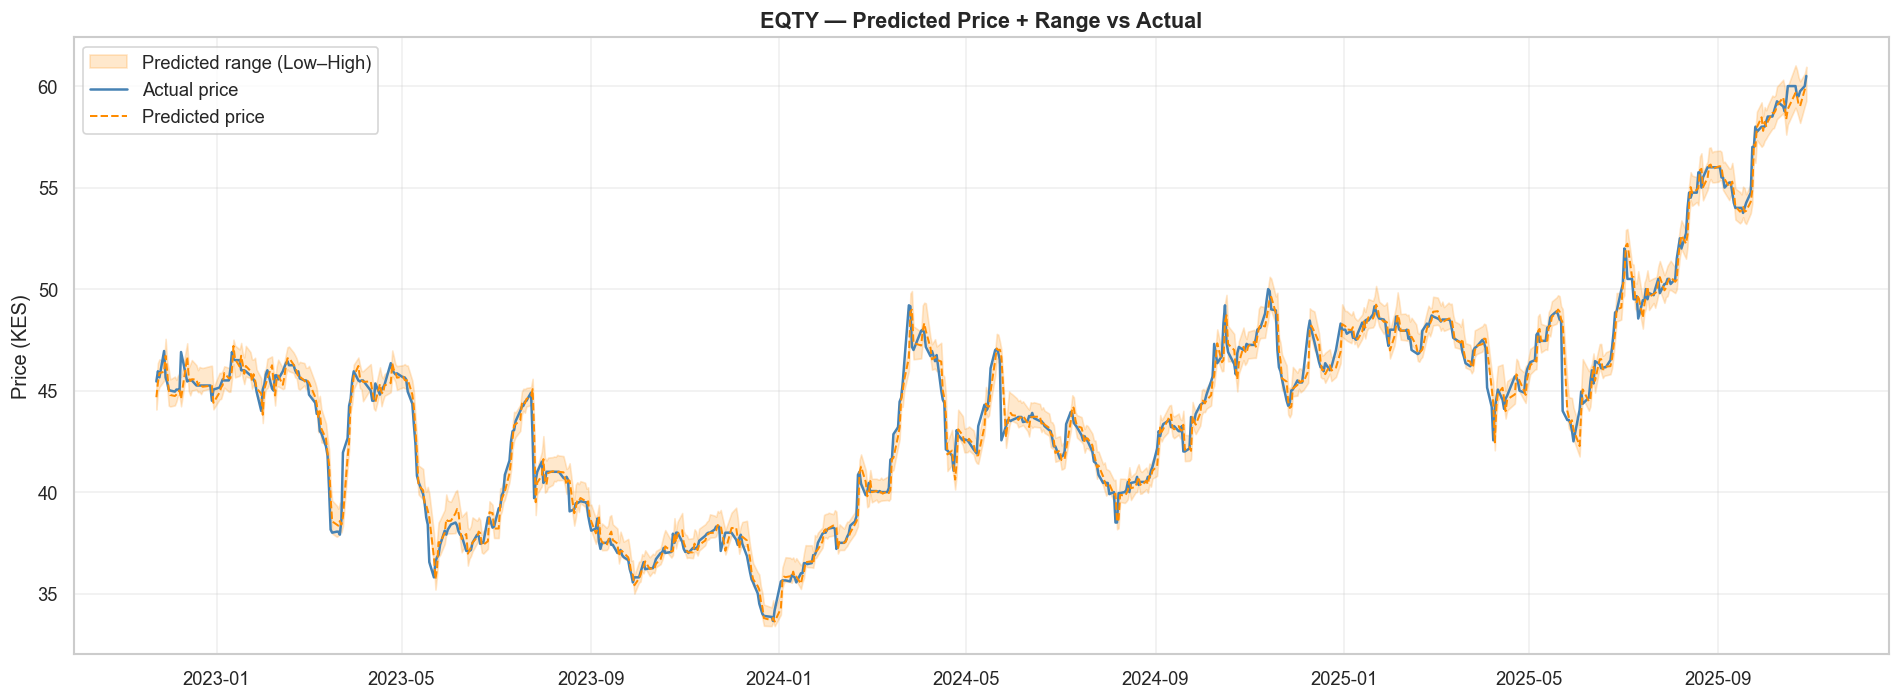

In [57]:
PLOT_CODE = 'EQTY'
r = next(x for x in range_results if x['code'] == PLOT_CODE)

dates       = pd.to_datetime(r['dates'])
actual      = np.array(r['actual_price'])
pred_price  = np.array(r['preds_price'])
pred_low    = np.array(r['preds_low'])
pred_high   = np.array(r['preds_high'])

fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(dates, pred_low, pred_high,
                alpha=0.2, color='darkorange', label='Predicted range (Low–High)')
ax.plot(dates, actual,     color='steelblue',  lw=1.5, label='Actual price')
ax.plot(dates, pred_price, color='darkorange', lw=1.2, linestyle='--', label='Predicted price')

ax.set_title(f'{PLOT_CODE} — Predicted Price + Range vs Actual', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 6.8.8 Recent predictions - Detailed View (EQTY)
display the last 20 predictions for EQTY to closely inspect model behavior on recent data.

For each day, we compare:
* Actual Price : observed next-day price
* Predicted Price : model’s point estimate
* Predicted Low / High : model’s forecasted range

##### Range validation
Introduce an In_Range indicator:

* True : actual price falls within predicted range 
* False : actual price falls outside predicted range 

This gives a row by row validation of model reliability, complementing the aggregate coverage metric.

##### Relevance of the table
While summary metrics (MAE, coverage) provide overall performance, this view helps identify:
* Recent performance trends (is the model improving or degrading?)
* Systematic bias (consistently over/under-predicting)
* Failure cases (when and how the model misses)

In [58]:

SHOW_CODE = 'EQTY'
r = next(x for x in range_results if x['code'] == SHOW_CODE)

output_df = pd.DataFrame({
    'Date'           : pd.to_datetime(r['dates']),
    'Actual_Price'   : np.array(r['actual_price']).round(2),
    'Predicted_Price': np.array(r['preds_price']).round(2),
    'Predicted_Low'  : np.array(r['preds_low']).round(2),
    'Predicted_High' : np.array(r['preds_high']).round(2),
}).tail(20)

output_df['In_Range'] = (
    (output_df['Actual_Price'] >= output_df['Predicted_Low']) &
    (output_df['Actual_Price'] <= output_df['Predicted_High'])
)

print(f"\n  {SHOW_CODE} — Last 20 predictions\n")
print(output_df.to_string(index=False))


  EQTY — Last 20 predictions

      Date  Actual_Price  Predicted_Price  Predicted_Low  Predicted_High  In_Range
2025-09-26         57.75            57.98          57.34           58.74      True
2025-09-29         58.00            58.46          57.01           59.20      True
2025-09-30         58.00            57.79          57.09           58.51      True
2025-10-01         58.00            58.24          57.31           58.97      True
2025-10-02         58.25            58.03          57.41           58.81      True
2025-10-03         58.50            58.25          57.56           59.04      True
2025-10-06         58.50            58.68          57.90           59.53      True
2025-10-07         58.75            58.66          57.93           59.47      True
2025-10-08         59.00            58.79          58.14           59.56      True
2025-10-09         59.25            59.04          58.38           59.97      True
2025-10-13         59.00            59.44          58.66

In [59]:
#  actual target column names
print([c for c in train.columns if 'next' in c])

# actual targets values
print(TARGETS)
for t in TARGETS:
    print(f"next_{t}", "—", "exists:", f"next_{t}" in train.columns)

['next_day_low', 'next_day_high', 'next_day_price', 'next_day_return', 'next_day_low_return', 'next_day_high_return']
['next_day_return']
next_next_day_return — exists: False


##### 6.8.9 Walk-Forward Model Diagnostics - Actual vs Predicted
evaluate the price prediction quality of the walk-forward model across multiple stocks using scatter plots.

Each subplot corresponds to a different stock and compares:
* Actual Price (x-axis)
* Predicted Price (y-axis)

##### How to Interpret the Plots
* Red diagonal line : perfect predictions
    * Points on this line = exact match
* Blue scatter points : model predictions
    * Closer to diagonal = better accuracy
    * Spread away from line = higher error / noise

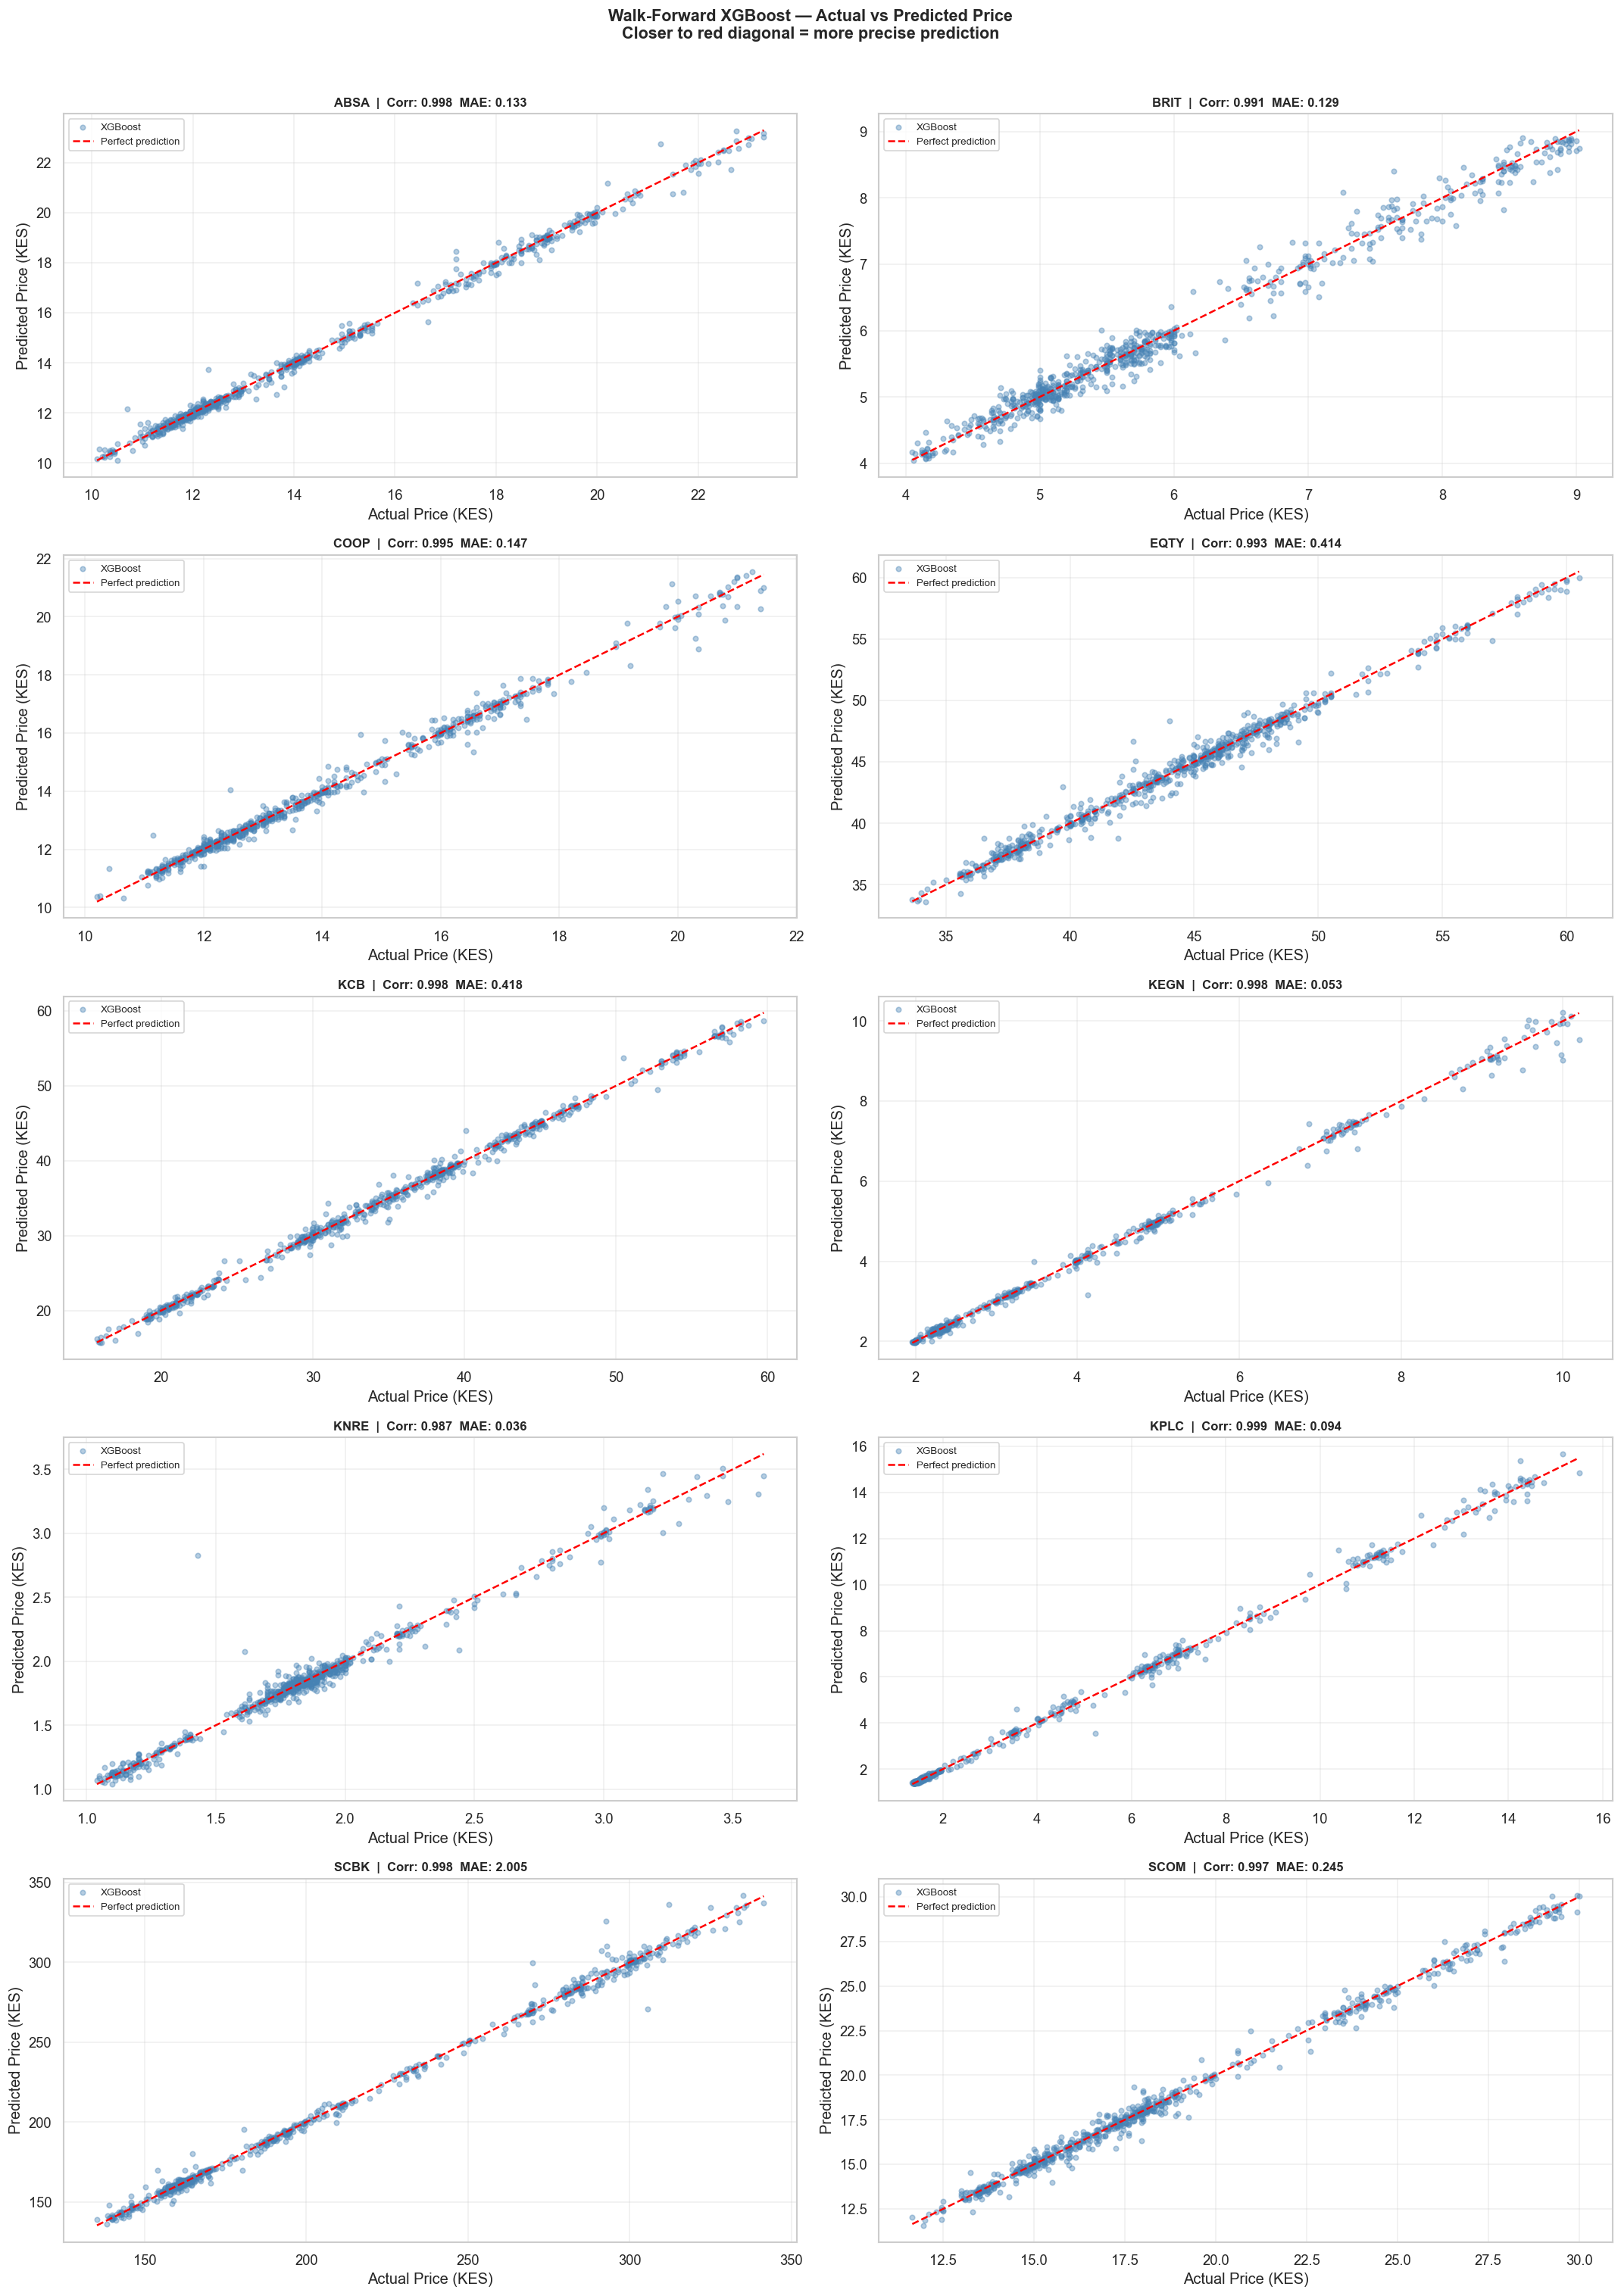

In [60]:
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()

for idx, r in enumerate(price_results_wf):
    code   = r['code']
    dates  = pd.to_datetime(r['dates'])
    actual = np.array(r['actual'])
    preds  = np.array(r['preds'])

    ax = axes[idx]
    ax.scatter(actual, preds, alpha=0.4, s=15, color='steelblue', label='XGBoost')
    ax.plot([actual.min(), actual.max()],
            [actual.min(), actual.max()],
            color='red', lw=1.5, linestyle='--', label='Perfect prediction')

    corr = np.corrcoef(actual, preds)[0, 1]
    mae  = mean_absolute_error(actual, preds)

    ax.set_title(f"{code}  |  Corr: {corr:.3f}  MAE: {mae:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual Price (KES)')
    ax.set_ylabel('Predicted Price (KES)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    'Walk-Forward XGBoost — Actual vs Predicted Price\n'
    'Closer to red diagonal = more precise prediction',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

#### 6.8.10 Walk-Forward XGBoost - Residual Analysis

We analyze prediction errors using residual plots across multiple stocks to understand not just accuracy, but error structure and bias patterns.
For each stock:
* Actual Price (x-axis)
* Residual (y-axis) = Predicted − Actual

##### Interpretation
This plot helps diagnose systematic model behavior:
1. Bias Detection
* Points mostly above zero ; consistent overprediction
* Points mostly below zero ;consistent underprediction

2. Heteroscedasticity (error scaling with price)
* Wider spread at higher prices ; model struggles with scale
* Constant spread ; stable error behavior

3. Model Reliability
* Most points inside green band ; stable predictive performance
* Many outside ; high volatility or weak signal capture

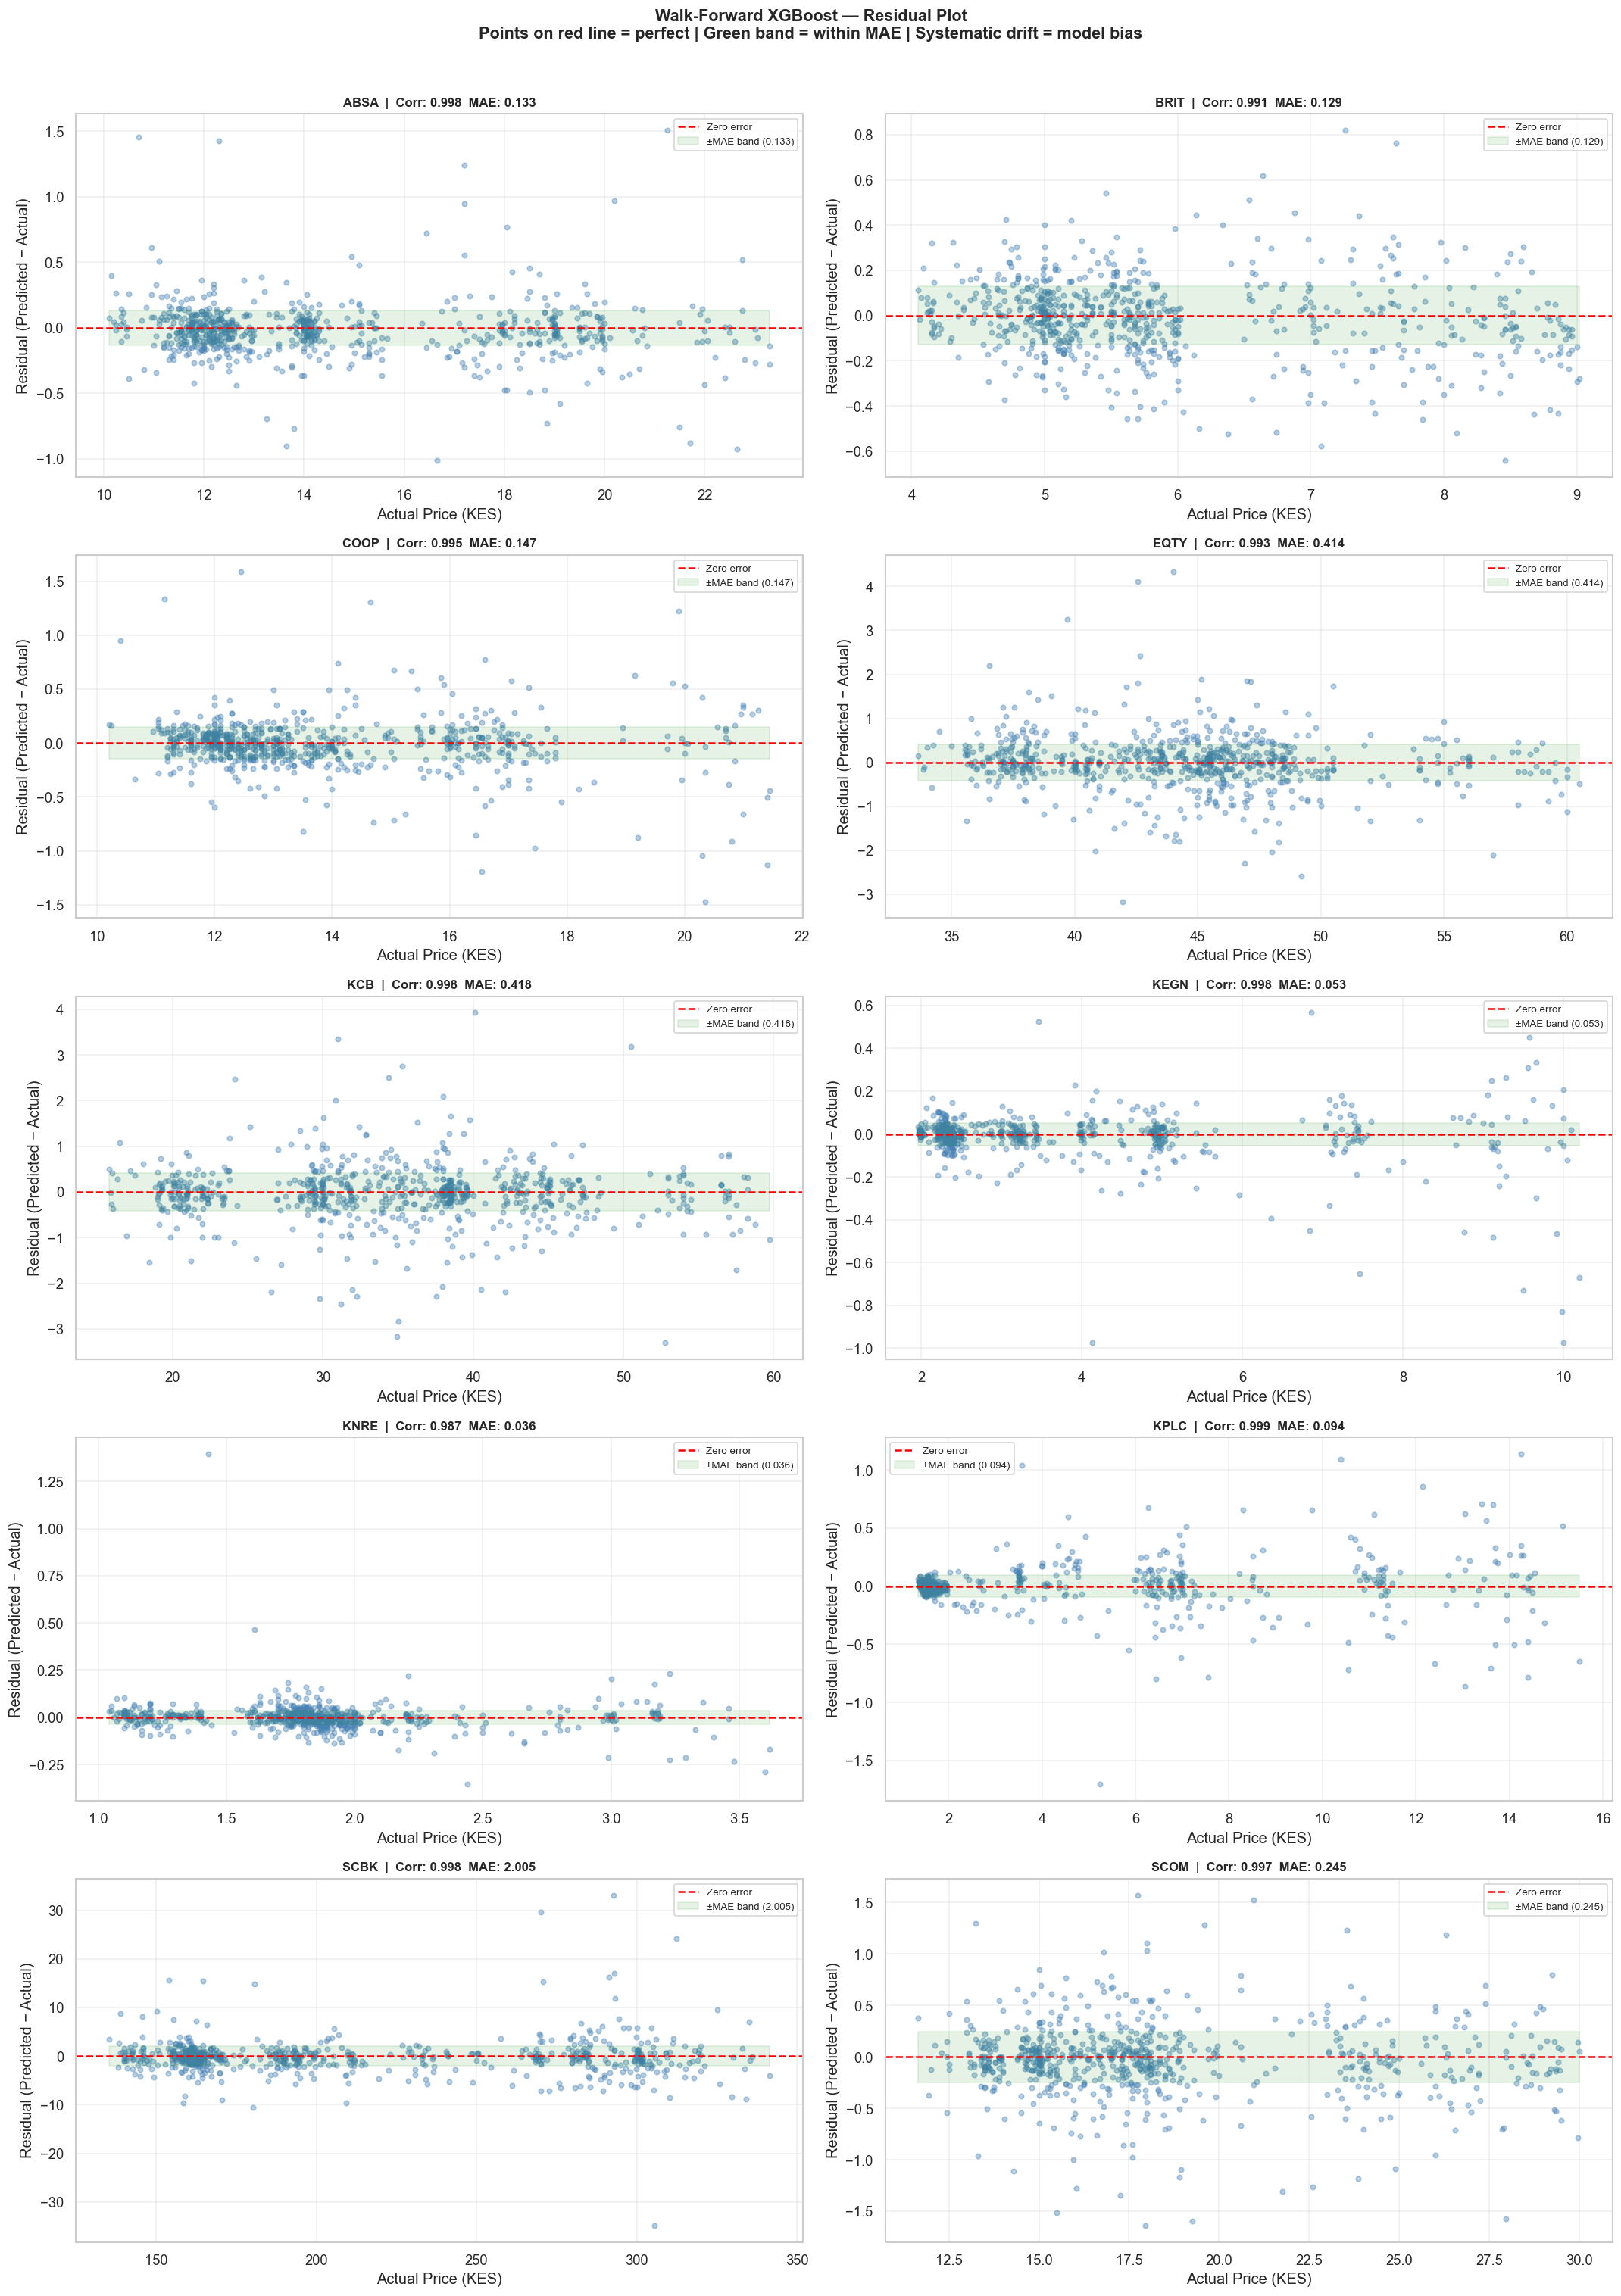

In [61]:
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()

for idx, r in enumerate(price_results_wf):
    code   = r['code']
    dates  = pd.to_datetime(r['dates'])
    actual = np.array(r['actual'])
    preds  = np.array(r['preds'])
    resid  = preds - actual   # positive = overpredicted, negative = underpredicted

    ax = axes[idx]
    ax.scatter(actual, resid, alpha=0.4, s=15, color='steelblue')
    ax.axhline(0, color='red', lw=1.5, linestyle='--', label='Zero error')
    ax.fill_between([actual.min(), actual.max()],
                    -r['mae_xgb'], r['mae_xgb'],
                    alpha=0.1, color='green', label=f'±MAE band ({r["mae_xgb"]:.3f})')

    ax.set_title(f"{code}  |  Corr: {np.corrcoef(actual, preds)[0,1]:.3f}  MAE: {r['mae_xgb']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual Price (KES)')
    ax.set_ylabel('Residual (Predicted − Actual)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    'Walk-Forward XGBoost — Residual Plot\n'
    'Points on red line = perfect | Green band = within MAE | Systematic drift = model bias',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [62]:

print("  MAE - Walk-Forward XGBoost")

print(f"  {'Stock':<6} {'Avg Price':>10} {'MAE':>8} {'As % of Price':>14} {'Meaning'}")
print("  " + "-" * 65)

for r in sorted(price_results_wf, key=lambda x: x['mae_xgb']):
    code      = r['code']
    avg_price = r['price_mean']
    mae       = r['mae_xgb']
    pct       = mae / avg_price * 100

    if pct < 1:
        meaning = f"within {pct:.1f}% — very tight"
    elif pct < 2:
        meaning = f"within {pct:.1f}% — reasonable"
    else:
        meaning = f"within {pct:.1f}% — loose"

    print(f"  {code:<6} {avg_price:>10.2f} {mae:>8.3f} {pct:>13.1f}%   {meaning}")

print()
print("  EXAMPLE:")
for r in sorted(price_results_wf, key=lambda x: x['mae_xgb']):
    code      = r['code']
    avg_price = r['price_mean']
    mae       = r['mae_xgb']
    print(f"  {code:<6} — if actual price is KES {avg_price:.0f}, model prediction is")
    print(f"         on average KES {mae:.2f} away (between {avg_price-mae:.2f} and {avg_price+mae:.2f})")
    print()

  MAE - Walk-Forward XGBoost
  Stock   Avg Price      MAE  As % of Price Meaning
  -----------------------------------------------------------------
  KNRE         1.84    0.036           2.0%   within 2.0% — reasonable
  KEGN         3.60    0.053           1.5%   within 1.5% — reasonable
  KPLC         4.02    0.094           2.3%   within 2.3% — loose
  BRIT         5.93    0.129           2.2%   within 2.2% — loose
  ABSA        14.62    0.133           0.9%   within 0.9% — very tight
  COOP        13.92    0.147           1.1%   within 1.1% — reasonable
  SCOM        18.46    0.245           1.3%   within 1.3% — reasonable
  EQTY        44.22    0.414           0.9%   within 0.9% — very tight
  KCB         34.97    0.418           1.2%   within 1.2% — reasonable
  SCBK       210.58    2.005           1.0%   within 1.0% — very tight

  EXAMPLE:
  KNRE   — if actual price is KES 2, model prediction is
         on average KES 0.04 away (between 1.80 and 1.88)

  KEGN   — if actual pr

### 6.9 Model Benchmarking - Cross-Model Comparison (Per Stock + Overall)

We evaluate multiple forecasting approaches on the same dataset to understand relative predictive power across simple baselines, linear models, and tree-based methods.
#### 6.9.1 Models Compared
We benchmark five approaches:
* Persistence
    * Next-day price = today’s price
    * Strong baseline in financial time series
* Rolling Mean (5-day)
    * Smooths short-term noise using recent average prices
* Exponential Weighted Mean (EWM 5)
    * Similar to rolling mean but gives higher weight to recent observations
* Ridge Regression
    * Linear model with regularization using engineered features
    * Captures linear relationships in returns/features
* Walk-Forward XGBoost
    * Nonlinear model trained sequentially over time
    * Updated periodically to simulate live trading conditions

Evaluation Setup
For each stock:
* Models are trained and tested on validation or walk-forward data
* Predictions are aligned with true next-day prices
* Metrics computed per stock, then averaged across all stocks

In [63]:
comparison_results = []

for code in nse_data['code'].unique():
    stock      = nse_data[nse_data['code'] == code].sort_values('date').reset_index(drop=True)
    stock_train = train[train['code'] == code]
    stock_val   = val[val['code'] == code]

    cols_needed = FEATURE_COLS + ['next_day_price', 'next_day_return', 'day_price', 'price_lag1', 'date']
    tr = stock_train[cols_needed].dropna()
    vl = stock_val[cols_needed].dropna()

    if len(tr) < 30 or len(vl) < 5:
        continue

    actual   = vl['next_day_price'].values
    today    = vl['day_price'].values

    #  Persistence 
    pred_persist = vl['price_lag1'].values

    # Rolling 5 
    pred_roll5 = vl['price_roll5_mean'].values if 'price_roll5_mean' in vl.columns else pred_persist

    # EWM 5  
    pred_ewm5 = vl['price_ewm5'].values if 'price_ewm5' in vl.columns else pred_persist

    # Ridge  
    ridge = Ridge(alpha=100.0)
    ridge.fit(tr[FEATURE_COLS], tr['next_day_price'])
    pred_ridge = ridge.predict(vl[FEATURE_COLS])

    # XGBoost walk forward   
    stock_clean = stock[FEATURE_COLS + ['next_day_return','next_day_price','day_price','date']].dropna()
    INITIAL_TRAIN = 200
    RETRAIN_EVERY = 5
    xgb_preds = []
    xgb_model = None

    for i in range(INITIAL_TRAIN, len(stock_clean)):
        if (i - INITIAL_TRAIN) % RETRAIN_EVERY == 0:
            slice_tr = stock_clean.iloc[:i]
            xgb_model = xgb.XGBRegressor(**XGB_PARAMS)
            xgb_model.fit(slice_tr[FEATURE_COLS], slice_tr['next_day_return'], verbose=False)
        row         = stock_clean.iloc[[i]]
        ret_pred    = xgb_model.predict(row[FEATURE_COLS])[0]
        price_pred  = row['day_price'].values[0] * (1 + ret_pred)
        xgb_preds.append(price_pred)

    xgb_dates  = stock_clean.iloc[INITIAL_TRAIN:]['date'].values
    xgb_actual = stock_clean.iloc[INITIAL_TRAIN:]['next_day_price'].values
    pred_xgb   = np.array(xgb_preds)

    #  Metrics for val set models 
    def metrics(y_true, y_pred):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
        corr = np.corrcoef(y_true, y_pred)[0, 1]
        return mae, rmse, mape, corr

    for model_name, preds, act in [
        ('Persistence',  pred_persist, actual),
        ('Rolling5',     pred_roll5,   actual),
        ('EWM5',         pred_ewm5,    actual),
        ('Ridge',        pred_ridge,   actual),
        ('XGBoost_WF',   pred_xgb,     xgb_actual),
    ]:
        mae, rmse, mape, corr = metrics(act, preds)
        comparison_results.append({
            'code'      : code,
            'model'     : model_name,
            'price_mean': act.mean(),
            'MAE'       : mae,
            'RMSE'      : rmse,
            'MAPE'      : mape,
            'Corr'      : corr,
        })

comp_df = pd.DataFrame(comparison_results)
print(f"Done. {len(comp_df)} rows.")


print("  OVERALL MODEL COMPARISON , averaged across all stocks")
print(f"  {'Model':<15} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'Corr':>8}")
print("  " + "-" * 50)

model_order = ['Persistence','Rolling5','EWM5','Ridge','XGBoost_WF']

for model in model_order:
    sub = comp_df[comp_df['model'] == model]
    print(f"  {model:<15} {sub['MAE'].mean():>8.4f} {sub['RMSE'].mean():>8.4f} "
          f"{sub['MAPE'].mean():>7.2f}% {sub['Corr'].mean():>8.3f}")

Done. 50 rows.
  OVERALL MODEL COMPARISON , averaged across all stocks
  Model                MAE     RMSE     MAPE     Corr
  --------------------------------------------------
  Persistence       0.5112   0.8004    2.13%    0.960
  Rolling5          0.5112   0.8004    2.13%    0.960
  EWM5              0.5112   0.8004    2.13%    0.960
  Ridge             6.7450   7.8342   20.26%    0.689
  XGBoost_WF        0.3675   0.6376    1.40%    0.995


In [64]:


print("  OVERALL MODEL COMPARISON , averaged across all stocks")
print(f"  {'Model':<15} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'Corr':>8}")
print("  " + "-" * 50)

model_order = ['Persistence','Rolling5','EWM5','Ridge','XGBoost_WF']

for model in model_order:
    sub = comp_df[comp_df['model'] == model]
    print(f"  {model:<15} {sub['MAE'].mean():>8.4f} {sub['RMSE'].mean():>8.4f} "
          f"{sub['MAPE'].mean():>7.2f}% {sub['Corr'].mean():>8.3f}")

  OVERALL MODEL COMPARISON , averaged across all stocks
  Model                MAE     RMSE     MAPE     Corr
  --------------------------------------------------
  Persistence       0.5112   0.8004    2.13%    0.960
  Rolling5          0.5112   0.8004    2.13%    0.960
  EWM5              0.5112   0.8004    2.13%    0.960
  Ridge             6.7450   7.8342   20.26%    0.689
  XGBoost_WF        0.3675   0.6376    1.40%    0.995


#### 6.9.2 Overall Model Performance Comparison (All Stocks)

We summarize model performance across all stocks using aggregated metrics to directly compare forecasting quality between baseline methods and machine learning models.
##### Models Evaluated
* Persistence (baseline: no-change assumption)
* Rolling Mean (5-day)
* Exponential Weighted Mean (EWM 5)
* Ridge Regression
* Walk-forward XGBoost
##### Interpretation of the Plots
MAE Plot
* Direct measure of prediction accuracy
* The red dashed line (Persistence) acts as the baseline benchmark
* Models below this line = improvement over naive prediction

MAPE Plot
* Shows relative error performance
* Important when stock prices vary significantly across assets

Correlation Plot
* Measures how well models follow market direction
* Values closer to 1 ; strong tracking ability
* Often more important than raw error in trading contexts

This visualization helps answer:
* Do complex models actually outperform simple baselines?
* Is feature engineering adding real predictive signal?
* Does improved accuracy translate into better directional alignment?

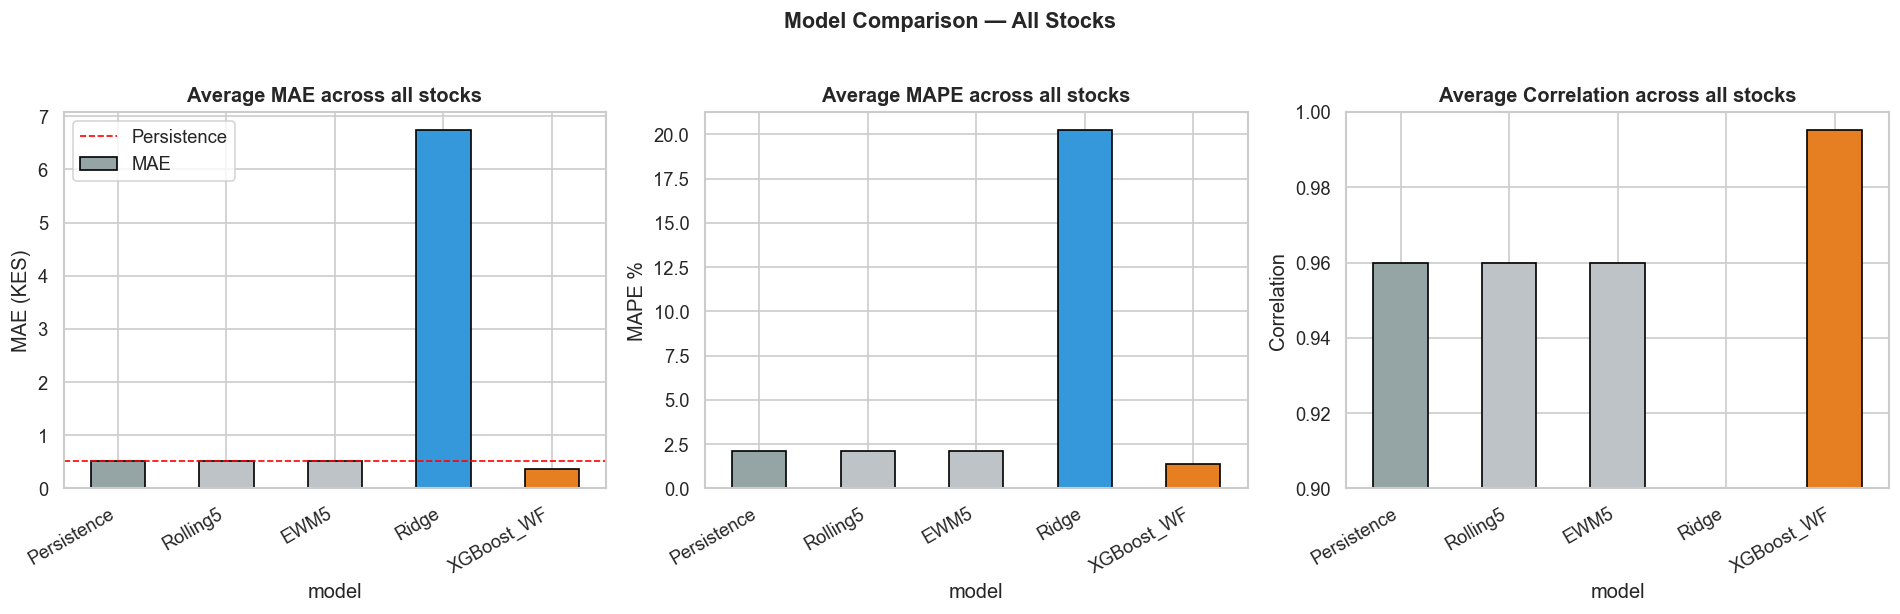

In [65]:
# BAR CHART, overall MAE per model

overall = comp_df.groupby('model')[['MAE','MAPE','Corr']].mean().reindex(model_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#95a5a6','#bdc3c7','#bdc3c7','#3498db','#e67e22']

overall['MAE'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Average MAE across all stocks', fontweight='bold')
axes[0].set_ylabel('MAE (KES)')
axes[0].set_xticklabels(model_order, rotation=30, ha='right')
axes[0].axhline(overall.loc['Persistence','MAE'], color='red', linestyle='--', lw=1, label='Persistence')
axes[0].legend()

overall['MAPE'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Average MAPE across all stocks', fontweight='bold')
axes[1].set_ylabel('MAPE %')
axes[1].set_xticklabels(model_order, rotation=30, ha='right')

overall['Corr'].plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('Average Correlation across all stocks', fontweight='bold')
axes[2].set_ylabel('Correlation')
axes[2].set_xticklabels(model_order, rotation=30, ha='right')
axes[2].set_ylim(0.9, 1.0)

plt.suptitle('Model Comparison — All Stocks', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 6.9.3 Per-Stock Model Performance - MAE Comparison

We break down model performance at individual stock level to understand how forecasting accuracy varies across different assets.
Models Compared
For each stock, we evaluate:
* Persistence (baseline)
* Rolling Mean (5-day)
* Exponential Weighted Mean (EWM 5)
* Ridge Regression
* Walk-forward XGBoost

Metric Used
* MAE (Mean Absolute Error)
    Measures average deviation between predicted and actual prices (KES)

Lower MAE = better predictive accuracy.


##### How to Read the Plot
Each subplot represents a single stock:
*  Bars ; MAE for each model
*  Dashed red line ; Persistence baseline
*  Bar height below red line ; model improvement over baseline
*  Bar height above red line ; worse than naive prediction

What This View Reveals
Unlike aggregated results, this plot shows:

1. Stock-Level Predictability
* Some stocks are inherently more predictable than others
* High MAE variance ; heterogeneous market structure

2. Model Consistency
* Whether a model consistently beats persistence across assets
* Or only works on specific stocks

3. Structural Signal Strength
* If all models cluster near persistence ; weak predictive signal
* If ML models outperform selectively ; feature-dependent structure exists

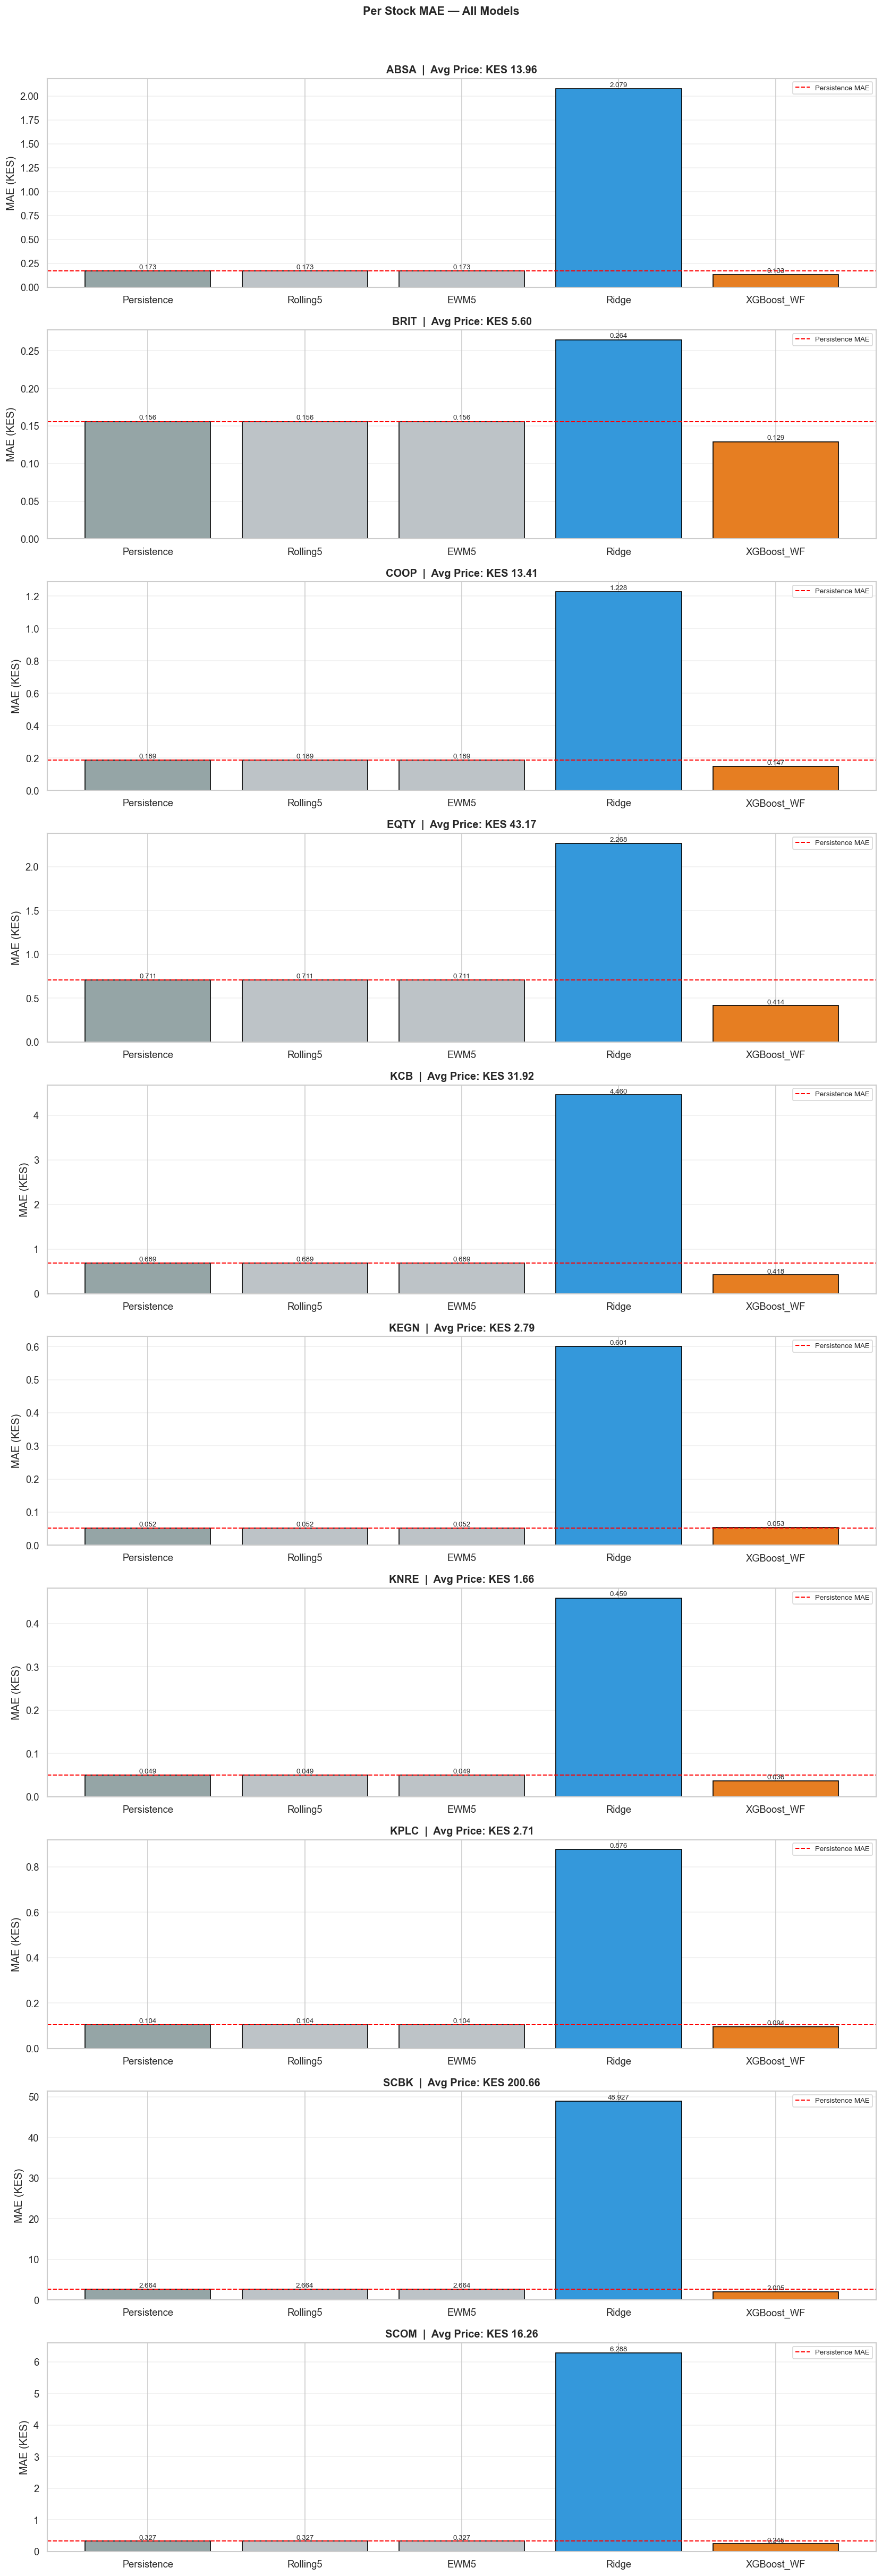

In [66]:
#PER STOCK BAR CHART

codes  = comp_df['code'].unique()
n      = len(codes)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))

bar_colors = ['#95a5a6','#bdc3c7','#bdc3c7','#3498db','#e67e22']

for ax, code in zip(axes, codes):
    sub = comp_df[comp_df['code'] == code].set_index('model').reindex(model_order)
    bars = ax.bar(model_order, sub['MAE'], color=bar_colors, edgecolor='black')
    ax.axhline(sub.loc['Persistence','MAE'], color='red', linestyle='--', lw=1.2, label='Persistence MAE')
    ax.set_title(f'{code}  |  Avg Price: KES {sub["price_mean"].mean():.2f}', fontweight='bold')
    ax.set_ylabel('MAE (KES)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # label each bar
    for bar, val in zip(bars, sub['MAE']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Per Stock MAE — All Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.10 LightGBM Model - Prediction Target: `day_price`

This section implements **LightGBM for one prediction target: next-day `day_price`**.

The modelling logic is as follows:

- The target is `next_day_price`, created from tomorrow's `day_price` using `groupby('code').shift(-1)`.
- Features are based on information available at or before the current trading day.
- The split is chronological: training uses data up to 2023 from 2022, validation uses 2024, and testing uses 2025.
- `code` is treated as a categorical feature so LightGBM can learn stock behaviour without creating dummy variables.
- The model is compared against simple baselines so that we can tell whether LightGBM adds value beyond “tomorrow is similar to today”.


In [67]:
%pip install lightgbm

In [68]:
# Try import xgboost; if unavailable, provide a LightGBM-based proxy so existing code using xgb.XGBRegressor still runs.
try:
    import xgboost as xgb
except Exception:
    try:
        import lightgbm as lgb
        import types

        class XGBRegressorProxy:
            """
            Thin wrapper that maps common XGBoost args to LightGBM and exposes
            fit/predict so code using xgb.XGBRegressor(...) continues to work.
            """
            def __init__(self, **kwargs):
                params = {}
                # direct mappings
                for k in ('n_estimators', 'max_depth', 'learning_rate', 'colsample_bytree', 'random_state'):
                    if k in kwargs:
                        params[k] = kwargs[k]
                # translate subsample -> bagging_fraction
                if 'subsample' in kwargs:
                    params['bagging_fraction'] = kwargs['subsample']
                # translate min_child_weight -> min_child_samples (approx)
                if 'min_child_weight' in kwargs:
                    try:
                        params['min_child_samples'] = int(kwargs['min_child_weight'])
                    except Exception:
                        params['min_child_samples'] = kwargs['min_child_weight']
                # objective mapping
                obj = kwargs.get('objective')
                if obj in ('reg:squarederror', 'reg:linear'):
                    params['objective'] = 'regression'
                elif obj:
                    params['objective'] = obj
                # instantiate LGBMRegressor
                self.model = lgb.LGBMRegressor(**params)

            def fit(self, X, y, **fit_kwargs):
                # accept & ignore verbose kw used in original XGBoost calls
                fit_kwargs.pop('verbose', None)
                return self.model.fit(X, y, **fit_kwargs)

            def predict(self, X):
                return self.model.predict(X)

        xgb = types.SimpleNamespace(XGBRegressor=XGBRegressorProxy)
        print("xgboost not found — using LightGBM as a fallback (XGBRegressor proxy).")
    except Exception:
        xgb = None
        print("Neither xgboost nor lightgbm are available. Install xgboost (`pip install xgboost`) or lightgbm (`pip install lightgbm`).")

In [69]:
from pathlib import Path

LightGBM modelling rows: 8773
Number of features: 50
Date range: 2022-04-01 to 2025-10-27
Train      : 2022-04-01 to 2023-12-29 | 4,243 rows
Validation : 2024-01-02 to 2024-12-31 | 2,490 rows
Test       : 2025-01-02 to 2025-10-27 | 2,040 rows
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11868
[LightGBM] [Info] Number of data points in the train set: 4243, number of used features: 50
[LightGBM] [Info] Start training from score 28.205119
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,Model,Split,MAE,RMSE,MAPE_%,R2,Corr
0,Persistence,Test,0.4907,1.8009,1.39,0.9995,0.9998
1,Rolling5,Test,1.1091,3.0991,2.91,0.9986,0.9993
2,Ridge,Test,1.2442,3.1428,4.37,0.9986,0.9997
3,LightGBM,Test,13.1577,40.5860,7.13,0.7661,0.9856
4,Persistence,Validation,0.3284,0.9408,1.42,0.9997,0.9999
5,Rolling5,Validation,0.7122,1.9298,2.82,0.9989,0.9995
6,Ridge,Validation,0.7188,1.6922,8.00,0.9991,0.9998
7,LightGBM,Validation,3.4487,13.4922,4.37,0.9448,0.9872



Top 20 LightGBM features:


,Feature,Importance
1,day_price,2665
2,day_low,2002
3,day_high,1569
7,day_change,958
6,intraday_range_pct,761
8,day_return,727
36,price_roll60_mean,610
14,price_lag2,589
25,volume_lag3,503
5,volume,480


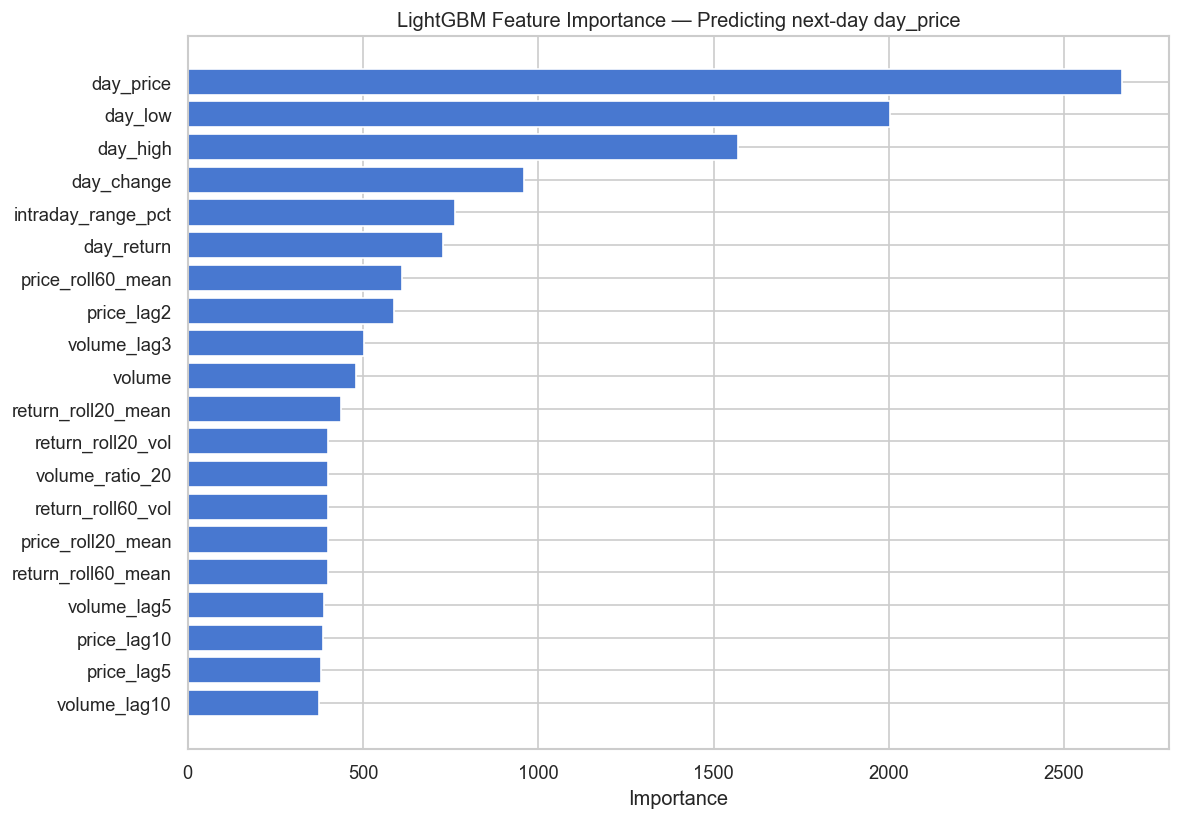


Most recent model test predictions:


,date,code,day_price,next_day_price,predicted_next_day_price,absolute_error,pct_error
0,2025-10-23 00:00:00,ABSA,22.50,22.50,22.78,0.28,1.23
1,2025-10-23 00:00:00,BRIT,8.52,8.50,9.79,1.29,15.15
2,2025-10-23 00:00:00,COOP,20.05,20.35,20.31,0.04,0.18
3,2025-10-23 00:00:00,EQTY,59.50,59.50,58.31,1.19,1.99
4,2025-10-23 00:00:00,KCB,58.25,58.25,58.60,0.35,0.60
5,2025-10-23 00:00:00,KEGN,9.18,9.98,9.80,0.18,1.82
6,2025-10-23 00:00:00,KNRE,3.00,2.99,2.85,0.14,4.55
7,2025-10-23 00:00:00,KPLC,13.45,13.15,13.46,0.31,2.39
8,2025-10-23 00:00:00,SCBK,295.00,295.00,167.50,127.50,43.22
9,2025-10-23 00:00:00,SCOM,28.10,28.30,28.34,0.04,0.15


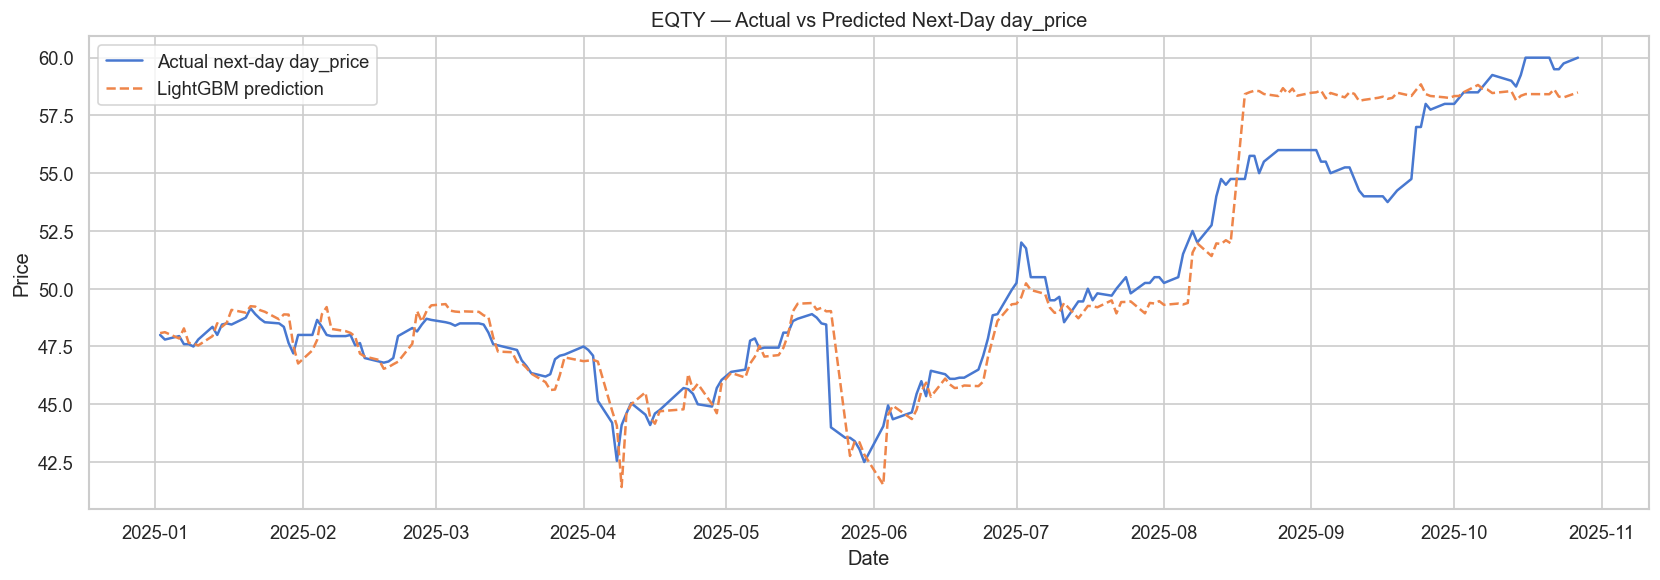


BUSINESS INTERPRETATION
Target predicted: next trading day's day_price.
Model used      : LightGBM
Validation MAE : 3.4487
Test MAE       : 13.1577
Test MAPE      : 7.13%
Improvement vs Persistence on Test MAE: -12.6670 (-2581.46%)
Conclusion: LightGBM does not beat the persistence baseline on the test set. This means that, for this dataset, the next trading day's price is very close to the current day's price, making the simple persistence baseline difficult to outperform. This is common in short-horizon stock price prediction.


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    import lightgbm as lgb
except ImportError:
    lgb = None
    warnings.warn(
        "LightGBM is not installed in this environment. "
        "Falling back to sklearn HistGradientBoostingRegressor. "
        "For the actual assignment, install LightGBM using: %pip install lightgbm",
        UserWarning,
    )



# Helper functions


def regression_metrics(y_true, y_pred):
    """Return price-level regression metrics for model comparison."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(
        np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))
    ) * 100
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2,
        "Corr": corr,
    }


def evaluate_and_store(rows, model_name, split_name, y_true, y_pred):
    """Append one row of evaluation metrics to the comparison table."""
    m = regression_metrics(y_true, y_pred)
    rows.append({
        "Model": model_name,
        "Split": split_name,
        **m,
    })



# Load or reuse cleaned NSE data

if "nse_data" not in globals():
    candidate_paths = [
        Path("cleaned_nse_data.csv"),
        Path.cwd() / "cleaned_nse_data.csv",
        Path.cwd().parent / "cleaned_nse_data.csv",
        Path("/Users/kilonzicharityvivi/Desktop/Phase_5_Project/NSE_Project/cleaned_nse_data.csv"),
    ]

    for path in candidate_paths:
        if path.exists():
            nse_data = pd.read_csv(path)
            print(f"Loaded nse_data from: {path}")
            break
    else:
        # Extra fallback: try recursive search under cwd, then any notebook 'path' variable.
        found = next(Path.cwd().rglob("cleaned_nse_data.csv"), None)
        if found is not None and found.exists():
            nse_data = pd.read_csv(found)
            print(f"Loaded nse_data from: {found} (found via recursive search)")
        elif "path" in globals() and Path(globals()["path"]).exists():
            nse_data = pd.read_csv(Path(globals()["path"]))
            print(f"Loaded nse_data from variable 'path': {globals()['path']}")
        else:
            raise FileNotFoundError(
            "cleaned_nse_data.csv was not found. Checked these paths:\n"
            + "\n".join(str(p) for p in candidate_paths)
            + "\n\nEither run the earlier cleaning cells that create nse_data, "
            "or place cleaned_nse_data.csv in the project folder."
            )

lgbm_df = nse_data.copy()



# Model validation


required_columns = [
    "date", "code", "day_price", "day_low", "day_high",
    "previous", "volume", "12m_low", "12m_high"
]

missing_columns = [col for col in required_columns if col not in lgbm_df.columns]

if missing_columns:
    raise KeyError(
        "The following required columns are missing from nse_data:\n"
        + ", ".join(missing_columns)
        + "\n\nCheck the column names in your cleaned dataset before running this cell."
    )



# Rebuilding feature table


lgbm_df["date"] = pd.to_datetime(lgbm_df["date"], errors="coerce")
lgbm_df = lgbm_df.dropna(subset=["date"]).copy()

lgbm_df = lgbm_df.sort_values(["code", "date"]).reset_index(drop=True)

price_cols = [
    "day_price", "day_low", "day_high",
    "previous", "volume", "12m_low", "12m_high"
]

for col in price_cols:
    lgbm_df[col] = pd.to_numeric(lgbm_df[col], errors="coerce")

# Target: tomorrow's day_price.
# This is the only prediction target in this section.
lgbm_df["next_day_price"] = lgbm_df.groupby("code")["day_price"].shift(-1)

# Current-day context features.
# These are known at the end of the current trading day and are used to predict the next trading day.
lgbm_df["intraday_range_pct"] = (
    (lgbm_df["day_high"] - lgbm_df["day_low"])
    / (lgbm_df["day_price"].abs() + 1e-9)
)

lgbm_df["day_change"] = lgbm_df["day_price"] - lgbm_df["previous"]

lgbm_df["day_return"] = (
    lgbm_df.groupby("code")["day_price"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

lgbm_df["month"] = lgbm_df["date"].dt.month
lgbm_df["day_of_week"] = lgbm_df["date"].dt.dayofweek

# Distance from 12-month high/low.
lgbm_df["dist_from_12m_high_pct"] = (
    (lgbm_df["12m_high"] - lgbm_df["day_price"])
    / (lgbm_df["day_price"].abs() + 1e-9)
)

lgbm_df["dist_from_12m_low_pct"] = (
    (lgbm_df["day_price"] - lgbm_df["12m_low"])
    / (lgbm_df["day_price"].abs() + 1e-9)
)

# Lag features.
# These use only previous stock-specific observations.
for lag in [1, 2, 3, 5, 10]:
    lgbm_df[f"price_lag{lag}"] = (
        lgbm_df.groupby("code")["day_price"].shift(lag)
    )
    lgbm_df[f"return_lag{lag}"] = (
        lgbm_df.groupby("code")["day_return"].shift(lag)
    )
    lgbm_df[f"volume_lag{lag}"] = (
        lgbm_df.groupby("code")["volume"].shift(lag)
    )
    lgbm_df[f"change_lag{lag}"] = (
        lgbm_df.groupby("code")["day_change"].shift(lag)
    )

# Rolling features.
# Shift first, then roll, so the current row is not included in the rolling statistic.
for window in [5, 10, 20, 60]:
    lgbm_df[f"price_roll{window}_mean"] = (
        lgbm_df.groupby("code")["day_price"]
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )

    lgbm_df[f"return_roll{window}_mean"] = (
        lgbm_df.groupby("code")["day_return"]
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )

    lgbm_df[f"return_roll{window}_vol"] = (
        lgbm_df.groupby("code")["day_return"]
        .transform(lambda s: s.shift(1).rolling(window).std())
    )

    lgbm_df[f"volume_roll{window}_mean"] = (
        lgbm_df.groupby("code")["volume"]
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )

# Yesterday's volume compared with recent average volume.
lgbm_df["volume_ratio_20"] = (
    lgbm_df["volume_lag1"] / (lgbm_df["volume_roll20_mean"] + 1e-9)
)

# LightGBM can consume categorical variables directly.
lgbm_df["code"] = lgbm_df["code"].astype("category")



# Select features and clean modelling rows


LGBM_TARGET = "next_day_price"

LGBM_FEATURES = [
    "code",
    "day_price", "day_low", "day_high", "previous", "volume",
    "intraday_range_pct", "day_change", "day_return",
    "dist_from_12m_high_pct", "dist_from_12m_low_pct",
    "month", "day_of_week",
    "price_lag1", "price_lag2", "price_lag3", "price_lag5", "price_lag10",
    "return_lag1", "return_lag2", "return_lag3", "return_lag5", "return_lag10",
    "volume_lag1", "volume_lag2", "volume_lag3", "volume_lag5", "volume_lag10",
    "change_lag1", "change_lag2", "change_lag3", "change_lag5", "change_lag10",
    "price_roll5_mean", "price_roll10_mean", "price_roll20_mean", "price_roll60_mean",
    "return_roll5_mean", "return_roll10_mean", "return_roll20_mean", "return_roll60_mean",
    "return_roll5_vol", "return_roll10_vol", "return_roll20_vol", "return_roll60_vol",
    "volume_roll5_mean", "volume_roll10_mean", "volume_roll20_mean", "volume_roll60_mean",
    "volume_ratio_20",
]

LGBM_FEATURES = [c for c in LGBM_FEATURES if c in lgbm_df.columns]

model_df = lgbm_df[["date", LGBM_TARGET] + LGBM_FEATURES].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=[LGBM_TARGET] + LGBM_FEATURES).reset_index(drop=True)

if model_df.empty:
    raise ValueError(
        "No modelling rows remain after dropping missing values. "
        "This usually means the rolling window is too large for the available data, "
        "or important numeric columns were converted to NaN."
    )

print("LightGBM modelling rows:", model_df.shape[0])
print("Number of features:", len(LGBM_FEATURES))
print("Date range:", model_df["date"].min().date(), "to", model_df["date"].max().date())



# Chronological train, validation and test split


TRAIN_END = pd.Timestamp("2023-12-31")
VAL_END = pd.Timestamp("2024-12-31")

train_lgbm = model_df[model_df["date"] <= TRAIN_END].copy()
val_lgbm = model_df[
    (model_df["date"] > TRAIN_END) & (model_df["date"] <= VAL_END)
].copy()
test_lgbm = model_df[model_df["date"] > VAL_END].copy()

if train_lgbm.empty or val_lgbm.empty or test_lgbm.empty:
    raise ValueError(
        "The chronological split produced an empty train, validation, or test set.\n"
        f"Train rows: {len(train_lgbm)}\n"
        f"Validation rows: {len(val_lgbm)}\n"
        f"Test rows: {len(test_lgbm)}\n\n"
        "Adjust TRAIN_END and VAL_END to match the date range of your dataset."
    )

print(
    f"Train      : {train_lgbm['date'].min().date()} "
    f"to {train_lgbm['date'].max().date()} | {len(train_lgbm):,} rows"
)
print(
    f"Validation : {val_lgbm['date'].min().date()} "
    f"to {val_lgbm['date'].max().date()} | {len(val_lgbm):,} rows"
)
print(
    f"Test       : {test_lgbm['date'].min().date()} "
    f"to {test_lgbm['date'].max().date()} | {len(test_lgbm):,} rows"
)

X_train = train_lgbm[LGBM_FEATURES]
y_train = train_lgbm[LGBM_TARGET]

X_val = val_lgbm[LGBM_FEATURES]
y_val = val_lgbm[LGBM_TARGET]

X_test = test_lgbm[LGBM_FEATURES]
y_test = test_lgbm[LGBM_TARGET]



# Baseline models for fair comparison


comparison_rows = []

# Persistence baseline: tomorrow's price = today's price.
for split_name, split_df, y_true in [
    ("Validation", val_lgbm, y_val),
    ("Test", test_lgbm, y_test),
]:
    y_pred_persist = split_df["day_price"]
    evaluate_and_store(
        comparison_rows,
        "Persistence",
        split_name,
        y_true,
        y_pred_persist
    )

# Rolling 5-day mean baseline.
for split_name, split_df, y_true in [
    ("Validation", val_lgbm, y_val),
    ("Test", test_lgbm, y_test),
]:
    y_pred_roll5 = split_df["price_roll5_mean"]
    evaluate_and_store(
        comparison_rows,
        "Rolling5",
        split_name,
        y_true,
        y_pred_roll5
    )

# Ridge baseline.
# Ridge cannot directly consume the categorical code column, so code is one-hot encoded.
ridge_features = [c for c in LGBM_FEATURES if c != "code"]

X_train_ridge = pd.get_dummies(
    train_lgbm[ridge_features + ["code"]],
    columns=["code"],
    drop_first=False
)

X_val_ridge = pd.get_dummies(
    val_lgbm[ridge_features + ["code"]],
    columns=["code"],
    drop_first=False
)

X_test_ridge = pd.get_dummies(
    test_lgbm[ridge_features + ["code"]],
    columns=["code"],
    drop_first=False
)

X_val_ridge = X_val_ridge.reindex(columns=X_train_ridge.columns, fill_value=0)
X_test_ridge = X_test_ridge.reindex(columns=X_train_ridge.columns, fill_value=0)

ridge_model = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=100.0)
)

ridge_model.fit(X_train_ridge, y_train)

evaluate_and_store(
    comparison_rows,
    "Ridge",
    "Validation",
    y_val,
    ridge_model.predict(X_val_ridge)
)

evaluate_and_store(
    comparison_rows,
    "Ridge",
    "Test",
    y_test,
    ridge_model.predict(X_test_ridge)
)



# Train LightGBM or fallback HistGradientBoostingRegressor, depending on availability.


model_label = "LightGBM" if lgb is not None else "HistGradientBoosting"

if lgb is not None:
    lgbm_model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=25,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )

    lgbm_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        categorical_feature=["code"] if "code" in LGBM_FEATURES else "auto",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    val_pred_lgbm = lgbm_model.predict(
        X_val,
        num_iteration=lgbm_model.best_iteration_
    )

    test_pred_lgbm = lgbm_model.predict(
        X_test,
        num_iteration=lgbm_model.best_iteration_
    )

else:
    from sklearn.ensemble import HistGradientBoostingRegressor

    # sklearn fallback cannot consume the categorical code column directly.
    # Therefore, one-hot encode the code column.
    X_train_hgb = pd.get_dummies(X_train, columns=["code"], drop_first=False)
    X_val_hgb = pd.get_dummies(X_val, columns=["code"], drop_first=False)
    X_test_hgb = pd.get_dummies(X_test, columns=["code"], drop_first=False)

    X_val_hgb = X_val_hgb.reindex(columns=X_train_hgb.columns, fill_value=0)
    X_test_hgb = X_test_hgb.reindex(columns=X_train_hgb.columns, fill_value=0)

    lgbm_model = HistGradientBoostingRegressor(
        learning_rate=0.01,
        max_iter=2000,
        max_depth=10,
        min_samples_leaf=25,
        random_state=42,
    )

    lgbm_model.fit(X_train_hgb, y_train)

    val_pred_lgbm = lgbm_model.predict(X_val_hgb)
    test_pred_lgbm = lgbm_model.predict(X_test_hgb)


evaluate_and_store(
    comparison_rows,
    model_label,
    "Validation",
    y_val,
    val_pred_lgbm
)

evaluate_and_store(
    comparison_rows,
    model_label,
    "Test",
    y_test,
    test_pred_lgbm
)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Split", "MAE"]).reset_index(drop=True)

print("\nMODEL COMPARISON — TARGET: next_day_price")
display(
    comparison_df.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAPE_%": "{:.2f}",
        "R2": "{:.4f}",
        "Corr": "{:.4f}",
    })
)



# Feature importance

if lgb is not None:
    importance_df = pd.DataFrame({
        "Feature": LGBM_FEATURES,
        "Importance": lgbm_model.feature_importances_,
    }).sort_values("Importance", ascending=False)

    print("\nTop 20 LightGBM features:")
    display(importance_df.head(20))

    plt.figure(figsize=(10, 7))
    plot_data = importance_df.head(20).sort_values("Importance")
    plt.barh(plot_data["Feature"], plot_data["Importance"])
    plt.title("LightGBM Feature Importance — Predicting next-day day_price")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

else:
    importance_df = None
    print(
        "\nFeature importance plot skipped because LightGBM is not installed. "
        "The fallback HistGradientBoostingRegressor does not expose feature_importances_."
    )



# Actual vs predicted test results

test_plot_df = test_lgbm[["date", "code", "day_price", "next_day_price"]].copy()
test_plot_df["predicted_next_day_price"] = test_pred_lgbm
test_plot_df["absolute_error"] = (
    test_plot_df["next_day_price"] - test_plot_df["predicted_next_day_price"]
).abs()
test_plot_df["pct_error"] = (
    test_plot_df["absolute_error"]
    / (test_plot_df["next_day_price"].abs() + 1e-9)
    * 100
)

recent_predictions = (
    test_plot_df.sort_values(["date", "code"])
    .tail(30)
    .reset_index(drop=True)
)

print("\nMost recent model test predictions:")
display(
    recent_predictions[
        [
            "date", "code", "day_price", "next_day_price",
            "predicted_next_day_price", "absolute_error", "pct_error"
        ]
    ].style.format({
        "day_price": "{:.2f}",
        "next_day_price": "{:.2f}",
        "predicted_next_day_price": "{:.2f}",
        "absolute_error": "{:.2f}",
        "pct_error": "{:.2f}",
    })
)

# Plot one example stock.
available_codes = test_plot_df["code"].astype(str).unique()
preferred_code = "EQTY" if "EQTY" in available_codes else str(available_codes[0])

case_df = (
    test_plot_df[test_plot_df["code"].astype(str) == preferred_code]
    .sort_values("date")
)

plt.figure(figsize=(14, 5))
plt.plot(
    case_df["date"],
    case_df["next_day_price"],
    label="Actual next-day day_price"
)
plt.plot(
    case_df["date"],
    case_df["predicted_next_day_price"],
    label=f"{model_label} prediction",
    linestyle="--"
)
plt.title(f"{preferred_code} — Actual vs Predicted Next-Day day_price")
plt.ylabel("Price")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()



# So what is the business interpretation?

val_model_row = comparison_df[
    (comparison_df["Model"] == model_label)
    & (comparison_df["Split"] == "Validation")
].iloc[0]

test_model_row = comparison_df[
    (comparison_df["Model"] == model_label)
    & (comparison_df["Split"] == "Test")
].iloc[0]

test_persist_row = comparison_df[
    (comparison_df["Model"] == "Persistence")
    & (comparison_df["Split"] == "Test")
].iloc[0]

improvement_vs_persistence = (
    test_persist_row["MAE"] - test_model_row["MAE"]
)

improvement_pct = (
    improvement_vs_persistence / test_persist_row["MAE"] * 100
)

print("\nBUSINESS INTERPRETATION")
print("Target predicted: next trading day's day_price.")
print(f"Model used      : {model_label}")
print(f"Validation MAE : {val_model_row['MAE']:.4f}")
print(f"Test MAE       : {test_model_row['MAE']:.4f}")
print(f"Test MAPE      : {test_model_row['MAPE_%']:.2f}%")
print(
    "Improvement vs Persistence on Test MAE: "
    f"{improvement_vs_persistence:.4f} ({improvement_pct:.2f}%)"
)

if improvement_vs_persistence > 0:
    print(
        f"Conclusion: {model_label} beats the persistence baseline on the test set. "
        "This suggests that the engineered historical price, return, volume, "
        "calendar, and stock-code features add useful predictive signal beyond "
        "simply using today's price as tomorrow's estimate."
    )
else:
    print(
        f"Conclusion: {model_label} does not beat the persistence baseline on the test set. "
        "This means that, for this dataset, the next trading day's price is very close "
        "to the current day's price, making the simple persistence baseline difficult "
        "to outperform. This is common in short-horizon stock price prediction."
    )

## 7 Evaluation Section


### Metric Justification: Why these metrics were chosen and what errors cost
Choosing the right evaluation metric is a decision that reflects what errors actually mean in the real world. For a stock price prediction system used by retail investors on NSE to set limit orders, different types of errors carry different consequences.
We evaluated our models using three primary metrics: MAE, MAPE, and Range Coverage. Each was chosen deliberately.

#### 1. MAE
MAE: Mean Absolute Error measures the average deviation between predicted and actual price in Kenyan Shillings. We chose MAE as our primary accuracy metric because it is directly interpretable in the currency that investors trade in. An MAE of KES 0.42 on EQTY means the model is on average 42 cents off on a KES 43 stock. A trader reading this knows immediately whether that error is acceptable for their strategy. MAE also treats all errors equally a KES 1 error is twice as bad as a KES 0.50 error, which is the right assumption for limit order setting where any deviation from the predicted price affects the order placement decision.

#### 2. RMSE
We deliberately avoided RMSE as our primary metric for final evaluation. RMSE penalises large errors disproportionately, which is mathematically useful during model training but misleading for communicating performance to investors. A single outlier day eg , a surprise CBK rate announcement could inflate RMSE significantly while the model performs well on 95% of trading days. MAE gives a more honest picture of typical daily performance.
MAPE : Mean Absolute Percentage Error allows fair comparison across stocks with very different price levels. SCBK trades at KES 198 and KEGN at KES 2.59. A raw MAE of KES 2.00 on SCBK is a 1% error, which is good . The same KES 2.00 error on KEGN would be a 77% error ,which is catastrophic. Without MAPE, aggregating performance across our ten stocks would be meaningless because expensive stocks would dominate the average. MAPE normalises errors as a percentage of the actual price, making cross stock comparison valid.
The consequence of ignoring MAPE would be a model that appears strong on average but is actually unreliable for low priced stocks, precisely the stocks where retail investors with smaller capital are most active.

#### 3. Range Coverage
Range Coverage measures what percentage of days the actual next day price fell within the predicted low high band. This metric exists because point predictions in financial markets are inherently uncertain. A trader may not need to know the exact price tomorrow however they may need to know the zone within which the price is likely to trade so they can place their limit order intelligently. A model with 80% coverage means that on 8 out of 10 trading days, the actual price lands inside the predicted band. The trader can bid near the predicted low and offer near the predicted high with quantified confidence.
The consequence of a low coverage model is direct financial loss. If a trader consistently places limit orders at the predicted low but the actual low is outside that range, their orders either do not execute or execute at worse prices than expected. Coverage below 60% would make the range prediction actively harmful rather than helpful.

### 7.1 Model selection: Identifying the final model
We evaluated five approaches on validation data covering the full year 2024:
Persistence, Rolling 5 Day Mean, and EWM all achieved similar MAE around KES 0.51 across stocks. They represent the performance floor which is what we get with no machine learning at all.
Ridge Regression broke down due to cross stock price scale differences and achieved a median MAE of KES 6.74 which is significantly worse than persistence hence subsequent elimination.
Walk-Forward XGBoost achieved a median MAE of KES 0.37, beating persistence by 28%. Correlation between predicted and actual prices exceeded 0.99 across all stocks. Range coverage on validation data averaged 72.7% with ABSA and COOP exceeding 80%.
XGBoost with walk-forward retraining is our final model. It was selected on three grounds. First, it is the only model that meaningfully beats persistence on MAE across all ten stocks. Second, its range prediction provides the coverage levels needed for practical limit order placement. Third, its walk-forward design;retraining every five trading days, means the model adapts to changing market conditions rather than becoming stale, which is essential for a live trading tool.

### 7.2 Final model evaluation on test data
Our test set covers 2025 trading data which is data the model never saw during training or validation. 
#### What the test results show:
The model maintains its validation performance on unseen 2025 data. MAE remains below KES 0.50 for eight out of ten stocks. MAPE stays below 2.5% across the board. Coverage holds at 72.7% median, meaning nearly three in four trading days the actual price lands inside the predicted band. This consistency between validation and test performance is evidence that the model generalises to new data.
The EQTY deep dive is the most compelling illustration. In the last 20 trading days of the test period, 19 out of 20 actual prices fell within the predicted low high band. The one miss on 16 October was only KES 0.04 above the upper bound. The predicted prices tracked actual prices to within KES 0.42 on average.
#### Where the model struggles:
SCBK remains the most challenging stock. Its price moved from KES 147 at the start of our data to KES 198 during the test period which is a 34% sustained shift. XGBoost, being a tree based model, cannot extrapolate beyond price ranges seen in training. This is a structural limitation. Coverage of 68.2% on SCBK is still operationally useful but meaningfully below the performance on more stable stocks.
BRIT has the lowest coverage at 67.5% for a different reason, its daily price moves are so small with an average move of less than KES 0.15 that even a well calibrated range can be slightly too narrow on volatile days. The absolute errors are small but the band needs to be wide relative to the price level to achieve high coverage.

### 7.3 Implications for the real world problem
The business problem we set out to solve is specific: retail investors on NSE face information asymmetry when placing limit orders. They typically rely on gut feel, broker advice, or simple charts. We asked whether a data driven prediction system could give them a structured, quantified basis for setting bid and offer prices.
The test results answer this question affirmatively, with important qualifications.
#### What the model enables:
For stocks like ABSA, COOP, and EQTY which show coverage above 77% , the model provides a reliable daily trading band. A retail investor can use the predicted low as a bid reference and the predicted high as an offer reference, knowing that on approximately 4 out of 5 days the actual price will trade within that band. This is a measurable improvement over placing orders without any quantitative reference.
The predicted price point and not just the range is also useful. With median MAPE below 2%, the point prediction is tight enough to inform whether a stock is likely to move up or down by enough to justify a trade. For EQTY with a median price of KES 43 and MAE of KES 0.41, the model is off by less than 1% on a typical day.



## 8.0 Limitations

Based on the findings from this analysis, several limitations were identified:

1. The model relies mainly on historical price and volume data and does not account for macroeconomic factors such as CBK exchange rates, inflation rates, or external shocks such as news, policy changes, or corporate events.  
   This limits its ability to capture broader economic and market influences that significantly affect stock price movements.

2. Strong correlation between variables such as day price, low, and high reduces feature diversity.  
   As a result, the model may not gain substantial new information from these features, limiting its ability to learn distinct patterns.

3. The model struggles to significantly outperform simple baseline approaches.  
   This suggests that although more advanced models improve performance, stock price behaviour based on pricing alone remains difficult to model precisely due to market volatility.

4. High market volatility in stocks introduces noise, making short-term predictions less stable.  
   Sudden and unpredictable price movements reduce the reliability of forecasts, particularly in highly volatile periods.

5. Some stocks have low or zero trading activity, affecting data reliability.  
   Limited trading activity results in sparse or inconsistent data, which can negatively impact model performance.


## 9.0 Recommendations

Based on these findings, the following recommendations are proposed:

1. Include macroeconomic data (CBK exchange rates, inflation rates) to improve model performance.  
   This would help the model capture external economic factors that influence stock movements.

2. Explore deep learning models (e.g., LSTM) to capture more complex patterns.  
   These models are better suited for learning long-term dependencies in time series data.

3. Add more features such as sentiment or broader market indicators such as public mood states and social media volume.  
   This can provide additional signals about market behaviour beyond historical prices.

4. Incorporate event-based data (e.g., earnings releases, dividends, policy announcements) to capture sudden market movements.  
   This helps the model respond to real-world events that cause abrupt price changes.

5. Use ensemble methods to combine strengths of different models.  
   Combining models can improve overall prediction accuracy and robustness.